In [ ]:
# Get daily constraint ranked by the abs RT - DA 
import sys
sys.path.append('/var/www/python/Prod/nighthawk/')

import pandas as pd
from nighthawk.data import Constraint

In [ ]:
now = pd.Timestamp.now(tz='US/Central')
days_ahead = 2 if now.hour >= 10 else 1
bid_dt = (now + pd.Timedelta(days=days_ahead)).strftime('%Y-%m-%d')
print(bid_dt)

2026-05-31


In [ ]:
def get_recent_constraint_mvalue(start_dt=(pd.Timestamp(pd.Timestamp.now(tz='US/Central').strftime('%Y-%m-%d')) - pd.Timedelta(days=3)).strftime('%Y-%m-%d'), \
                                 end_dt=pd.Timestamp.now(tz='US/Central').strftime('%Y-%m-%d'), \
                                    threshold=1000):

    opex = 'SPP'
    # end_dt = pd.Timestamp.now(tz='US/Central').strftime('%Y-%m-%d')
    # start_dt = (pd.Timestamp(end_dt) - pd.Timedelta(days=3)).strftime('%Y-%m-%d')


    print(f"start_dt: {start_dt}, end_dt: {end_dt}, Market: {opex}")

    # Get RT and DA hourly mvalues for all constraints over the date range
    print("Fetching RT mvalues...")
    mv_rt = Constraint(oops_constraint_num_df=None, market=opex).get_mvalues(
        start_dt=start_dt, end_dt=end_dt, type='RT', granularity='hourly')

    print("Fetching DA mvalues...")
    mv_da = Constraint(oops_constraint_num_df=None, market=opex).get_mvalues(
        start_dt=start_dt, end_dt=end_dt, type='DA', granularity='hourly')

    print(f"RT constraints: {mv_rt['oops_constraint_num'].nunique()}, DA constraints: {mv_da['oops_constraint_num'].nunique()}")

    # Sum mvalues per constraint
    rt_total = mv_rt.groupby('oops_constraint_num')['mvalue'].sum().rename('rt_total')
    da_total = mv_da.groupby('oops_constraint_num')['mvalue'].sum().rename('da_total')

    # Merge and compute abs(RT - DA), ranked descending
    merged = pd.merge(rt_total, da_total, on='oops_constraint_num', how='outer').fillna(0)
    merged['rt_da'] = (merged['rt_total'] - merged['da_total'])
    merged['abs_rt_da_diff'] = (merged['rt_total'] - merged['da_total']).abs()
    merged = merged.sort_values('abs_rt_da_diff', ascending=False).reset_index()

    # Get constraint details
    all_cons = merged[['oops_constraint_num']].copy()
    print("Fetching constraint details...")
    details_rt = Constraint(oops_constraint_num_df=all_cons, market=opex).get_constraint_details(da_or_rt='RT')
    details_da = Constraint(oops_constraint_num_df=all_cons, market=opex).get_constraint_details(da_or_rt='DA')
    details = pd.concat([details_rt, details_da]).drop_duplicates('oops_constraint_num')

    # Merge everything
    result = pd.merge(merged, details[['oops_constraint_num', 'monitored_clean', 'contingency_clean']], on='oops_constraint_num', how='left')
    result = result.rename(columns={'monitored_clean': 'monitored', 'contingency_clean': 'contingency'})
    result_final = result.groupby('monitored')[['rt_total','da_total','rt_da']].sum().reset_index()
    result_final['abs_rt_da_diff'] = abs(result_final['rt_da'])
    # result_final = result_final[result_final['abs_rt_da_diff']>threshold]
    result_final = result_final[(result_final['da_total']<-threshold) | (result_final['rt_total']<-threshold)]
    result = result[result['monitored'].isin(result_final.monitored.tolist())]


    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 200)
    pd.set_option('display.max_colwidth', 80)
    display(result[['oops_constraint_num', 'rt_total', 'da_total', 'rt_da', 'abs_rt_da_diff', 'monitored', 'contingency']])

    return result 

In [ ]:
def get_node_dfax_from_constraint_num(result):
    opex= 'SPP'
    con_df = result[['oops_constraint_num']].drop_duplicates()

    dfax = Constraint(oops_constraint_num_df=con_df, market=opex).get_dfax_on_all_nodes(dfax_cutoff=0.05, dfax_type='RT')

    node_dfax = (result
        .merge(dfax, on='oops_constraint_num')
        .sort_values(['abs_rt_da_diff', 'dfax'], ascending=[False, False])
    )

    columns = ['oops_constraint_num','node_num','dfax']
    node_dfax = node_dfax[columns]
    return node_dfax

In [ ]:
def get_hourly_mvalue_for_constraint_num(result, weeks=104):

    opex='SPP'
    end_dt2   = pd.Timestamp.now(tz='US/Central').strftime('%Y-%m-%d')
    start_dt2 = (pd.Timestamp(end_dt2) - pd.Timedelta(weeks=weeks)).strftime('%Y-%m-%d')

    con_df = result[['oops_constraint_num']].drop_duplicates()

    # Step 1: daily mvalues to find active days
    mv_rt_daily = Constraint(oops_constraint_num_df=con_df, market=opex).get_mvalues(
        start_dt=start_dt2, end_dt=end_dt2, type='RT', granularity='daily')
    mv_da_daily = Constraint(oops_constraint_num_df=con_df, market=opex).get_mvalues(
        start_dt=start_dt2, end_dt=end_dt2, type='DA', granularity='daily')

    # Step 2: keep only days where mvalue != 0
    rt_active = mv_rt_daily[mv_rt_daily['mvalue'] != 0][['oops_constraint_num', 'dt']].drop_duplicates()
    da_active = mv_da_daily[mv_da_daily['mvalue'] != 0][['oops_constraint_num', 'dt']].drop_duplicates()

    print(f"RT active constraint-days: {len(rt_active)}")
    print(f"DA active constraint-days: {len(da_active)}")

    # Step 3: fetch hourly mvalues only for those active days
    def get_hourly_for_active_days(active_df, ctype):
        if active_df.empty:
            return pd.DataFrame()
        results = []
        for con_num, grp in active_df.groupby('oops_constraint_num'):
            dates = grp['dt'].astype(str).tolist()
            mv_h = Constraint(
                oops_constraint_num_df=pd.DataFrame({'oops_constraint_num': [con_num]}),
                market=opex
            ).get_mvalues(start_dt=min(dates), end_dt=max(dates), type=ctype, granularity='hourly')
            mv_h = mv_h[mv_h['dt'].astype(str).isin(dates)]
            results.append(mv_h)
        return pd.concat(results, ignore_index=True) if results else pd.DataFrame()

    mv_rt_2w = get_hourly_for_active_days(rt_active, 'RT')
    mv_da_2w = get_hourly_for_active_days(da_active, 'DA')

    # Step 3: outer join on constraint, dt, hr — compute rt - da per hour
    mv_merged = (
        mv_rt_2w.rename(columns={'mvalue': 'rt_mvalue'})
        .merge(mv_da_2w.rename(columns={'mvalue': 'da_mvalue'}),
            on=['oops_constraint_num', 'dt', 'hr'], how='outer')
        .fillna(0)
    )
    mv_merged['rt_da'] = mv_merged['rt_mvalue'] - mv_merged['da_mvalue']
    print(mv_merged.head())

    names = result[['oops_constraint_num', 'monitored', 'contingency']].drop_duplicates()
    mv_merged = (mv_merged
        .merge(names, on='oops_constraint_num', how='left')
        .sort_values(['oops_constraint_num', 'dt', 'hr'])
        .reset_index(drop=True)
    )
    mv_merged['dt'] = pd.to_datetime(mv_merged['dt']).dt.strftime('%Y-%m-%d')
    print(f"\nMerged hourly rows: {len(mv_merged)}")
    display(mv_merged)
    return mv_merged

In [ ]:
from nighthawk.data.network.node import Node

def get_constraint_node_prices_from_constraint_num(mv_merged, node_dfax, monitored_name):
    con_list = mv_merged.loc[mv_merged['monitored'] == monitored_name, 'oops_constraint_num'].unique().tolist()
    not_found= []
    if not con_list:
        print(f"No constraints found for monitored name: '{monitored_name}'")
        return pd.DataFrame()

    results = []
    for con_num in con_list:
        node_map = node_dfax[node_dfax['oops_constraint_num'] == con_num][['node_num', 'dfax']].drop_duplicates()
        mv_con   = mv_merged[mv_merged['oops_constraint_num'] == con_num].copy()

        if node_map.empty or mv_con.empty:
            continue

        mv_con['oops_constraint_num'] = con_num
        mv_con['monitored']   = monitored_name
        mv_con['contingency'] = mv_merged.loc[mv_merged['oops_constraint_num'] == con_num, 'contingency'].iloc[0]

        mv_nodes  = mv_con.merge(node_map, how='cross')
        node_list = node_map['node_num'].astype(int).tolist()

        prices_list = []
        for dt in mv_con.dt.unique():
            p = Node(node_nums=node_list, market='SPP').get_price(
                start_dt=dt, end_dt=dt,
                component=['LMP'], type=['DA', 'RT'], granularity='hourly'
            )[['dt', 'hr', 'node_num', 'da_total', 'rt_total']].rename(
                columns={'da_total': 'node_da_lmp', 'rt_total': 'node_rt_lmp'}
            )
            prices_list.append(p)

        prices = pd.concat(prices_list, ignore_index=True)
        results.append(mv_nodes.merge(prices, on=['dt', 'hr', 'node_num'], how='left'))
    if not results:
        not_found.append(monitored_name) 
        print(monitored_name, 'could not find the dfax value')
        return pd.DataFrame()
    else: 
        result = pd.concat(results, ignore_index=True).sort_values(['dt', 'hr', 'node_num']).reset_index(drop=True)
    return result


def get_constraints_node_price(mvalue, nodedfax, listofnames=[]):
    
    if not listofnames:
        # default to be the all monitored names
        all_monitored = mvalue['monitored'].unique().tolist()
    else: all_monitored = listofnames

    mv_final = pd.concat([get_constraint_node_prices_from_constraint_num(mvalue, nodedfax, name) \
                          for name in all_monitored],ignore_index=True)
    
    if mv_final.empty:
        return 
    mv_grouped = (mv_final
    .groupby(['monitored', 'dt', 'hr', 'node_num'], as_index=False)
    .agg(rt_mvalue=('rt_mvalue', 'sum'),
         da_mvalue=('da_mvalue', 'sum'),
         rt_da=('rt_da', 'sum'),
         dfax=('dfax', 'first'),
         node_da_lmp=('node_da_lmp', 'first'),
         node_rt_lmp=('node_rt_lmp', 'first')))
    
    print(f"\nTotal rows: {len(mv_final)}")
    
    return mv_grouped



In [ ]:
import numpy as np
def get_metrics_for_nodes(mv_grouped):
    if mv_grouped is None:
        return 'No nodes dfax'
    mv_grouped['node_rt_da']          = mv_grouped['node_rt_lmp'] - mv_grouped['node_da_lmp']
    mv_grouped['predicted_node_rt_da'] = -mv_grouped['dfax'] * mv_grouped['rt_da']

    # only evaluate hours where the constraint is actually binding
    active = mv_grouped[mv_grouped['rt_da'] != 0].copy()

    def node_constraint_stats(grp):
        x = grp['predicted_node_rt_da']
        y = grp['node_rt_da']
        dfx= grp['dfax'].iloc[0]
        mask = x.notna() & y.notna()
        x, y = x[mask], y[mask]
        n = len(x)
        if n < 3:
            return pd.Series({'dfax': dfx, 'corr': np.nan, 'sign_acc': np.nan,
                            'mean_pred': np.nan, 'mean_actual': np.nan, 'n': n})

        corr     = x.corr(y)
        sign_acc = (np.sign(x) == np.sign(y)).mean()
        return pd.Series({'dfax':dfx, 'corr': corr, 'sign_acc': sign_acc,
                        'mean_pred': x.mean(), 'mean_actual': y.mean(), 'n': n})

    stats_df = (active
        .groupby(['monitored', 'node_num'])
        .apply(node_constraint_stats)
        .reset_index()
        .sort_values(['monitored', 'corr'], ascending=[True, False])
        .reset_index(drop=True)
    )

    for monitored, grp in stats_df.groupby('monitored', sort=True):
        print(f"\n{'='*60}")
        print(f"  {monitored}")
        print(f"{'='*60}")
        display(grp.drop(columns='monitored').reset_index(drop=True))

def get_recent_direction_accuracy(mv_grouped, bid_dt, days=10):
    if mv_grouped is None:
        return

    end_dt   = (pd.Timestamp(bid_dt) - pd.Timedelta(days=2)).strftime('%Y-%m-%d')
    start_dt = (pd.Timestamp(bid_dt) - pd.Timedelta(days=days+2)).strftime('%Y-%m-%d')

    df = mv_grouped.copy()
    df['node_rt_da']           = df['node_rt_lmp'] - df['node_da_lmp']
    df['predicted_node_rt_da'] = -df['dfax'] * df['rt_da']

    df = df[(df['dt'] >= start_dt) & (df['dt'] <= end_dt) & (df['rt_da'] != 0)]

    if df.empty:
        print(f"No binding hours found between {start_dt} and {end_dt}")
        return

    def dir_stats(grp):
        same = (np.sign(grp['predicted_node_rt_da']) == np.sign(grp['node_rt_da']))
        return pd.Series({
            'n_hours':    len(grp),
            'same_dir':   same.sum(),
            'diff_dir':   (~same).sum(),
            'same_dir_pct': round(same.mean() * 100, 1),
        })

    result = (df
        .groupby(['monitored', 'node_num', 'hr'])
        .apply(dir_stats)
        .reset_index()
        .sort_values(['monitored', 'node_num', 'hr'])
        .reset_index(drop=True)
    )

    print(f"Period: {start_dt} → {end_dt}")
    for monitored, grp in result.groupby('monitored'):
        print(f"\n{'='*60}\n  {monitored}\n{'='*60}")
        display(grp.drop(columns='monitored').reset_index(drop=True))

    return result

# call it after get_metrics_for_nodes:
# get_recent_direction_accuracy(table, bid_dt, days=10)


In [ ]:
mvalue= get_recent_constraint_mvalue('2026-05-25','2026-05-29')
dfax= get_node_dfax_from_constraint_num(mvalue)
hourly_mvalue = get_hourly_mvalue_for_constraint_num(mvalue)

start_dt: 2026-05-25, end_dt: 2026-05-29, Market: SPP
Fetching RT mvalues...
Fetching DA mvalues...
RT constraints: 66, DA constraints: 129
Fetching constraint details...


,oops_constraint_num,rt_total,da_total,rt_da,abs_rt_da_diff,monitored,contingency
0,842854,-10471.3923,0.0000,-10471.3923,10471.3923,lnfirstcrk-roanrdge,kcpl:nashuashale:345:1:11
1,608964,-8602.1993,0.0000,-8602.1993,8602.1993,xfmrsub975-sub975,oppd:sub1280sub1263:161:1:10
2,683261,-7513.7455,0.0000,-7513.7455,7513.7455,lnpayne_wf-paoli2,wfec:anadarkofletch3comanch2:138
3,666103,-6898.3789,0.0000,-6898.3789,6898.3789,lnjarb-166thstr,wr:87th_ststra:345:1:9
4,503288,-5721.2390,0.0000,-5721.2390,5721.2390,lnlenexa-shwnmsn5,kcpl:pflumm5craig:161:1:7
...,...,...,...,...,...,...,...
116,786863,0.0000,-130.6445,130.6445,130.6445,lngracmont-anadarko,wfeccsws:anadarkosw_sta:138:1:10
124,660846,0.0000,-117.5204,117.5204,117.5204,lnfirstcrk-roanrdge,mps:pltctykci:161:1:5
128,821419,-105.9157,0.0000,-105.9157,105.9157,lnwemp-vaug,wr:butlottercrk:138:1:7
162,446225,0.0000,-25.7568,25.7568,25.7568,lngracmont-anadarko,csws:treasurelaw_es:345:1:9


RT active constraint-days: 1382
DA active constraint-days: 2237
   oops_constraint_num          dt  hr  rt_mvalue  da_mvalue    rt_da
0               351341  2026-01-09  10    -1.5292        0.0  -1.5292
1               351341  2026-01-09  12   -14.7426        0.0 -14.7426
2               351341  2026-01-09  13    -5.2317        0.0  -5.2317
3               351341  2026-01-09  14   -20.5262        0.0 -20.5262
4               351341  2026-01-09  15   -13.6765        0.0 -13.6765

Merged hourly rows: 27397


,oops_constraint_num,dt,hr,rt_mvalue,da_mvalue,rt_da,monitored,contingency
0,351341,2026-01-09,10,-1.5292,0.0000,-1.5292,lnwardwa-bismark2,otp:center2sqbuttew:230:1:11
1,351341,2026-01-09,12,-14.7426,0.0000,-14.7426,lnwardwa-bismark2,otp:center2sqbuttew:230:1:11
2,351341,2026-01-09,13,-5.2317,0.0000,-5.2317,lnwardwa-bismark2,otp:center2sqbuttew:230:1:11
3,351341,2026-01-09,14,-20.5262,0.0000,-20.5262,lnwardwa-bismark2,otp:center2sqbuttew:230:1:11
4,351341,2026-01-09,15,-13.6765,0.0000,-13.6765,lnwardwa-bismark2,otp:center2sqbuttew:230:1:11
...,...,...,...,...,...,...,...,...
27392,883235,2026-05-29,22,0.0000,-380.1739,380.1739,lnpaoli2-lexngt2_rev23,base
27393,883235,2026-05-29,23,0.0000,-262.1469,262.1469,lnpaoli2-lexngt2_rev23,base
27394,883236,2026-05-29,18,0.0000,-144.4516,144.4516,lnhuron-carpntrw,waue:watertnhuron:230:1:5
27395,883236,2026-05-29,19,0.0000,-221.9895,221.9895,lnhuron-carpntrw,waue:watertnhuron:230:1:5


In [ ]:
from nighthawk.data.pipeline.common_functions.wind import Wind
from nighthawk.data.pipeline.common_functions.load import Load

def get_weather_date(mv_merged):
    start_dt_f = mv_merged['dt'].min()
    end_dt_f   = bid_dt

    rz_wind_df = Wind('SPP').get_res_zonal_wind(start_dt_f, end_dt_f, var_spec=['f'], pivot=True)
    rz_load_df = Load('SPP').get_res_zonal_load(start_dt_f, end_dt_f, var_spec=['f'], pivot=True)

    rz_wind_f_cols = [c for c in rz_wind_df.columns if 'forecast' in c]
    rz_load_f_cols = [c for c in rz_load_df.columns if 'forecast' in c]

    for df in [rz_wind_df, rz_load_df]:
        df['dt'] = df['dt'].astype(str)
        df['hr'] = df['hr'].astype(int)

    fundamentals = (rz_wind_df[['dt', 'hr'] + rz_wind_f_cols]
        .merge(rz_load_df[['dt', 'hr'] + rz_load_f_cols], on=['dt', 'hr'], how='outer'))

    available_zones = sorted(set(int(c.split('_')[0][2:]) for c in rz_wind_f_cols))
    print(f"Reserve zones available: {available_zones}")
    print(f"Wind cols: {rz_wind_f_cols}")
    print(f"Load cols: {rz_load_f_cols}")
    return fundamentals

def predict_tomorrow_percentile(fundamentals, bid_dt):
    tmr = fundamentals[fundamentals['dt'] == bid_dt].copy()
    if tmr.empty:
        print(f"No forecast data for {bid_dt}")
        return pd.DataFrame()

    zones = sorted(set(
        int(c.split('_')[0][2:])
        for c in fundamentals.columns
        if c.startswith('rz') and 'forecast' in c
    ))

    rows = []
    for zone in zones:
        wind_col = f'rz{zone}_spp_res_zonal_wind_forecast_f'
        load_col = f'rz{zone}_spp_res_zonal_load_forecast_f'

        wind_hist = fundamentals[wind_col].dropna()
        load_hist = fundamentals[load_col].dropna()

        for _, row in tmr.iterrows():
            wind_val = row.get(wind_col)
            load_val = row.get(load_col)
            rows.append({
                'zone': zone,
                'hr': int(row['hr']),
                'wind_value': round(wind_val, 1) if pd.notna(wind_val) else None,
                'wind_pct': round((wind_hist < wind_val).mean() * 100, 1) if pd.notna(wind_val) else None,
                'load_value': round(load_val, 1) if pd.notna(load_val) else None,
                'load_pct': round((load_hist < load_val).mean() * 100, 1) if pd.notna(load_val) else None,
            })

    result = pd.DataFrame(rows).sort_values(['zone', 'hr']).reset_index(drop=True)
    for zone, grp in result.groupby('zone'):
        print(f"\n--- Zone {zone} ---")
        display(grp.drop(columns='zone').reset_index(drop=True))
    return result

In [ ]:
def analyze_constraint_by_zone(fundamentals,mv_merged, monitored_name, reserve_zone, top):
    """
    Conditional binding-probability analysis for one constraint vs a reserve zone's forecasts.

    Parameters
    ----------
    monitored_name : str  – value from mv_merged['monitored'], e.g. 'lnrussett-sbrown'
    reserve_zone   : int  – SPP reserve zone number (1, 2, 3, 4, 5, or 21)

    Returns
    -------
    pd.DataFrame  – one row per forecast column with baseline/conditional prob and lift
    """
    grp = mv_merged[mv_merged['monitored'] == monitored_name].copy()
    if grp.empty:
        print(f"No data for monitored='{monitored_name}'")
        return None

    binding_hours = grp[grp['rt_da'] != 0][['dt', 'hr']].drop_duplicates().copy()
    binding_hours['dt'] = binding_hours['dt'].astype(str)
    binding_hours['hr'] = binding_hours['hr'].astype(int)
    binding_hours['binding'] = 1

    all_dates = pd.date_range(start=mv_merged['dt'].min(), end=mv_merged['dt'].max(), freq='D')
    full_grid = pd.DataFrame([
        {'dt': d.strftime('%Y-%m-%d'), 'hr': h}
        for d in all_dates
        for h in range(1, 25)
    ])

    tmp = (full_grid
           .merge(fundamentals, on=['dt', 'hr'], how='left')
           .merge(binding_hours, on=['dt', 'hr'], how='left'))
    tmp['binding'] = tmp['binding'].fillna(0)

    rz_cols = [c for c in tmp.columns if c.startswith(f'rz{reserve_zone}_') and 'forecast' in c]
    if not rz_cols:
        print(f"No forecast columns found for reserve zone {reserve_zone}.")
        print(f"Available rz columns: {[c for c in tmp.columns if c.startswith('rz')]}")
        return None

    baseline = tmp['binding'].mean()
    n_total  = len(tmp)

    rows = []
    for col in rz_cols:
        valid = tmp[[col, 'binding']].dropna()
        if len(valid) < 20:
            continue
        threshold = valid[col].quantile(top/100)
        above = valid[valid[col] > threshold]
        if len(above) < 5:
            continue
        cond_prob = above['binding'].mean()
        rows.append({
            'monitored':          monitored_name,
            'reserve_zone':       reserve_zone,
            'fundamental':        col,
            'baseline_prob':      round(baseline, 4),
            f'cond_prob_top{top}pct': round(cond_prob, 4),
            'lift_pct':           round(cond_prob / baseline - 1, 2) if baseline > 0 else None
        })

    result_df = pd.DataFrame(rows)
    print(f"Constraint  : '{monitored_name}'")
    print(f"Reserve zone: {reserve_zone}  |  Columns: {rz_cols}")
    print(f"Baseline binding rate: {baseline:.4f}  |  Total hours: {n_total}")
    display(result_df.sort_values('lift_pct', ascending=False))


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_constraint_seasonality(mv_merged, monitored_name):
    con_nums = mvalue.loc[mvalue['monitored'] == monitored_name, 'oops_constraint_num'].tolist()
    if not con_nums:
        print(f"No constraint found for '{monitored_name}'")
        return

    month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    season_colors = {
        'Dec': '#5b9bd5', 'Jan': '#5b9bd5', 'Feb': '#5b9bd5',
        'Mar': '#70ad47', 'Apr': '#70ad47', 'May': '#70ad47',
        'Jun': '#d62728', 'Jul': '#d62728', 'Aug': '#d62728',
        'Sep': '#ed7d31', 'Oct': '#ed7d31', 'Nov': '#ed7d31',
    }
    season_map = {
        'Jun': 'Summer', 'Jul': 'Summer', 'Aug': 'Summer',
        'Sep': 'Fall',   'Oct': 'Fall',   'Nov': 'Fall',
        'Dec': 'Winter', 'Jan': 'Winter', 'Feb': 'Winter',
        'Mar': 'Spring', 'Apr': 'Spring', 'May': 'Spring',
    }

    def build_monthly(df_daily, rt_da):
        d = df_daily[df_daily['oops_constraint_num'].isin(con_nums)].copy()
        d['dt']         = pd.to_datetime(d['dt'])
        d['month']      = d['dt'].dt.month
        d['month_name'] = d['dt'].dt.strftime('%b')
        s   = d.groupby([ 'month', 'month_name'])[rt_da].sum().reset_index()
        return (pd.DataFrame({'month': range(1, 13), 'month_name': month_labels})
                .merge(s, on=['month', 'month_name'], how='left').fillna(0))

    def build_yearly(df_daily, rt_da):
        d = df_daily[df_daily['oops_constraint_num'].isin(con_nums)].copy()
        d['dt']   = pd.to_datetime(d['dt'])
        d['year'] = d['dt'].dt.year
        s   = d.groupby([ 'year'])[rt_da].sum().reset_index()
        avg = s.groupby('year')[rt_da].mean().reset_index()
        return avg

    rt_monthly = build_monthly(mv_merged, "rt_mvalue")
    da_monthly = build_monthly(mv_merged, "da_mvalue")
    rt_yearly  = build_yearly(mv_merged, "rt_mvalue")
    da_yearly  = build_yearly(mv_merged, "da_mvalue")

    # dominant season and month (based on RT abs mvalue)
    rt_monthly['abs_mv'] = rt_monthly['rt_mvalue'].abs()
    rt_monthly['season'] = rt_monthly['month_name'].map(season_map)
    season_totals   = rt_monthly.groupby('season')['abs_mv'].sum()
    dominant_season = season_totals.idxmax()
    peak_month_row  = rt_monthly.loc[rt_monthly['abs_mv'].idxmax()]

    # hourly averages
    hourly   = mv_merged[mv_merged['monitored'] == monitored_name].copy()
    rt_by_hr = (hourly.groupby('hr')['rt_mvalue']
                .sum().reindex(range(1, 25), fill_value=0).reset_index())
    da_by_hr = (hourly.groupby('hr')['da_mvalue']
                .sum().reindex(range(1, 25), fill_value=0).reset_index())
    rt_hr_colors = ['#aec7e8' if h <= 8 else '#ff7f0e' for h in rt_by_hr['hr']]
    da_hr_colors = ['#c5e0b4' if h <= 8 else '#9b59b6' for h in da_by_hr['hr']]

    rt_monthly.rename(columns={'rt_mvalue':'mvalue'},inplace=True)
    rt_yearly.rename(columns={'rt_mvalue':'mvalue'},inplace=True)
    da_monthly.rename(columns={'da_mvalue':'mvalue'},inplace=True)
    da_yearly.rename(columns={'da_mvalue':'mvalue'},inplace=True)
    peak_month_row.rename({'rt_mvalue':'mvalue'},inplace=True)

    fig, axes = plt.subplots(3, 2, figsize=(18, 15))
    fig.suptitle(
        f"Constraint: '{monitored_name}'\n"
        f"Dominant season: {dominant_season}  |  Peak month: {peak_month_row['month_name']} "
        f"(RT sum = {peak_month_row['mvalue']:.0f})",
        fontsize=13, fontweight='bold'
    )

    season_legend = [
        mpatches.Patch(color='#d62728', label='Summer (Jun-Aug)'),
        mpatches.Patch(color='#ed7d31', label='Fall (Sep-Nov)'),
        mpatches.Patch(color='#5b9bd5', label='Winter (Dec-Feb)'),
        mpatches.Patch(color='#70ad47', label='Spring (Mar-May)'),
    ]

    # row 1 — monthly
    for ax, monthly, title in [
        (axes[0, 0], rt_monthly, 'RT mvalue — monthly sums'),
        (axes[0, 1], da_monthly, 'DA mvalue — monthly sums'),
    ]:
        colors = [season_colors[m] for m in monthly['month_name']]
        ax.bar(monthly['month_name'], monthly['mvalue'], color=colors, edgecolor='white')
        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_title(title)
        ax.set_ylabel('Avg mvalue')
        ax.legend(handles=season_legend, fontsize=8)

    # row 2 — hourly
    for ax, hr_df, col, colors, title in [
        (axes[1, 0], rt_by_hr, 'rt_mvalue', rt_hr_colors, 'RT mvalue — sum hour'),
        (axes[1, 1], da_by_hr, 'da_mvalue', da_hr_colors, 'DA mvalue — sum hour'),
    ]:
        ax.bar(hr_df['hr'], hr_df[col], color=colors, edgecolor='white')
        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_xticks(range(1, 25))
        ax.set_xticklabels(range(1, 25), fontsize=8)
        ax.set_xlabel('Hour (CPT)')
        ax.set_ylabel('Avg mvalue')
        ax.set_title(title)

    axes[1, 0].legend(handles=[
        mpatches.Patch(color='#aec7e8', label='Off-Peak (hr 1-8)'),
        mpatches.Patch(color='#ff7f0e', label='Peak (hr 9-24)'),
    ], fontsize=9)
    axes[1, 1].legend(handles=[
        mpatches.Patch(color='#c5e0b4', label='Off-Peak (hr 1-8)'),
        mpatches.Patch(color='#914cac', label='Peak (hr 9-24)'),
    ], fontsize=9)

    # row 3 — yearly
    for ax, yr_df, color, title in [
        (axes[2, 0], rt_yearly, '#5b9bd5', 'RT mvalue — sum year'),
        (axes[2, 1], da_yearly, '#70ad47', 'DA mvalue — sum year'),
    ]:
        bars = ax.bar(yr_df['year'].astype(str), yr_df['mvalue'], color=color, edgecolor='white')
        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_xlabel('Year')
        ax.set_ylabel('Avg daily mvalue')
        ax.set_title(title)
        for bar, val in zip(bars, yr_df['mvalue']):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + (abs(bar.get_height()) * 0.02),
                    f'{val:.0f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()
    print(f"Dominant season : {dominant_season}")
    print(f"\nRT  peak sum   (hr  9-24): {hourly[hourly['hr'] > 8]['rt_mvalue'].sum():>10.2f}  |  "
          f"off-peak (hr 1-8): {hourly[hourly['hr'] <= 8]['rt_mvalue'].sum():>10.2f}")
    print(f"DA  peak sum   (hr  9-24): {hourly[hourly['hr'] > 8]['da_mvalue'].sum():>10.2f}  |  "
          f"off-peak (hr 1-8): {hourly[hourly['hr'] <= 8]['da_mvalue'].sum():>10.2f}")

def plot_recent_hourly_distribution(mv_merged, monitored_name, bid_dt, days=30):
    end_dt   = (pd.Timestamp(bid_dt) - pd.Timedelta(days=2)).strftime('%Y-%m-%d')
    start_dt = (pd.Timestamp(bid_dt) - pd.Timedelta(days=days+2)).strftime('%Y-%m-%d')

    grp = mv_merged[
        (mv_merged['monitored'] == monitored_name) &
        (mv_merged['dt'] >= start_dt) &
        (mv_merged['dt'] <= end_dt)
    ].copy()

    if grp.empty:
        print(f"No data for '{monitored_name}' between {start_dt} and {end_dt}")
        return

    print(f"'{monitored_name}'  |  {start_dt} → {end_dt}  |  {grp['dt'].nunique()} days")

    # aggregate to (dt, hr) level first, then summarise by hr
    daily = (grp.groupby(['dt', 'hr'], as_index=False)
             .agg(rt_mvalue=('rt_mvalue', 'sum'),
                  da_mvalue=('da_mvalue', 'sum'),
                  rt_da=('rt_da', 'sum')))

    by_hr = (daily.groupby('hr')
             .agg(rt_sum=('rt_mvalue', 'sum'),
                  da_sum=('da_mvalue', 'sum'))
             .reindex(range(1, 25), fill_value=0).reset_index())
    by_hr['rt_da'] = by_hr['rt_sum'] - by_hr['da_sum']

    dir_hr = (daily.groupby('hr')
              .apply(lambda x: pd.Series({
                  'pos_count': (x['rt_da'] > 0).sum(),
                  'neg_count': (x['rt_da'] < 0).sum(),
              }))
              .reindex(range(1, 25), fill_value=0).reset_index())
    
    fig, axes = plt.subplots(2, 2, figsize=(28, 14))

    fig.suptitle(f"{monitored_name}  —  last {days} days by hour", fontsize=20, fontweight='bold', y=1.02)

    for ax in axes.flat:
        ax.title.set_fontsize(16)
        ax.xaxis.label.set_fontsize(13)
        ax.yaxis.label.set_fontsize(13)
        ax.tick_params(labelsize=11)

    axes[0, 0].bar(by_hr['hr'], by_hr['rt_sum'], color='#ff7f0e')
    axes[0, 0].axhline(0, color='black', linewidth=0.8)
    axes[0, 0].set_title('RT mvalue sum by hour', fontsize=16)
    axes[0, 0].set_xlabel('Hour'); axes[0, 0].set_xticks(range(1, 25))

    axes[0, 1].bar(by_hr['hr'], by_hr['da_sum'], color='#5b9bd5')
    axes[0, 1].axhline(0, color='black', linewidth=0.8)
    axes[0, 1].set_title('DA mvalue sum by hour', fontsize=16)
    axes[0, 1].set_xlabel('Hour'); axes[0, 1].set_xticks(range(1, 25))

    axes[1, 0].bar(by_hr['hr'], by_hr['rt_da'],
                color=['#d62728' if v > 0 else '#2ca02c' for v in by_hr['rt_da']])
    axes[1, 0].axhline(0, color='black', linewidth=0.8)
    axes[1, 0].set_title('RT − DA sum by hour', fontsize=16)
    axes[1, 0].set_xlabel('Hour'); axes[1, 0].set_xticks(range(1, 25))

    axes[1, 1].bar(dir_hr['hr'], dir_hr['pos_count'], label='RT−DA > 0', color='#d62728')
    axes[1, 1].bar(dir_hr['hr'], -dir_hr['neg_count'], label='RT−DA < 0', color='#2ca02c')
    axes[1, 1].axhline(0, color='black', linewidth=0.8)
    axes[1, 1].set_title('Direction count by hour', fontsize=16)
    axes[1, 1].set_xlabel('Hour'); axes[1, 1].set_xticks(range(1, 25))
    axes[1, 1].legend()


    plt.tight_layout()
    plt.show()


In [ ]:
fundamentals = get_weather_date(hourly_mvalue)

Reserve zones available: [1, 2, 3, 4, 5, 21]
Wind cols: ['rz1_spp_res_zonal_wind_forecast_f', 'rz2_spp_res_zonal_wind_forecast_f', 'rz3_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_wind_forecast_f', 'rz5_spp_res_zonal_wind_forecast_f', 'rz21_spp_res_zonal_wind_forecast_f']
Load cols: ['rz1_spp_res_zonal_load_forecast_f', 'rz2_spp_res_zonal_load_forecast_f', 'rz3_spp_res_zonal_load_forecast_f', 'rz4_spp_res_zonal_load_forecast_f', 'rz5_spp_res_zonal_load_forecast_f', 'rz21_spp_res_zonal_load_forecast_f']


monitored
lnpaoli2-lexngt2_rev23       6
lnsnrpmpt4-osage_og         51
lnhuron-hurontap           184
lncorntp4-naples1          275
xfmrsiouxcy-siouxcy        407
lnfirstcrk-roanrdge        502
lndawsonc-lewiswp          823
lnwardwa-bismark2          867
ln70_bluf-sub1214         1245


Constraint  : 'lnpaoli2-lexngt2_rev23'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0003  |  Total hours: 17472


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
0,lnpaoli2-lexngt2_rev23,4,rz4_spp_res_zonal_wind_forecast_f,0.0003,0.0,-1.0
1,lnpaoli2-lexngt2_rev23,4,rz4_spp_res_zonal_load_forecast_f,0.0003,0.0,-1.0


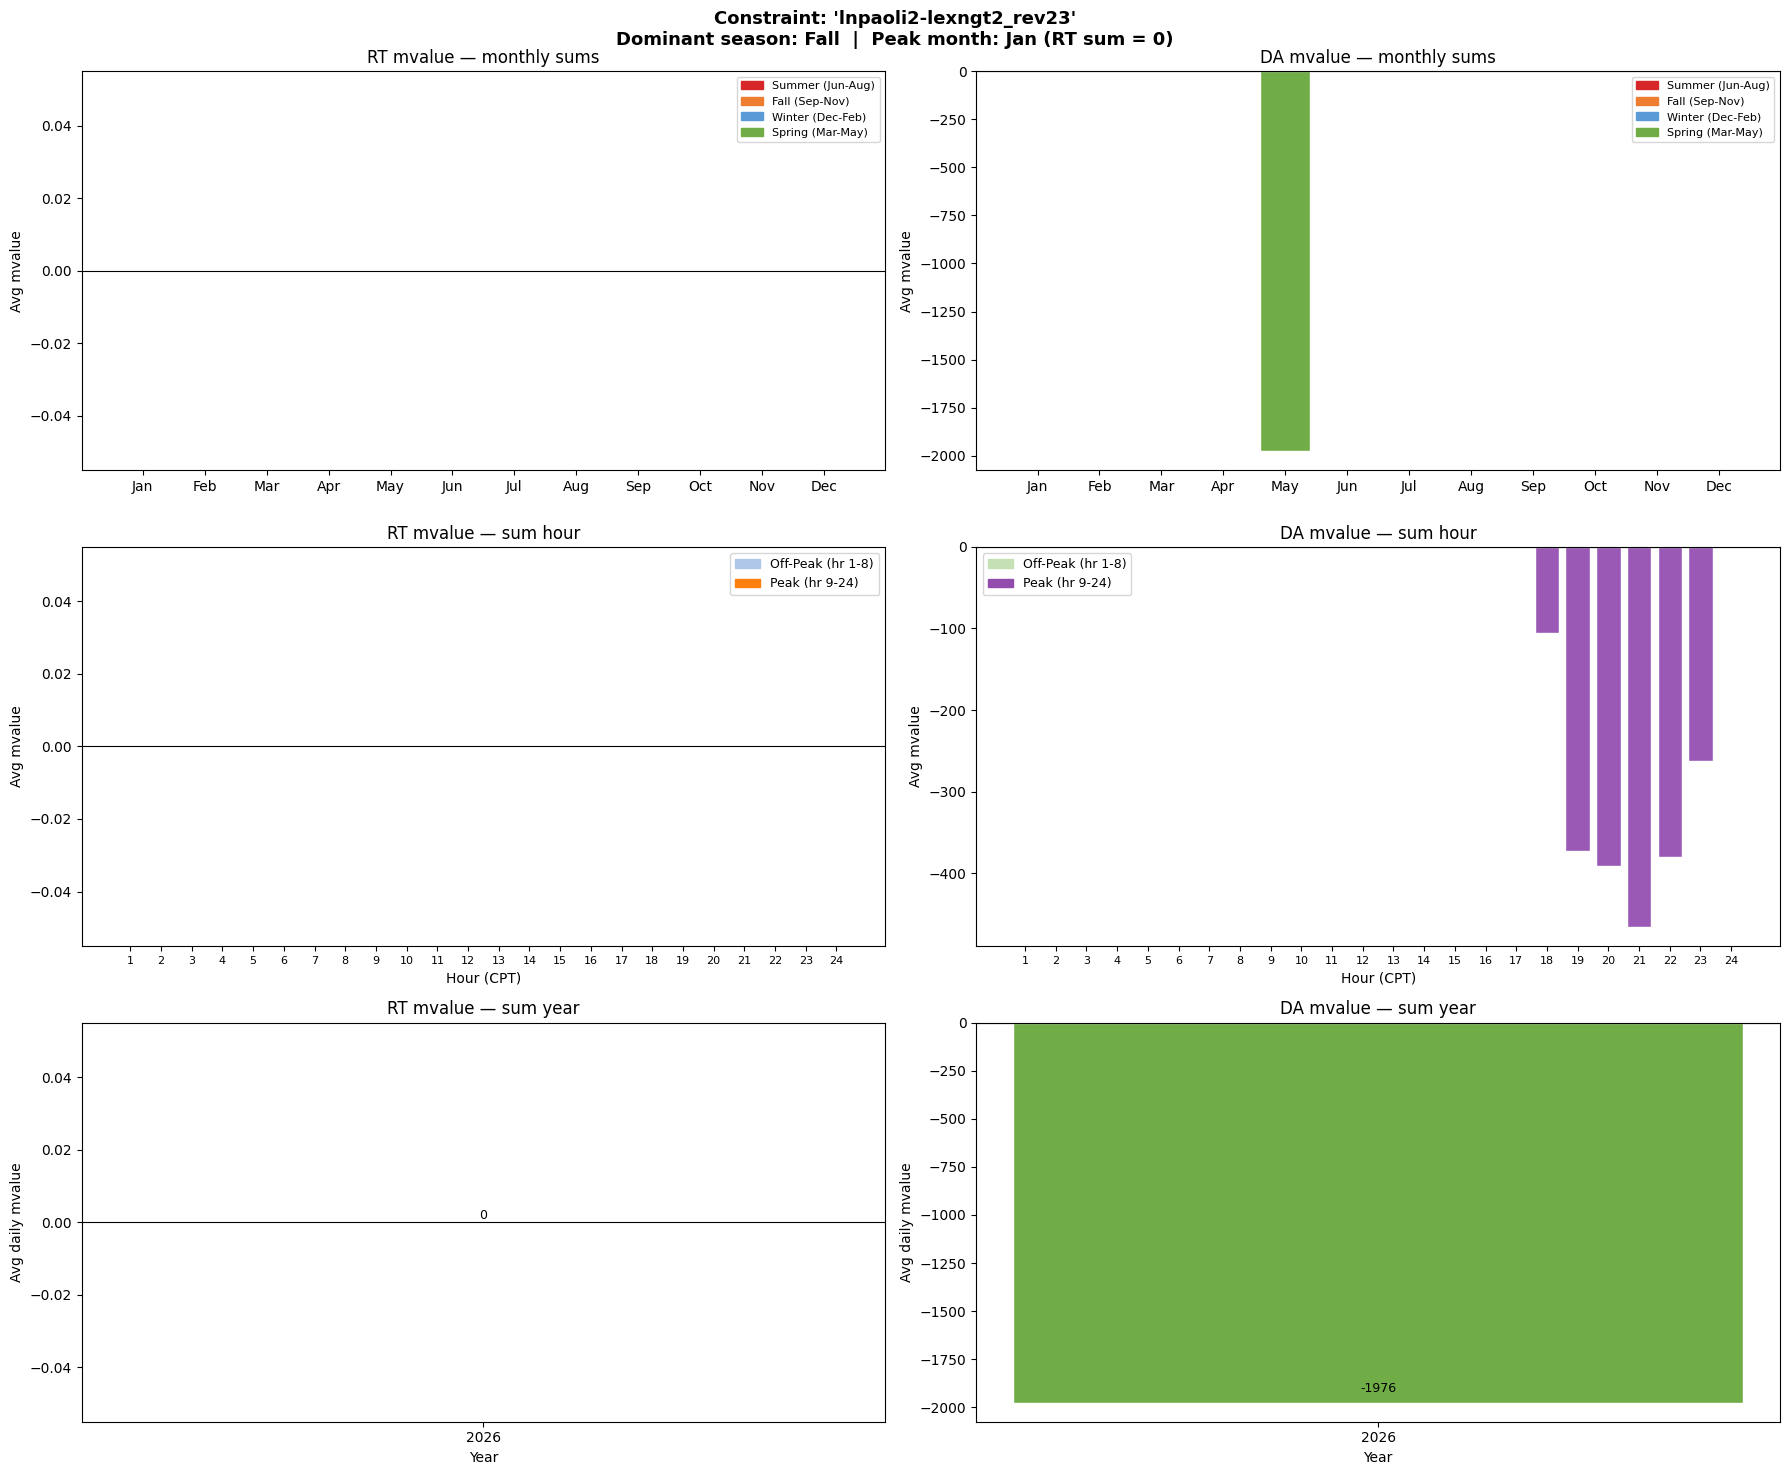

Dominant season : Fall

RT  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):       0.00
DA  peak sum   (hr  9-24):   -1976.08  |  off-peak (hr 1-8):       0.00
'lnpaoli2-lexngt2_rev23'  |  2026-05-19 → 2026-05-29  |  1 days


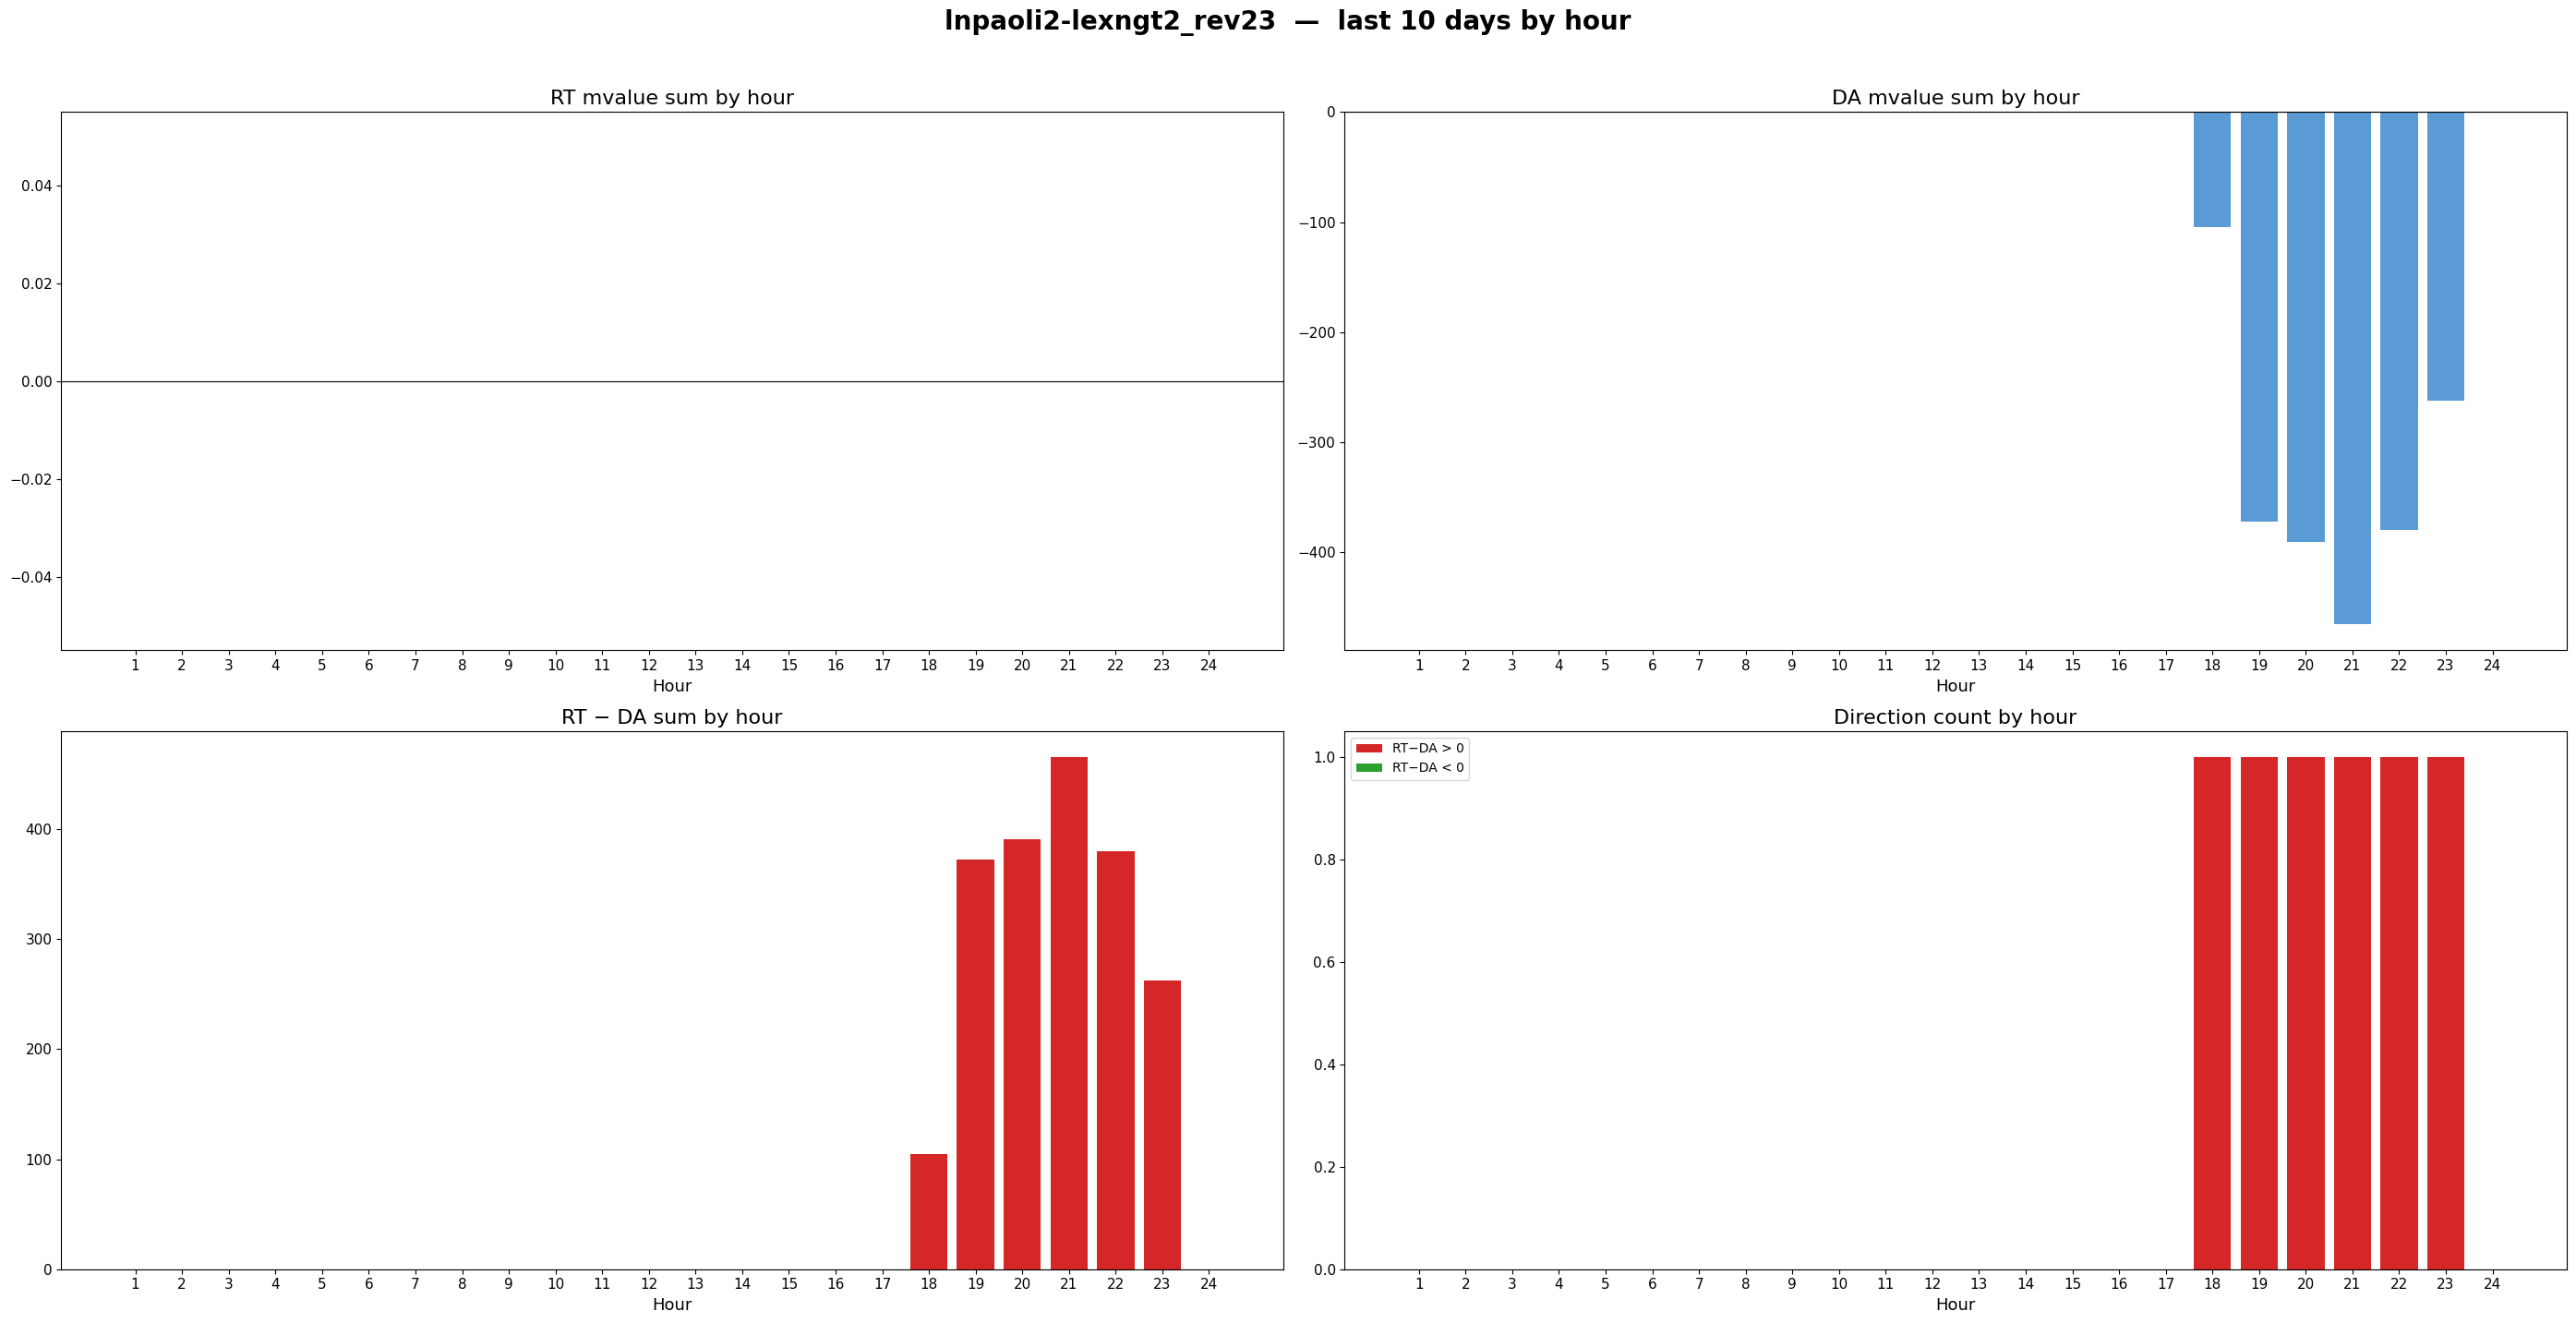

lnpaoli2-lexngt2_rev23 could not find the dfax value


Constraint  : 'lnsnrpmpt4-osage_og'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0029  |  Total hours: 17472


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
0,lnsnrpmpt4-osage_og,4,rz4_spp_res_zonal_wind_forecast_f,0.0029,0.0,-1.0
1,lnsnrpmpt4-osage_og,4,rz4_spp_res_zonal_load_forecast_f,0.0029,0.0,-1.0


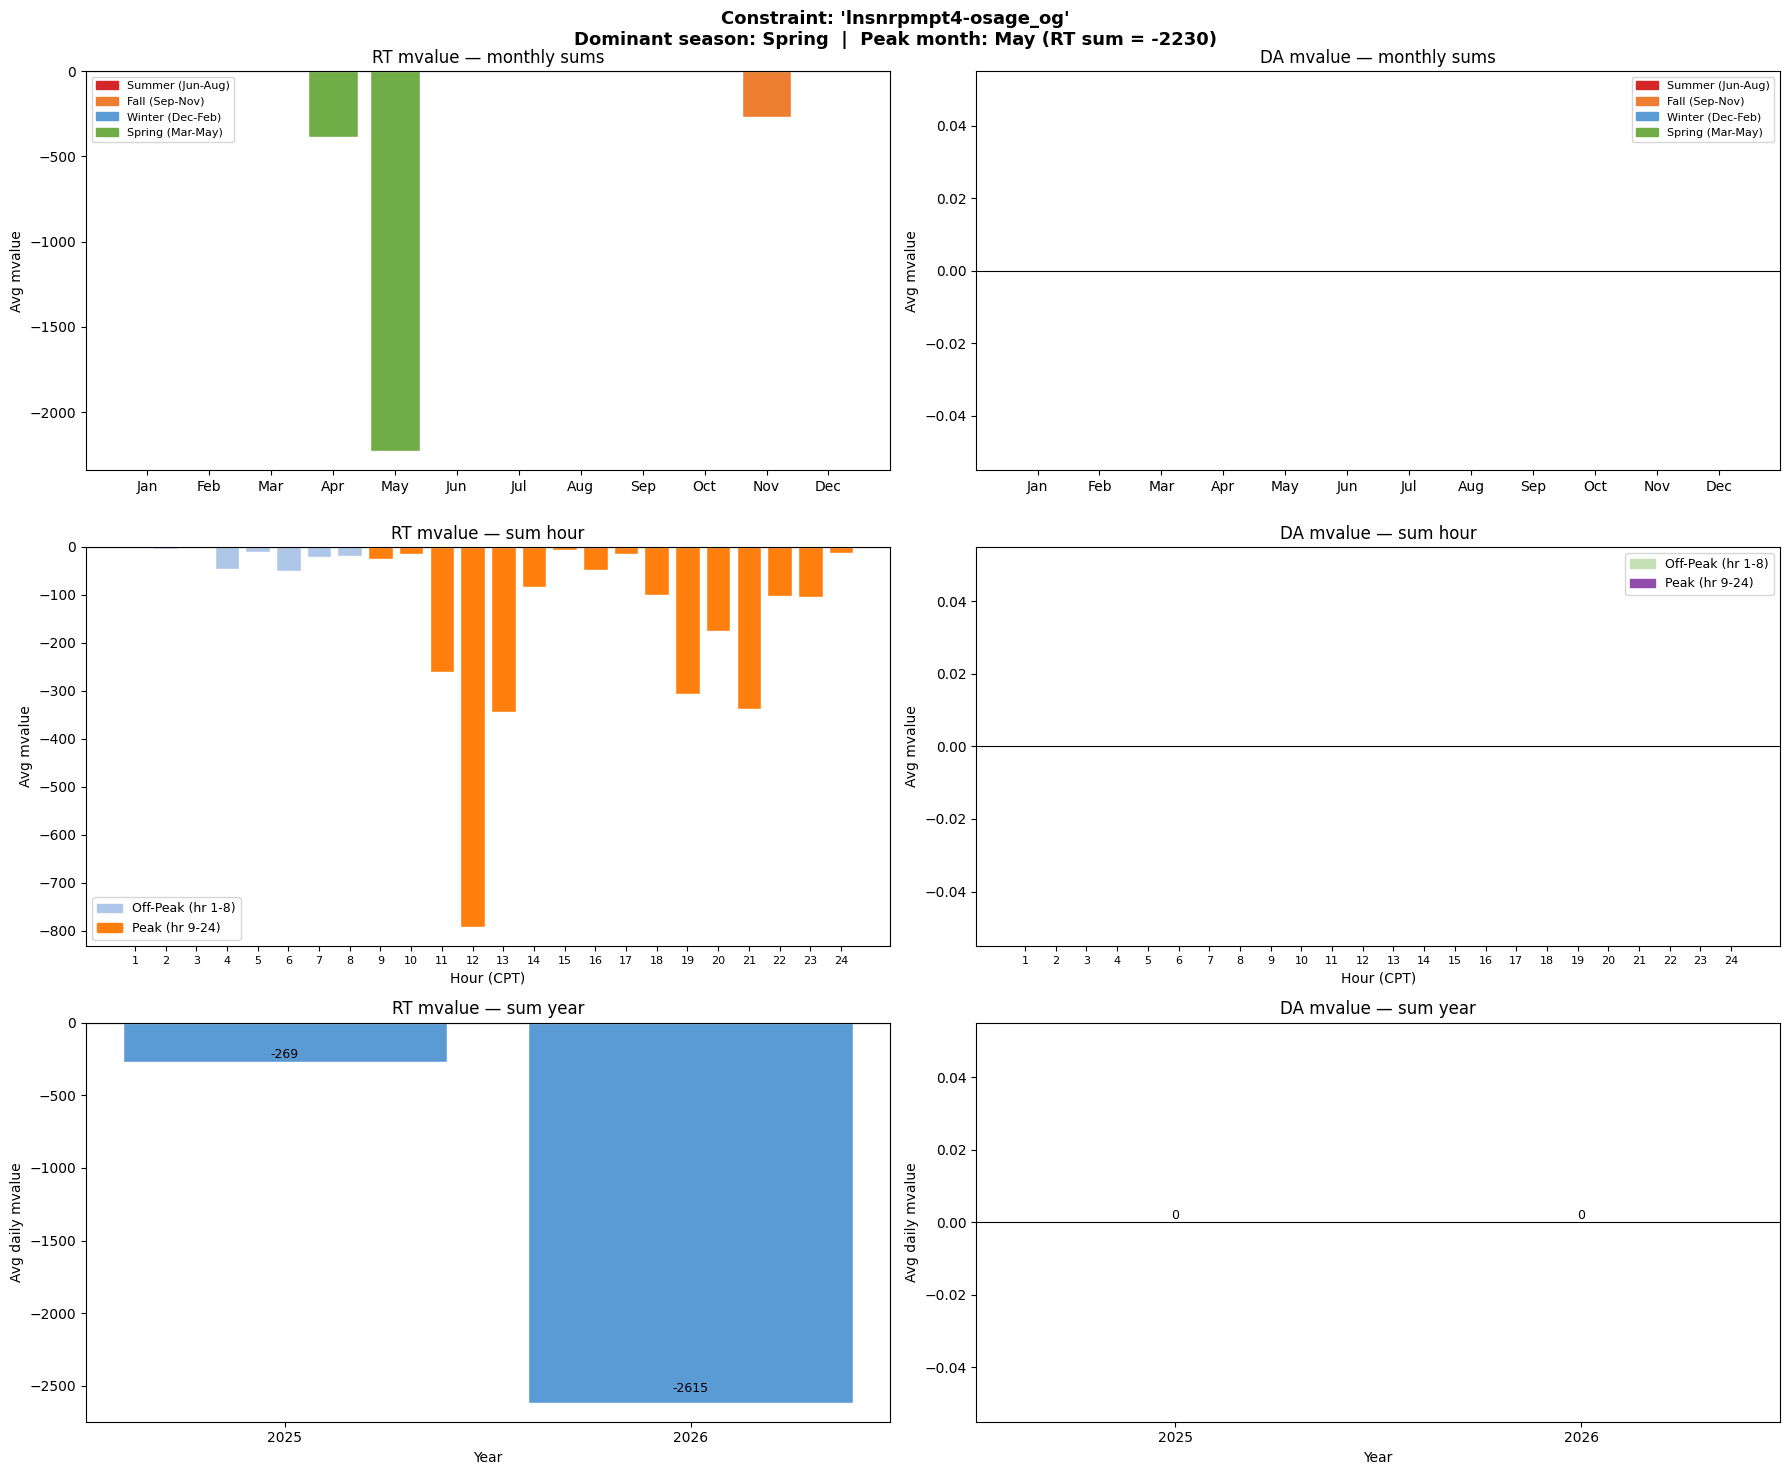

Dominant season : Spring

RT  peak sum   (hr  9-24):   -2728.97  |  off-peak (hr 1-8):    -155.15
DA  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):       0.00
'lnsnrpmpt4-osage_og'  |  2026-05-19 → 2026-05-29  |  3 days


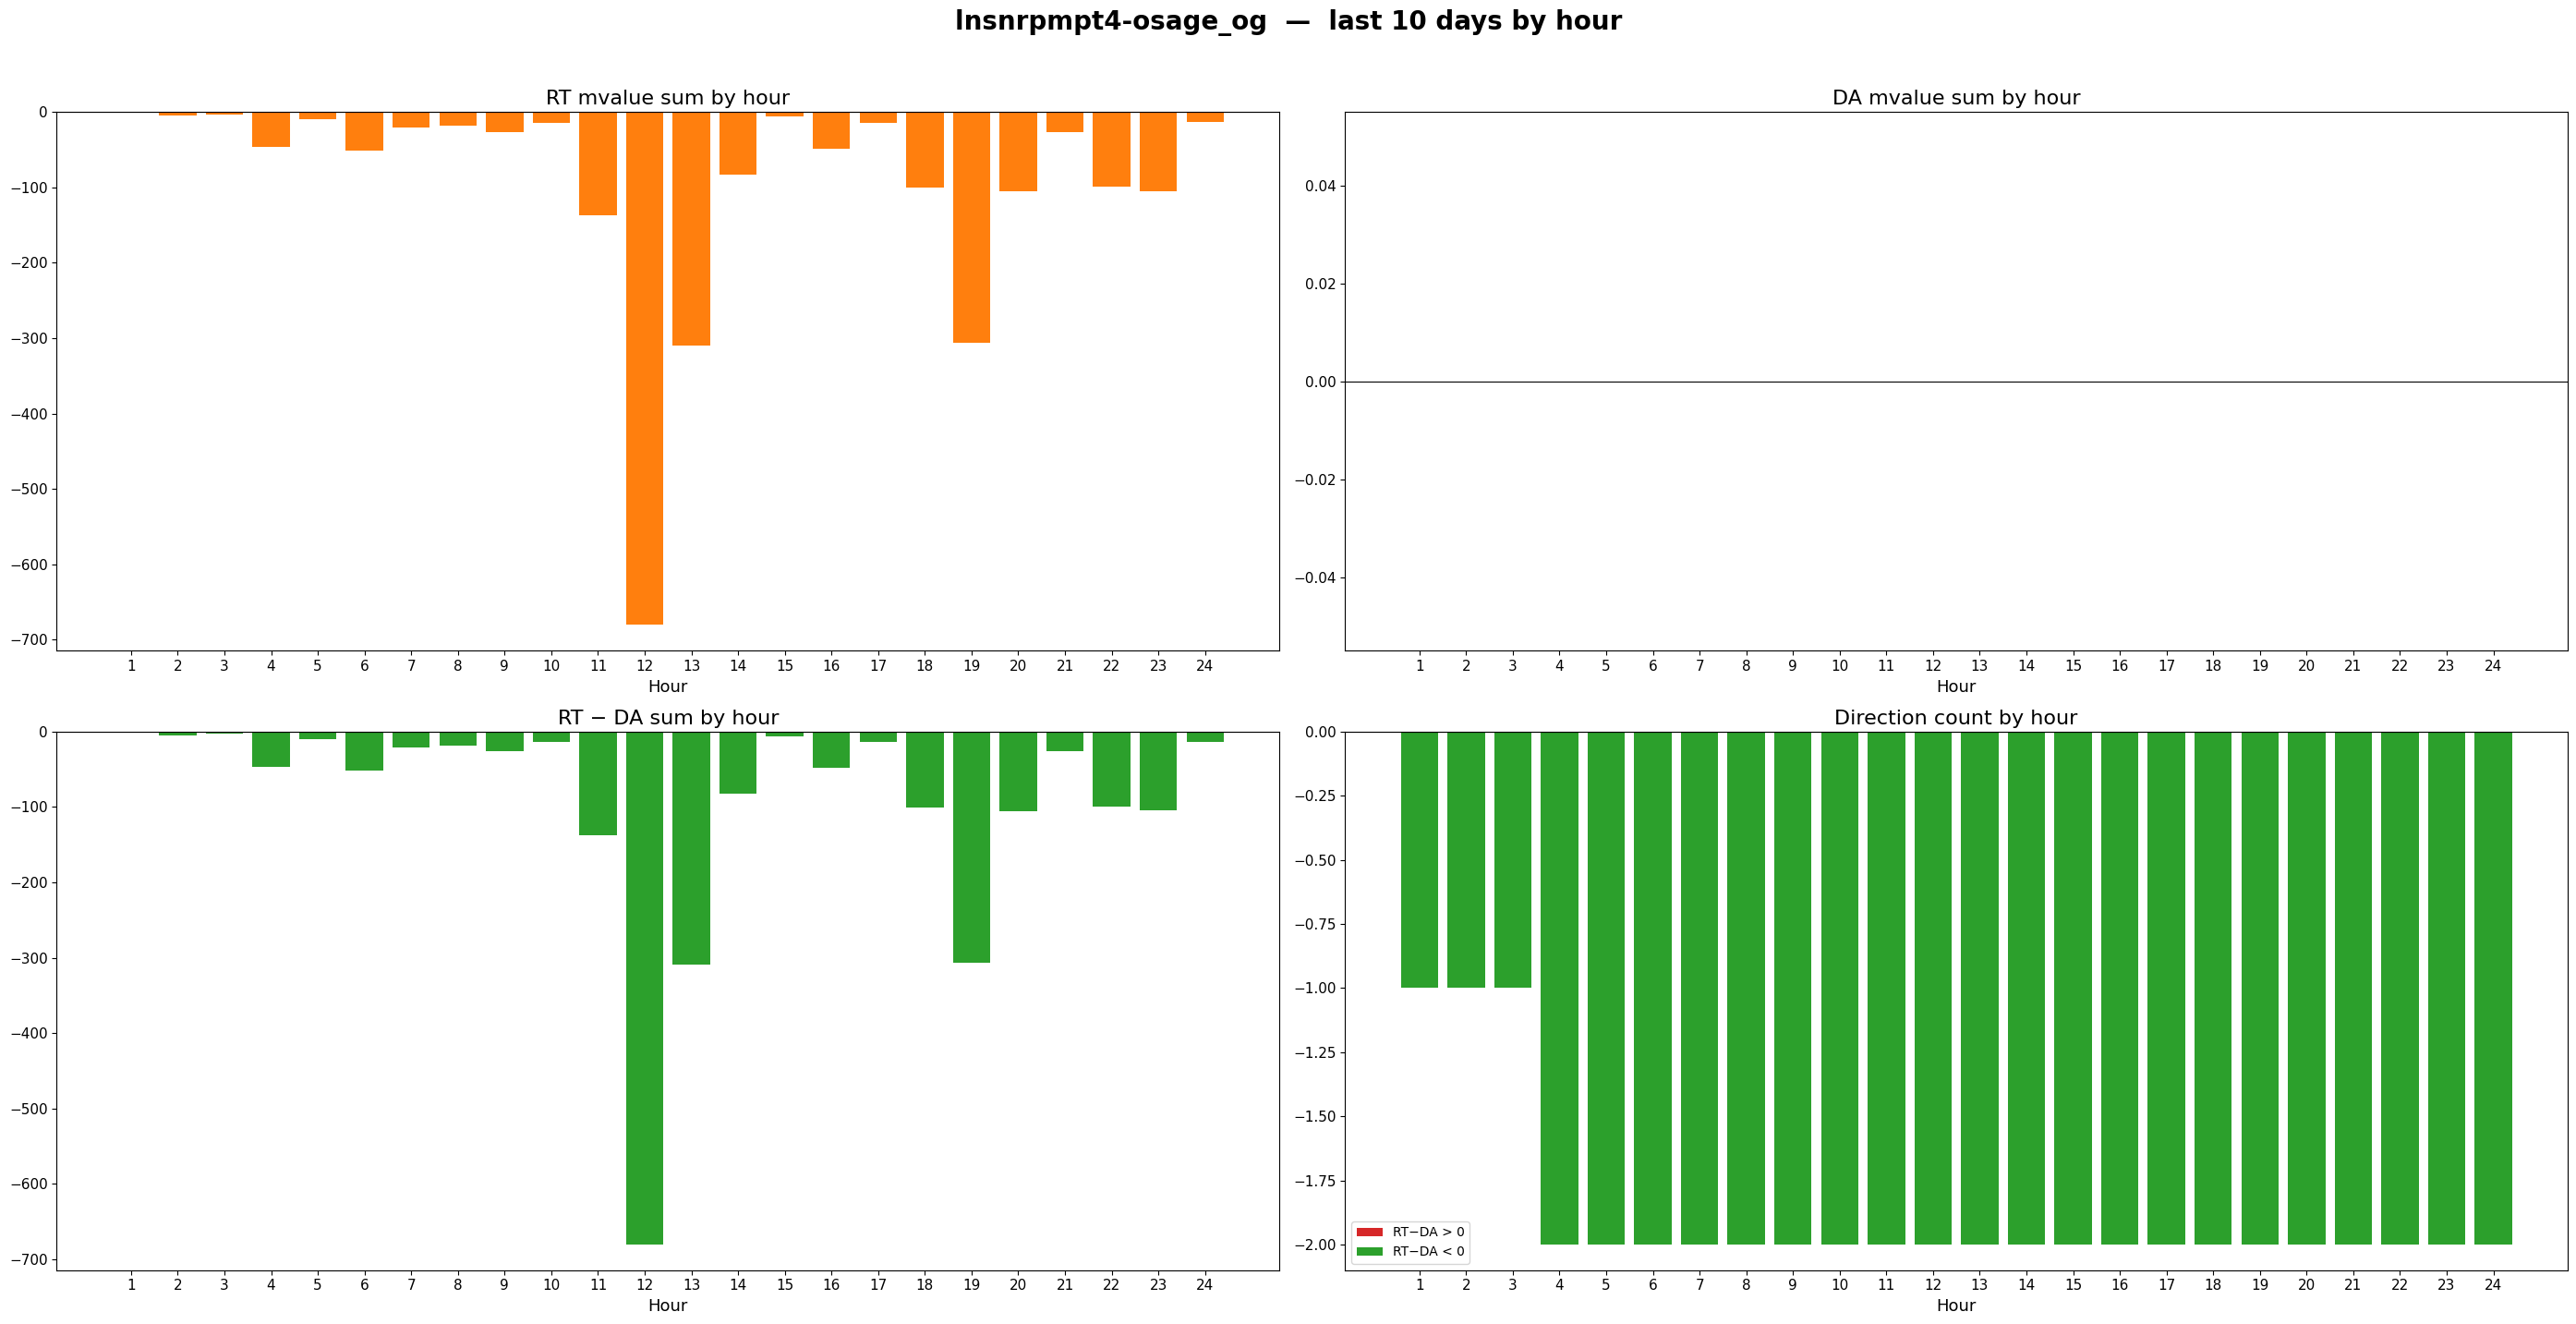

lnsnrpmpt4-osage_og could not find the dfax value


Constraint  : 'lnhuron-hurontap'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0099  |  Total hours: 17472


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
0,lnhuron-hurontap,4,rz4_spp_res_zonal_wind_forecast_f,0.0099,0.0,-1.0
1,lnhuron-hurontap,4,rz4_spp_res_zonal_load_forecast_f,0.0099,0.0,-1.0


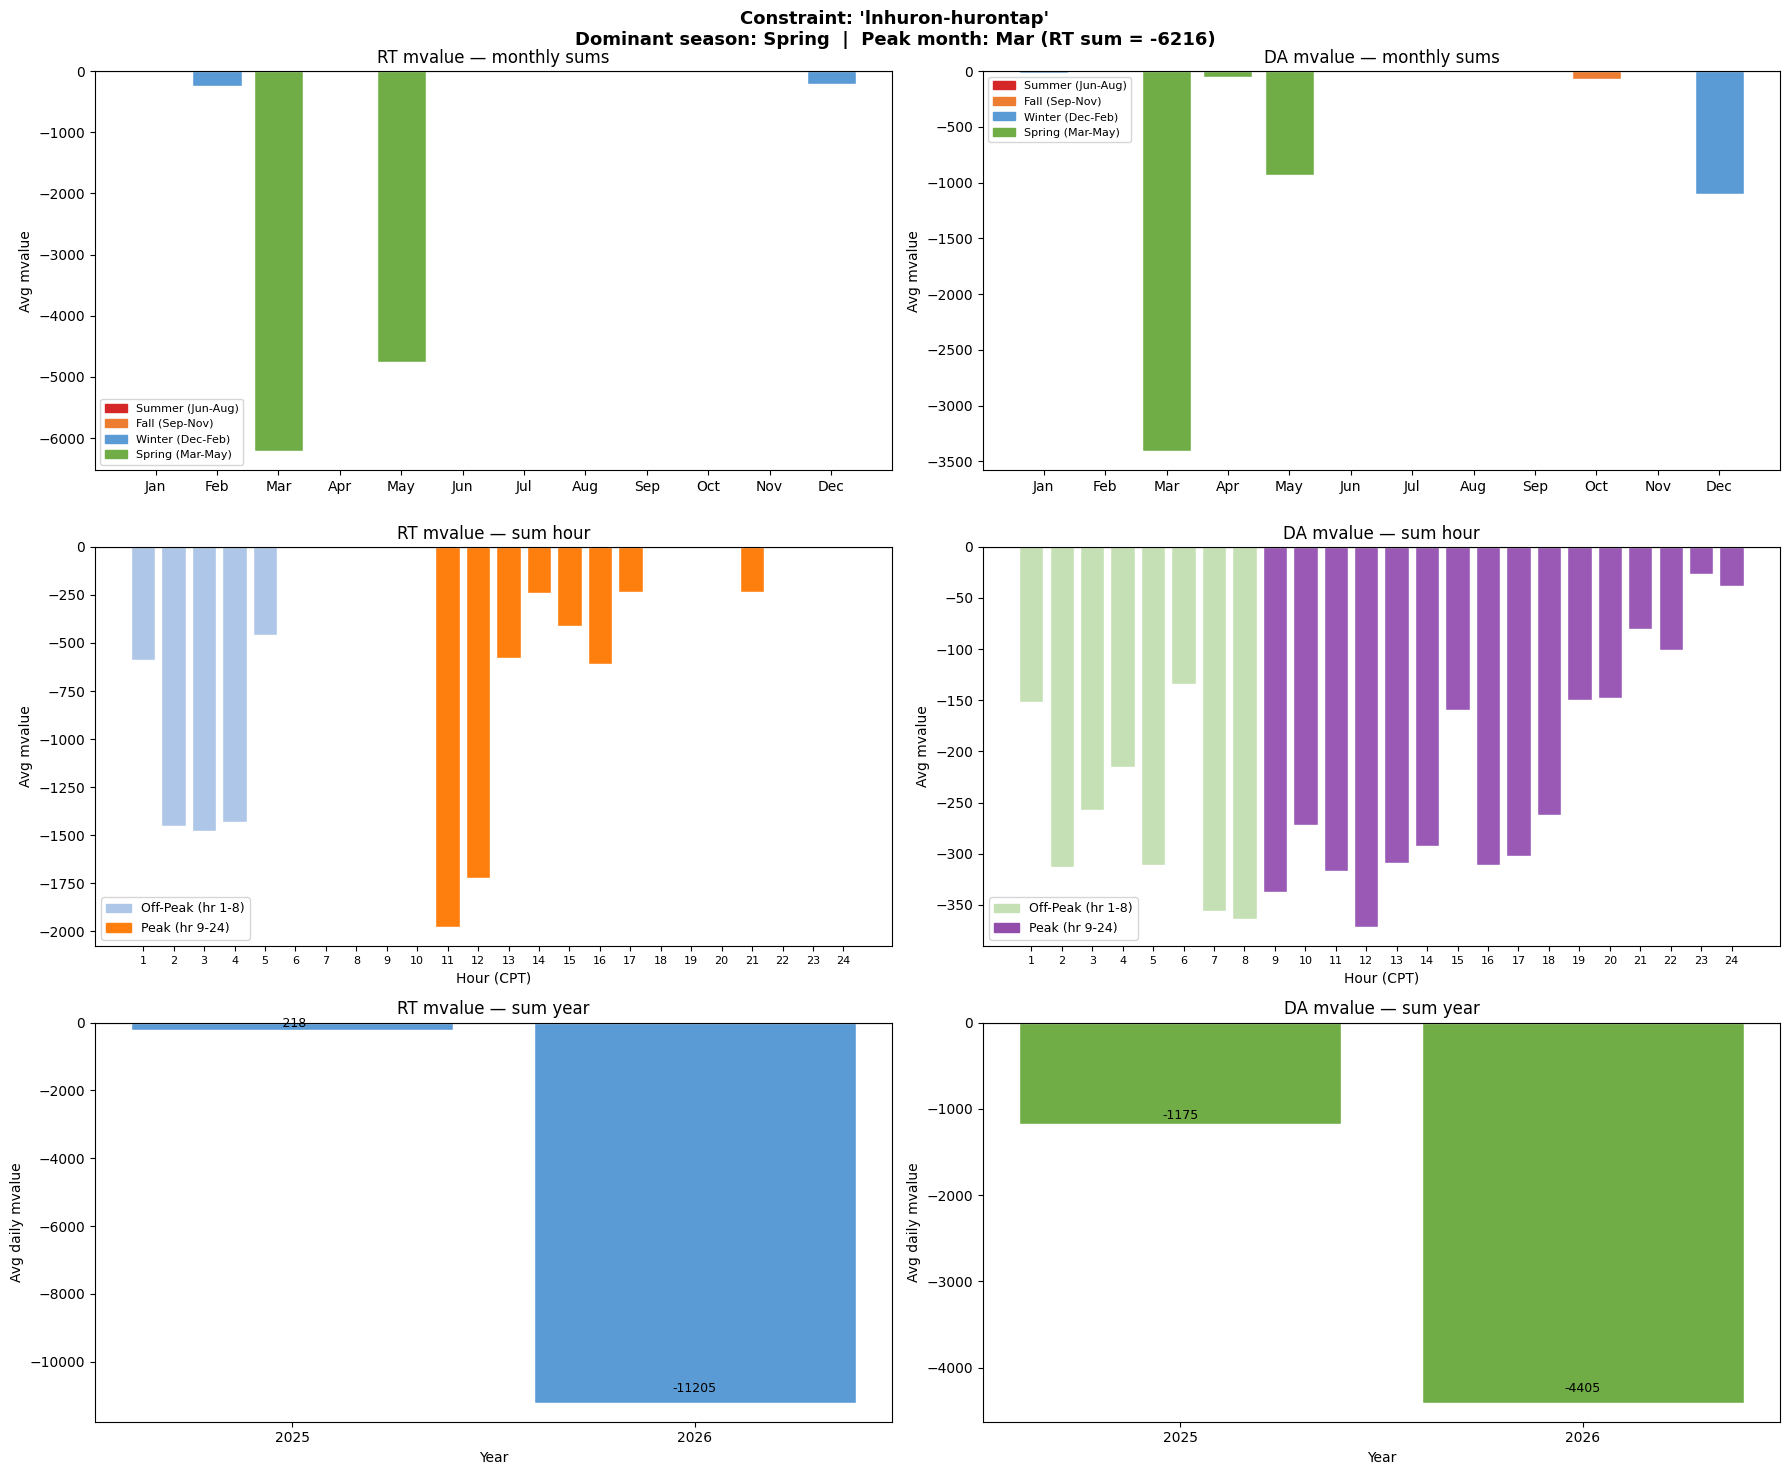

Dominant season : Spring

RT  peak sum   (hr  9-24):   -6013.37  |  off-peak (hr 1-8):   -5409.44
DA  peak sum   (hr  9-24):   -3477.22  |  off-peak (hr 1-8):   -2102.91
'lnhuron-hurontap'  |  2026-05-19 → 2026-05-29  |  6 days


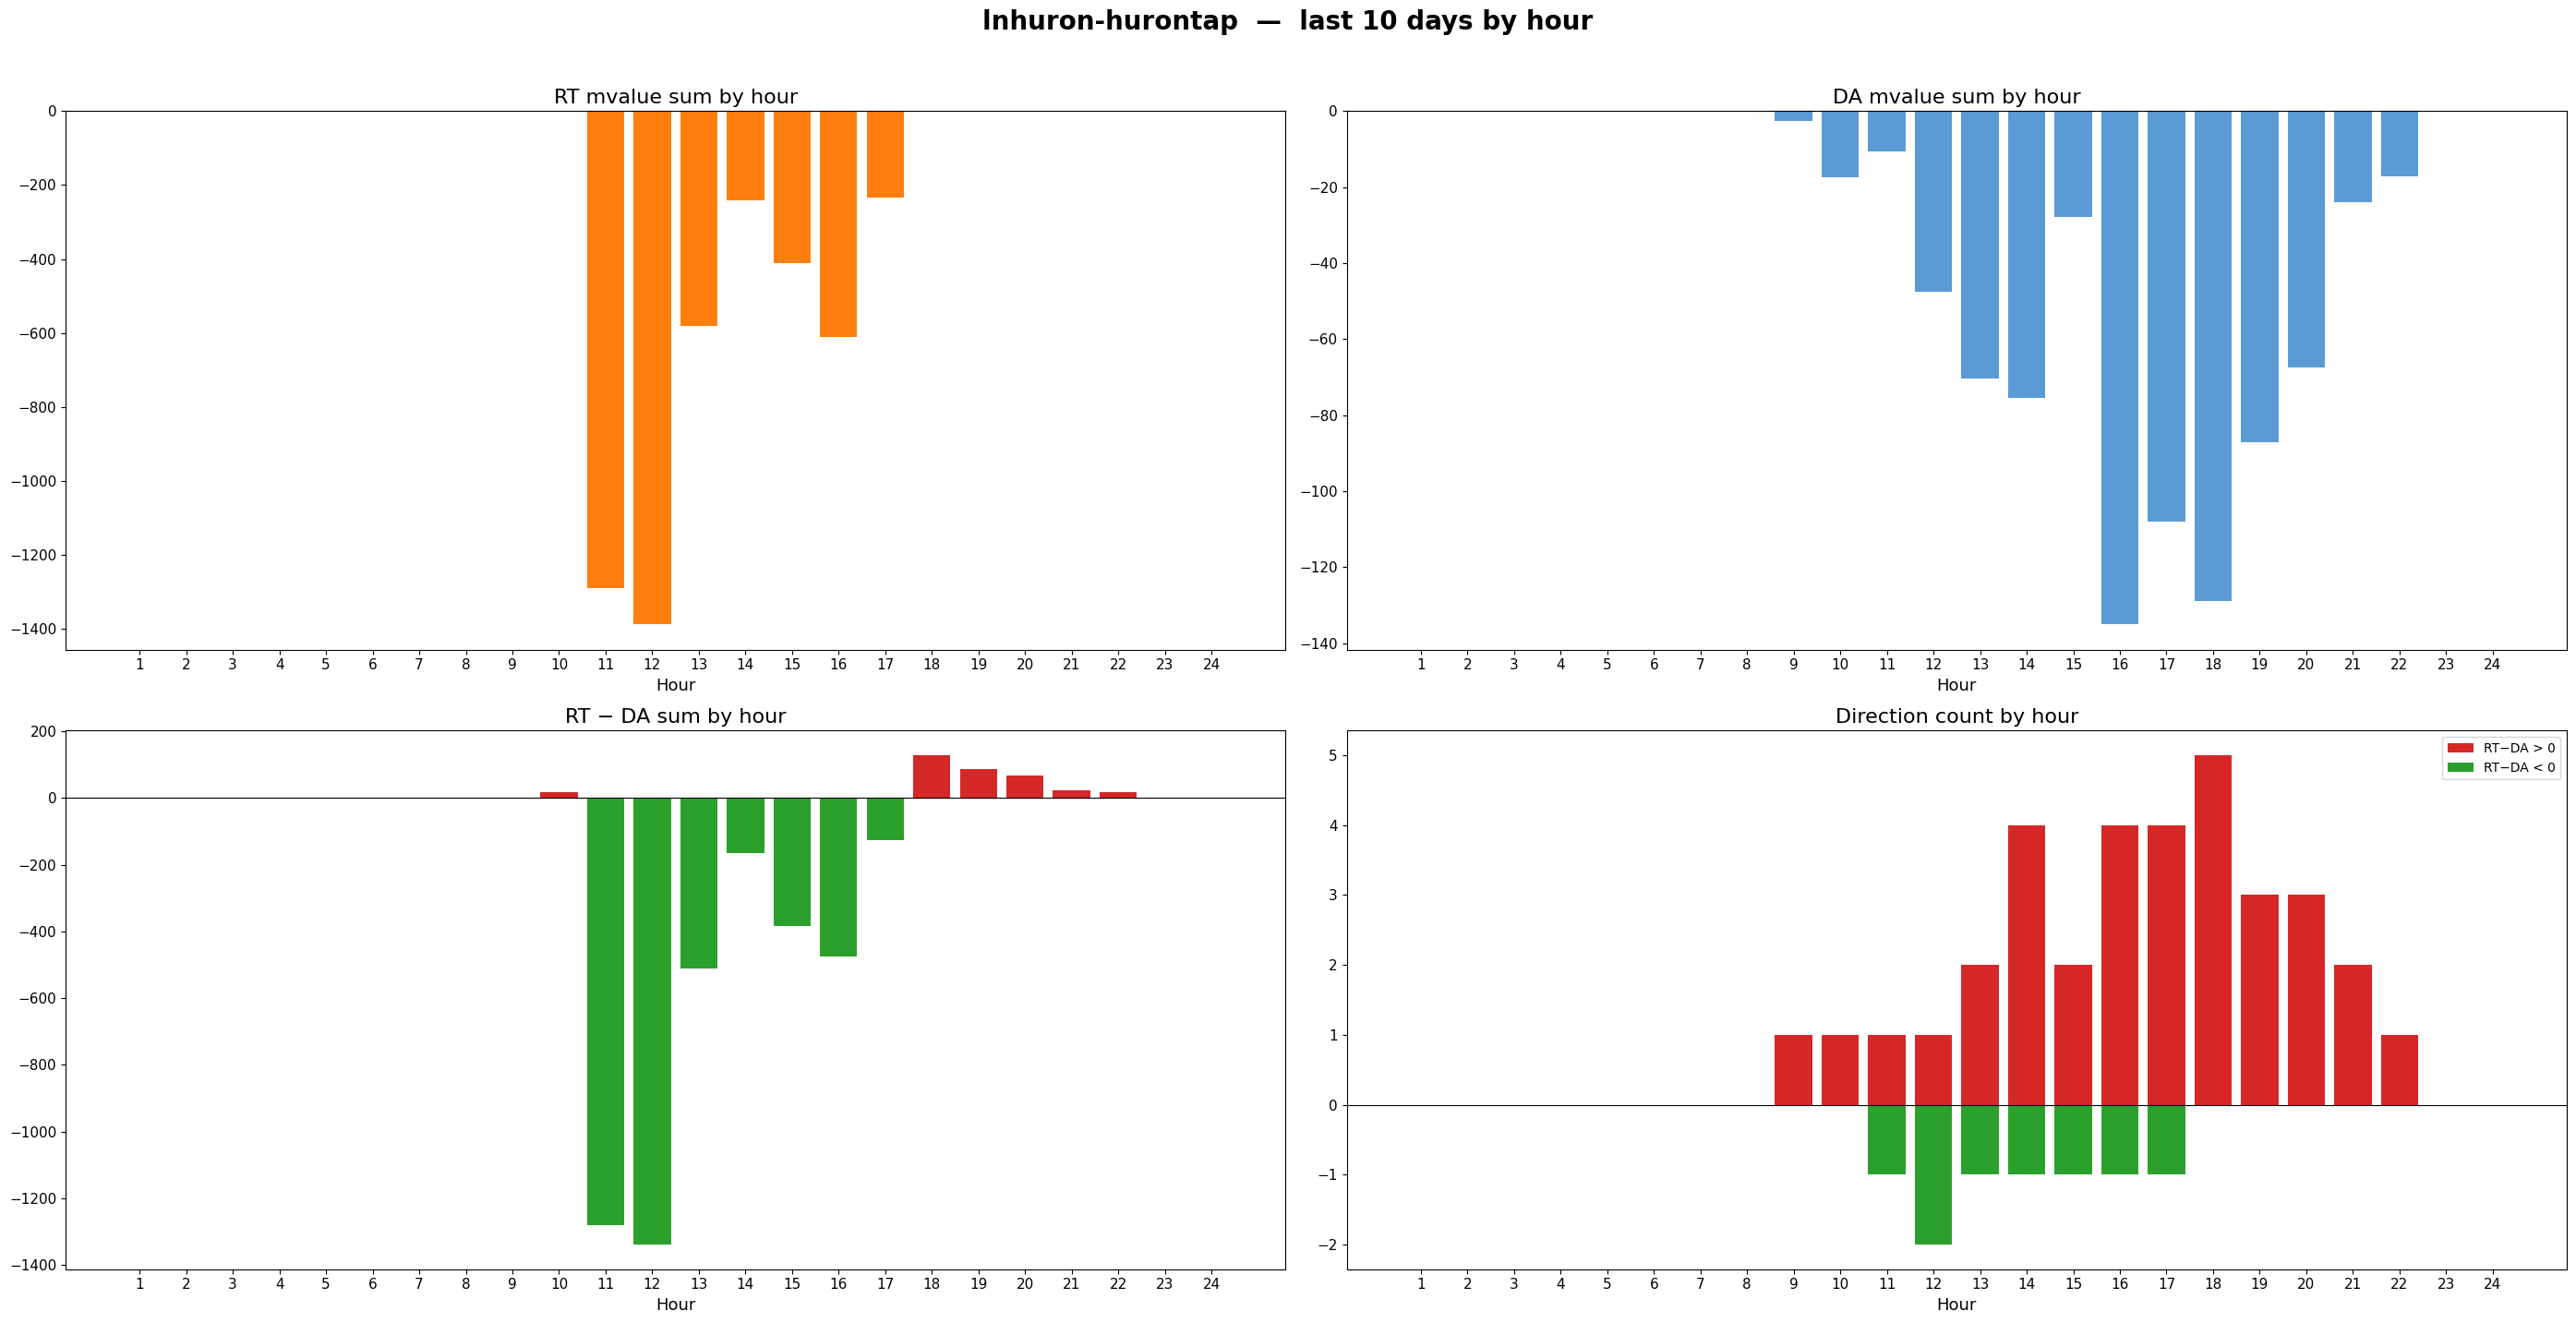


Total rows: 2576

  lnhuron-hurontap


,node_num,dfax,corr,sign_acc,mean_pred,mean_actual,n
0,1371,0.7937,0.981191,0.875000,28.342358,28.274837,168.0
1,953,0.7937,0.978070,0.857143,28.342358,30.137325,168.0
2,952,0.6063,0.969957,0.869048,21.650462,21.053507,168.0
3,966,0.2385,0.829021,0.803571,8.516634,10.975625,168.0
4,944,0.1592,0.767041,0.827381,5.684898,5.391902,168.0
5,945,0.1592,0.767041,0.827381,5.684898,5.391902,168.0
6,958,0.0998,0.646285,0.744048,3.563774,8.277529,168.0
7,978,0.0733,0.562897,0.779762,2.617481,4.131249,168.0
8,946,0.1377,0.507311,0.732143,4.917151,10.267522,168.0
9,906,-0.0572,0.339791,0.398810,-2.042564,0.678451,168.0


Constraint  : 'lncorntp4-naples1'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0157  |  Total hours: 17472


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
0,lncorntp4-naples1,4,rz4_spp_res_zonal_wind_forecast_f,0.0157,0.0606,2.85
1,lncorntp4-naples1,4,rz4_spp_res_zonal_load_forecast_f,0.0157,0.0000,-1.00


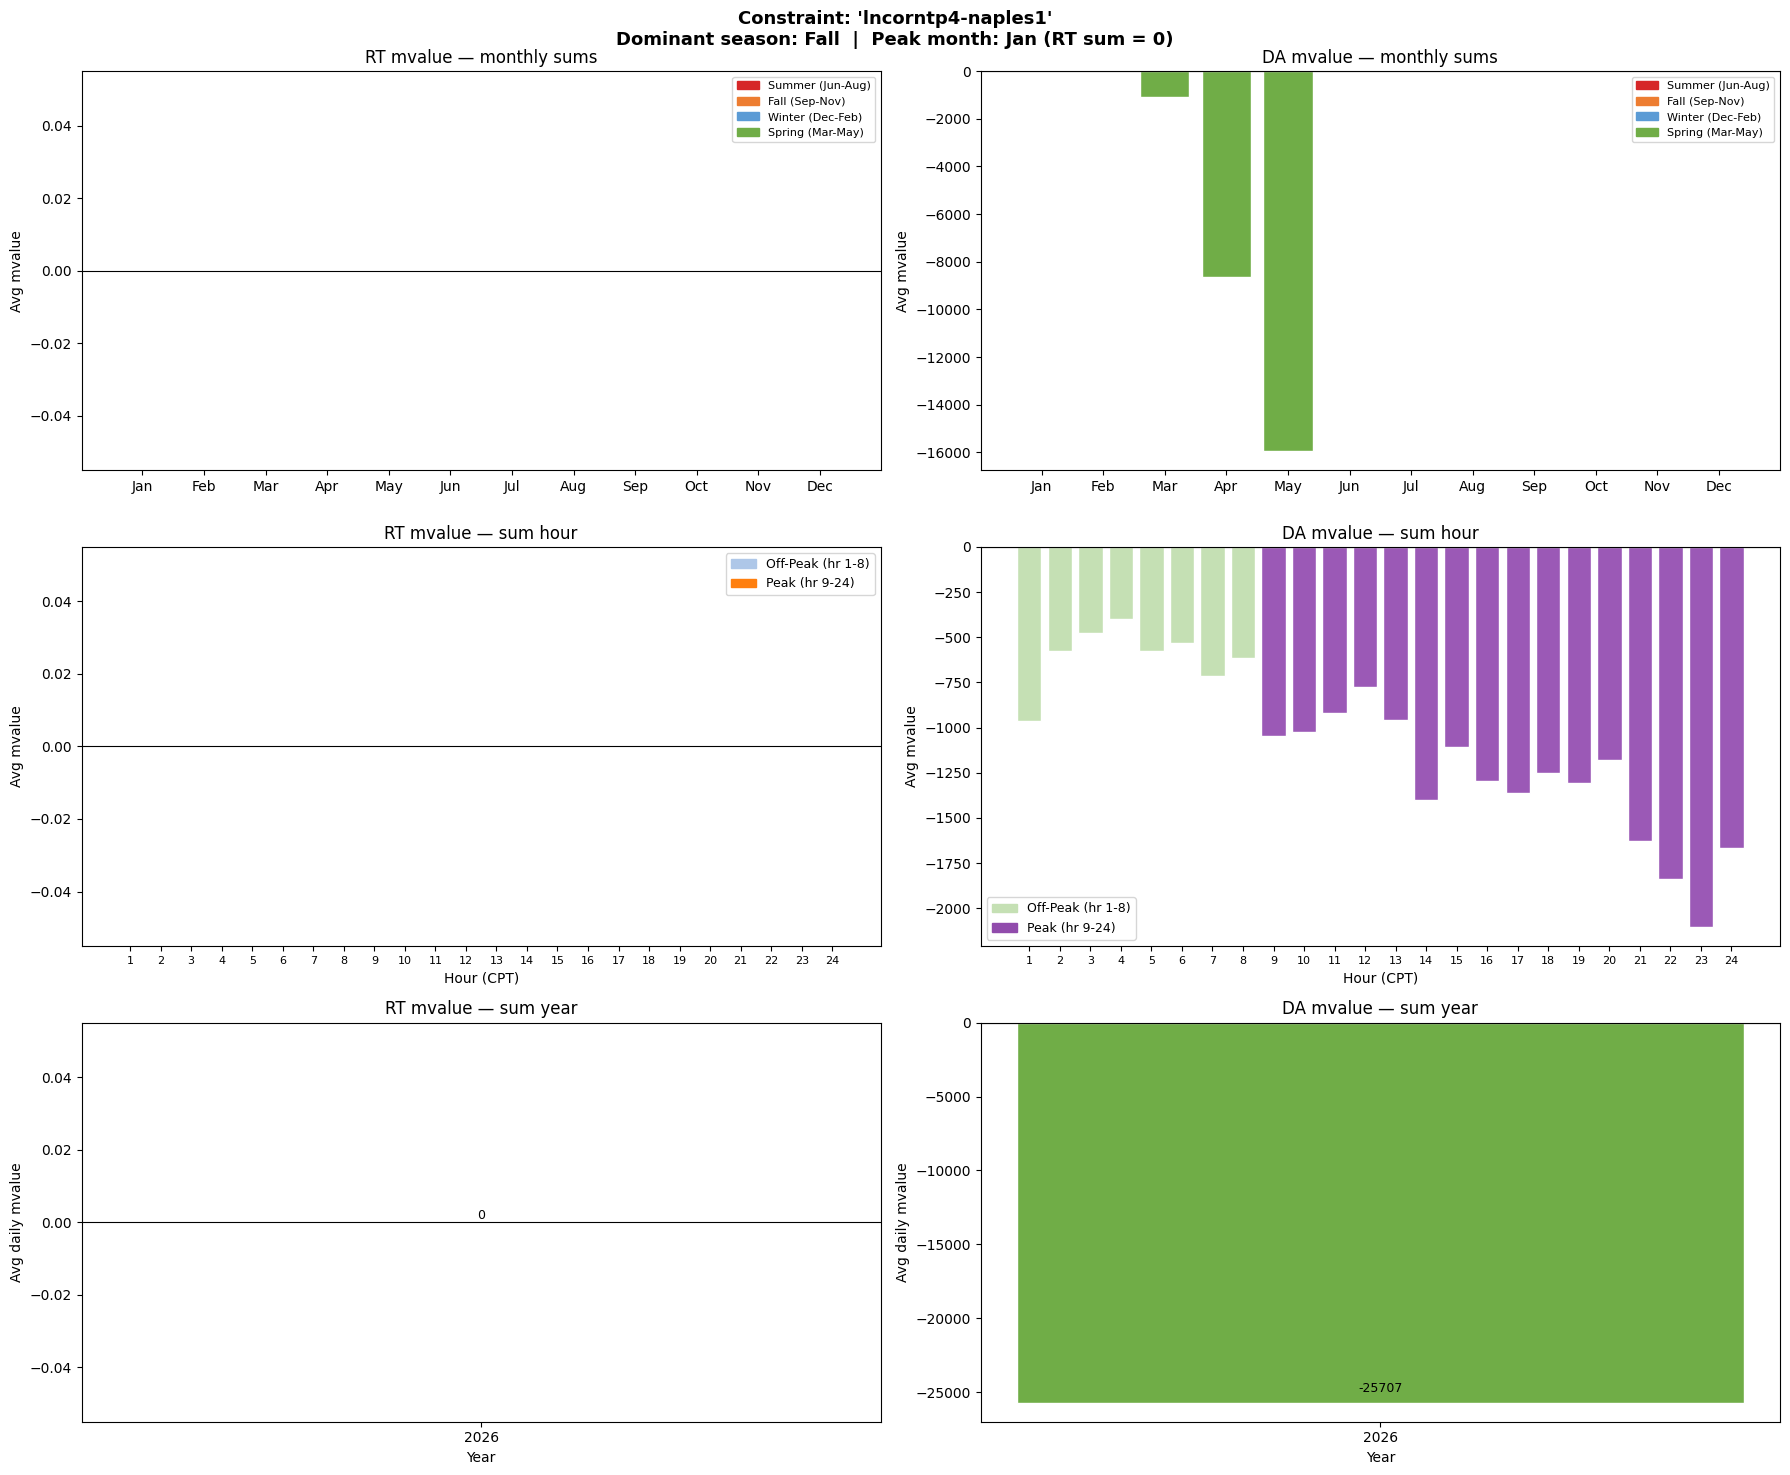

Dominant season : Fall

RT  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):       0.00
DA  peak sum   (hr  9-24):  -20859.93  |  off-peak (hr 1-8):   -4847.53
'lncorntp4-naples1'  |  2026-05-19 → 2026-05-29  |  4 days


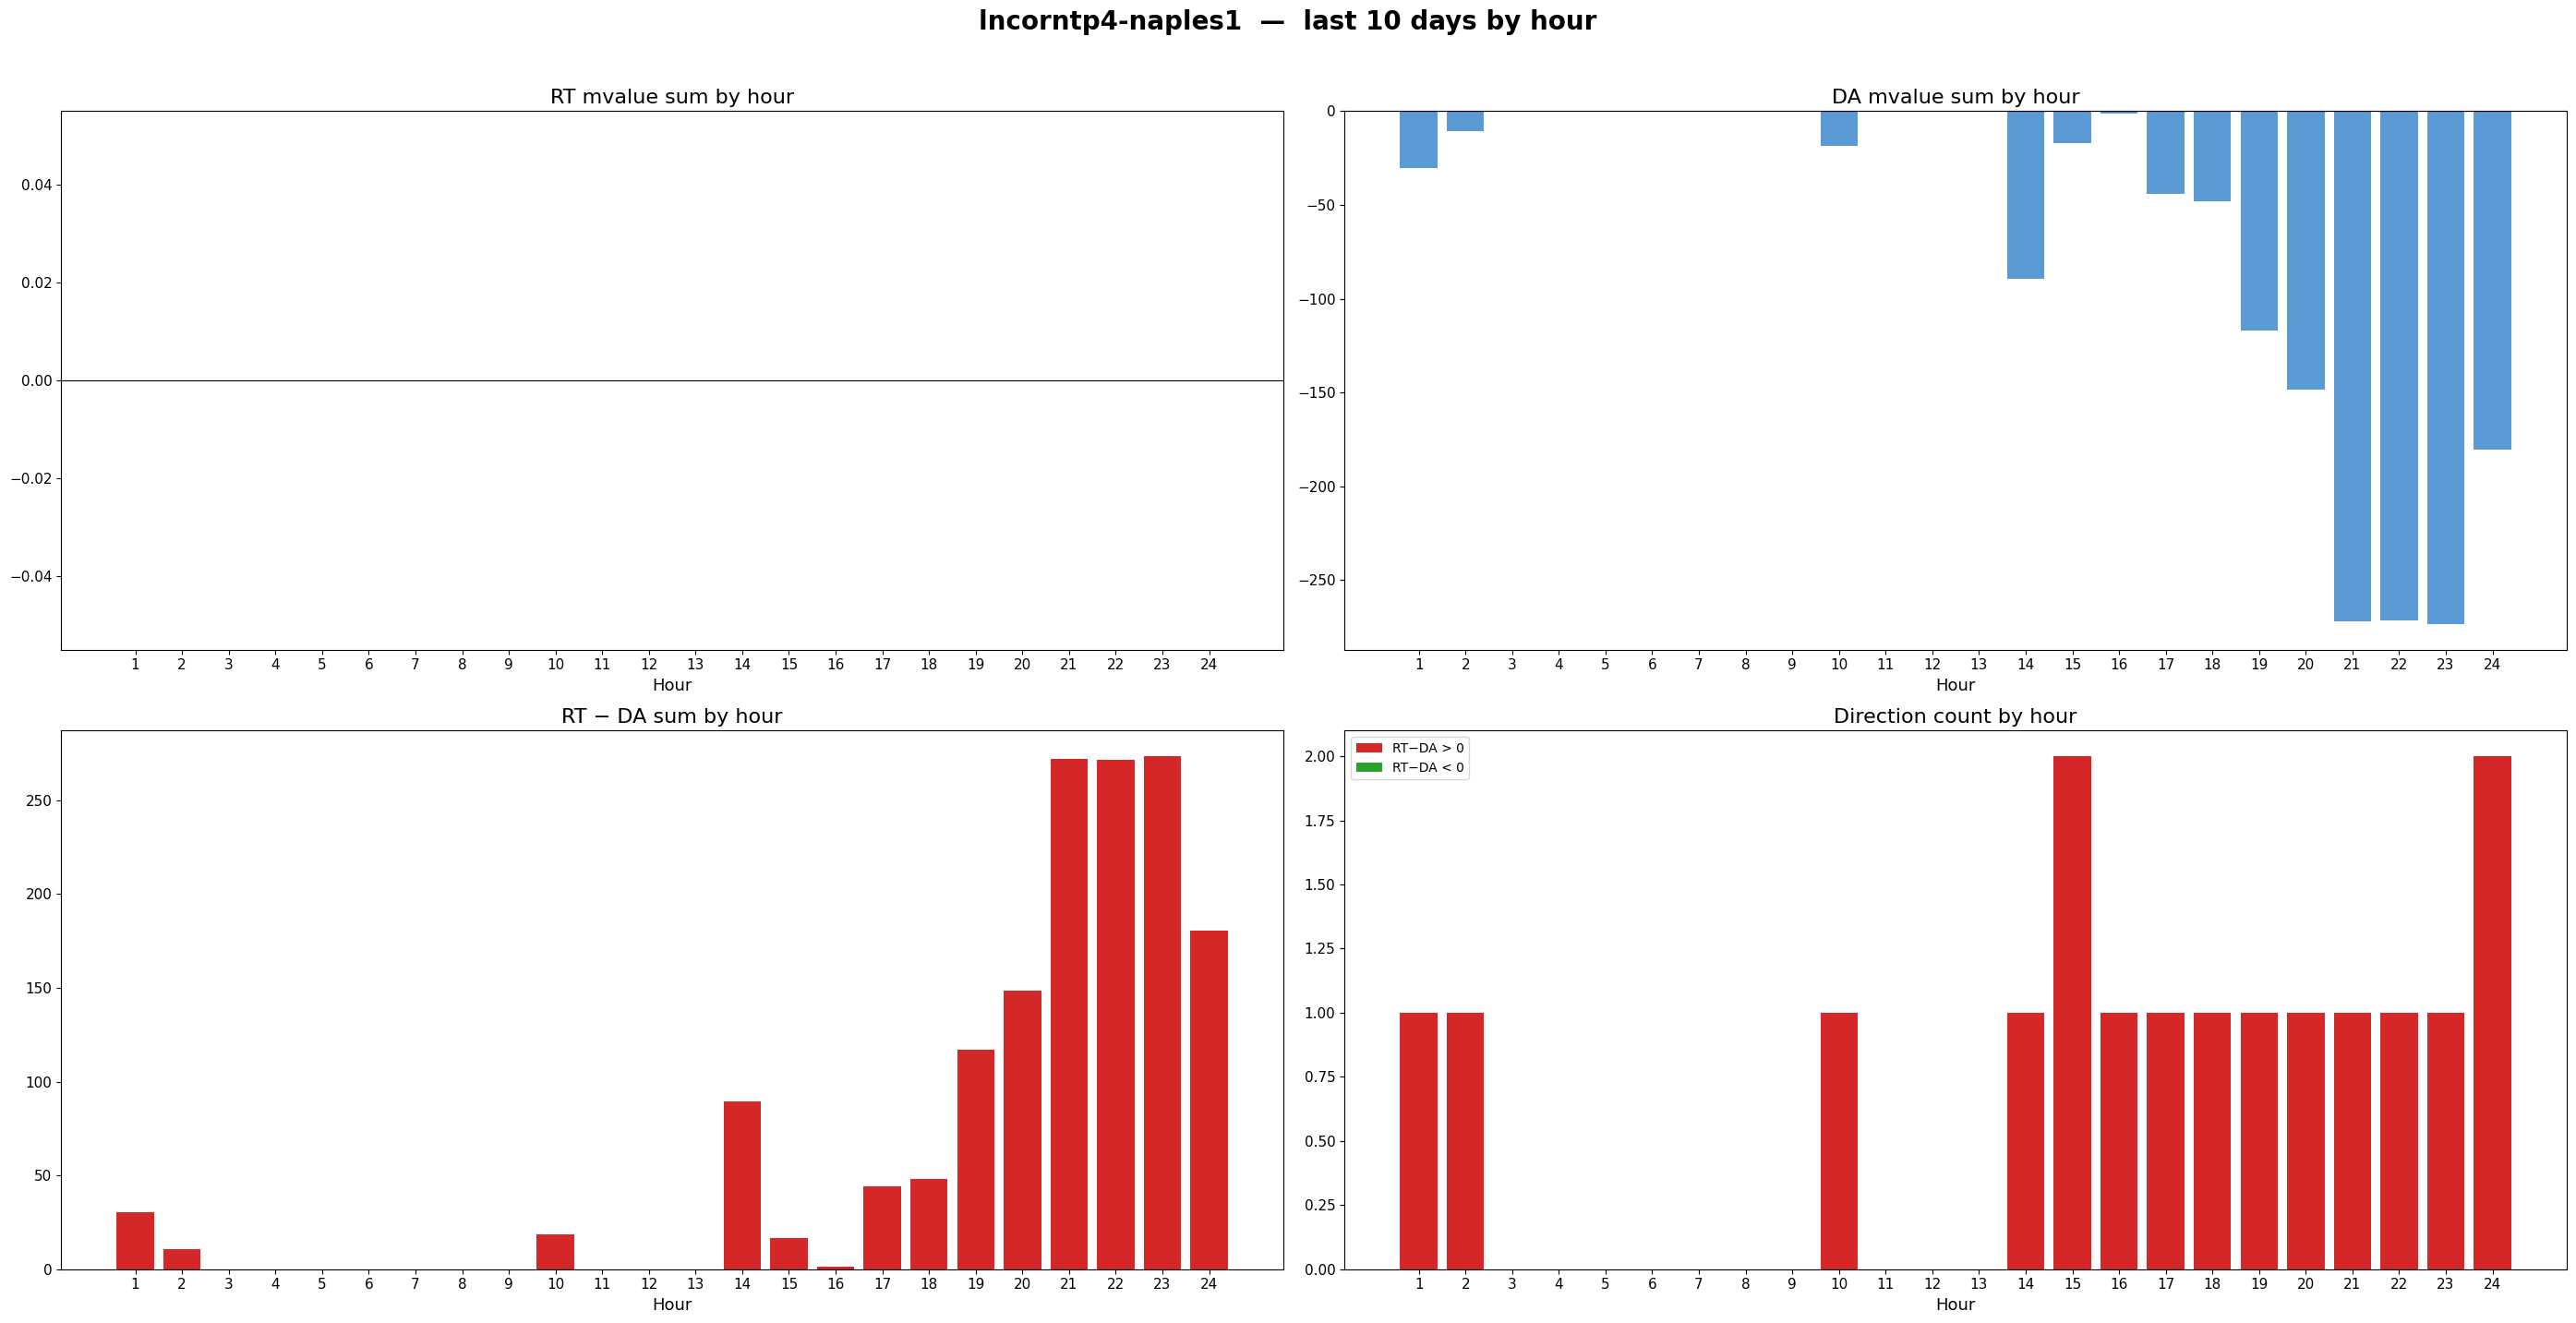


Total rows: 14850

  lncorntp4-naples1


,node_num,dfax,corr,sign_acc,mean_pred,mean_actual,n
0,1435,-0.0719,0.317708,0.342105,6.588899,-5.663504,266.0
1,747,-0.0588,0.280487,0.379699,5.388418,-2.037804,266.0
2,1110,-0.0828,0.279533,0.454887,7.587772,0.274317,266.0
3,1158,-0.0507,0.267288,0.349624,4.646136,-3.295630,266.0
4,1181,-0.0507,0.267288,0.349624,4.646136,-3.295630,266.0
5,1309,-0.0507,0.267234,0.349624,4.646136,-3.318266,266.0
6,123,-0.0507,0.266696,0.349624,4.646136,-3.300710,266.0
7,2076,-0.0507,0.239325,0.380165,4.877380,-2.467044,242.0
8,1326,-0.0604,0.226845,0.417293,5.535041,-1.022907,266.0
9,1715,-0.1056,0.224042,0.357143,9.677158,-14.022999,266.0


Constraint  : 'xfmrsiouxcy-siouxcy'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0233  |  Total hours: 17472


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
1,xfmrsiouxcy-siouxcy,4,rz4_spp_res_zonal_load_forecast_f,0.0233,0.0973,3.17
0,xfmrsiouxcy-siouxcy,4,rz4_spp_res_zonal_wind_forecast_f,0.0233,0.0011,-0.95


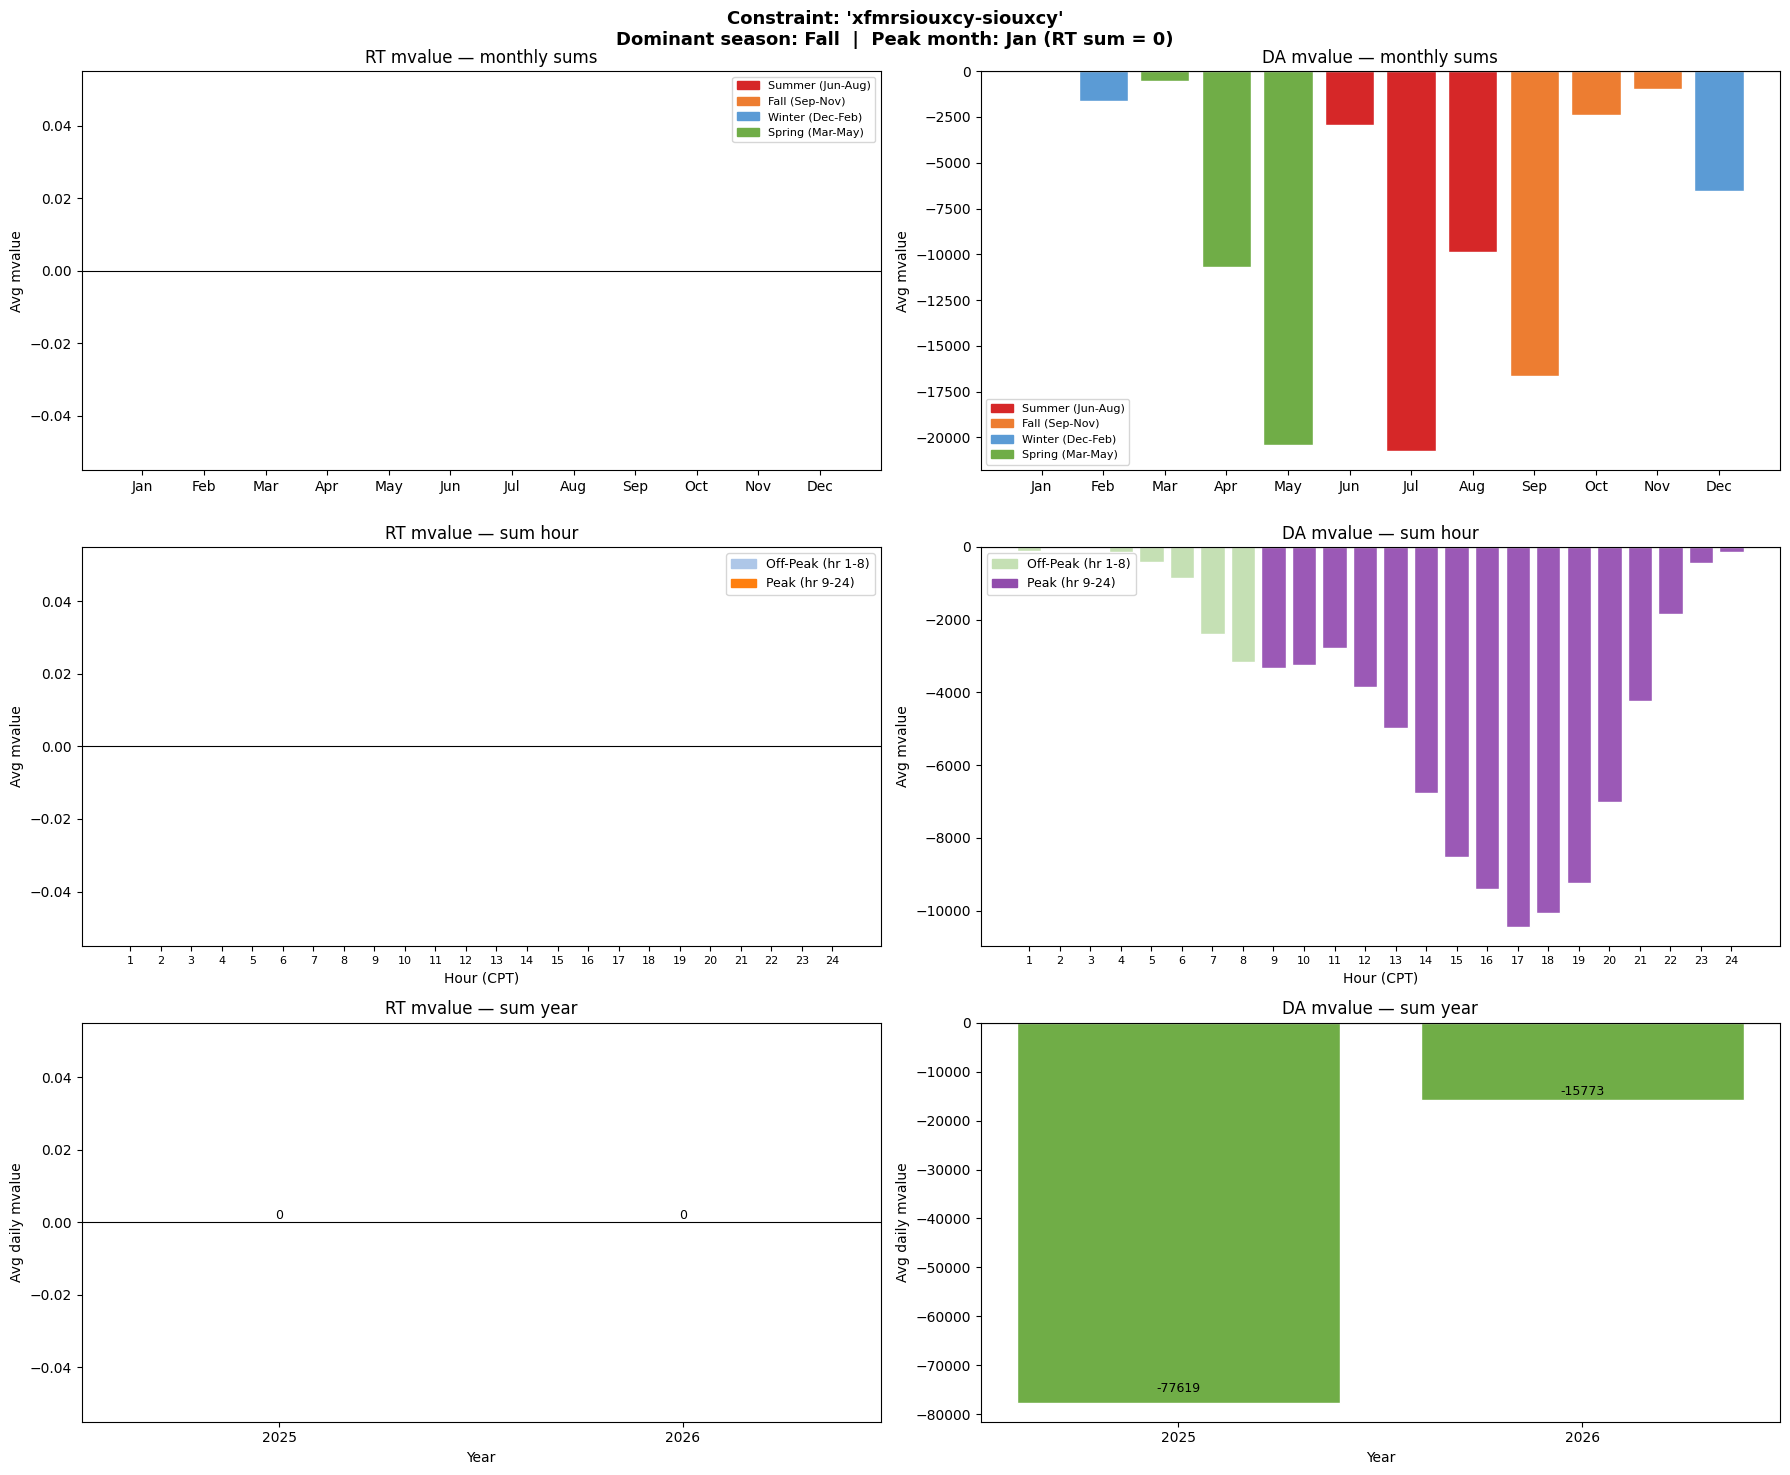

Dominant season : Fall

RT  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):       0.00
DA  peak sum   (hr  9-24):  -86329.63  |  off-peak (hr 1-8):   -7062.18
'xfmrsiouxcy-siouxcy'  |  2026-05-19 → 2026-05-29  |  3 days


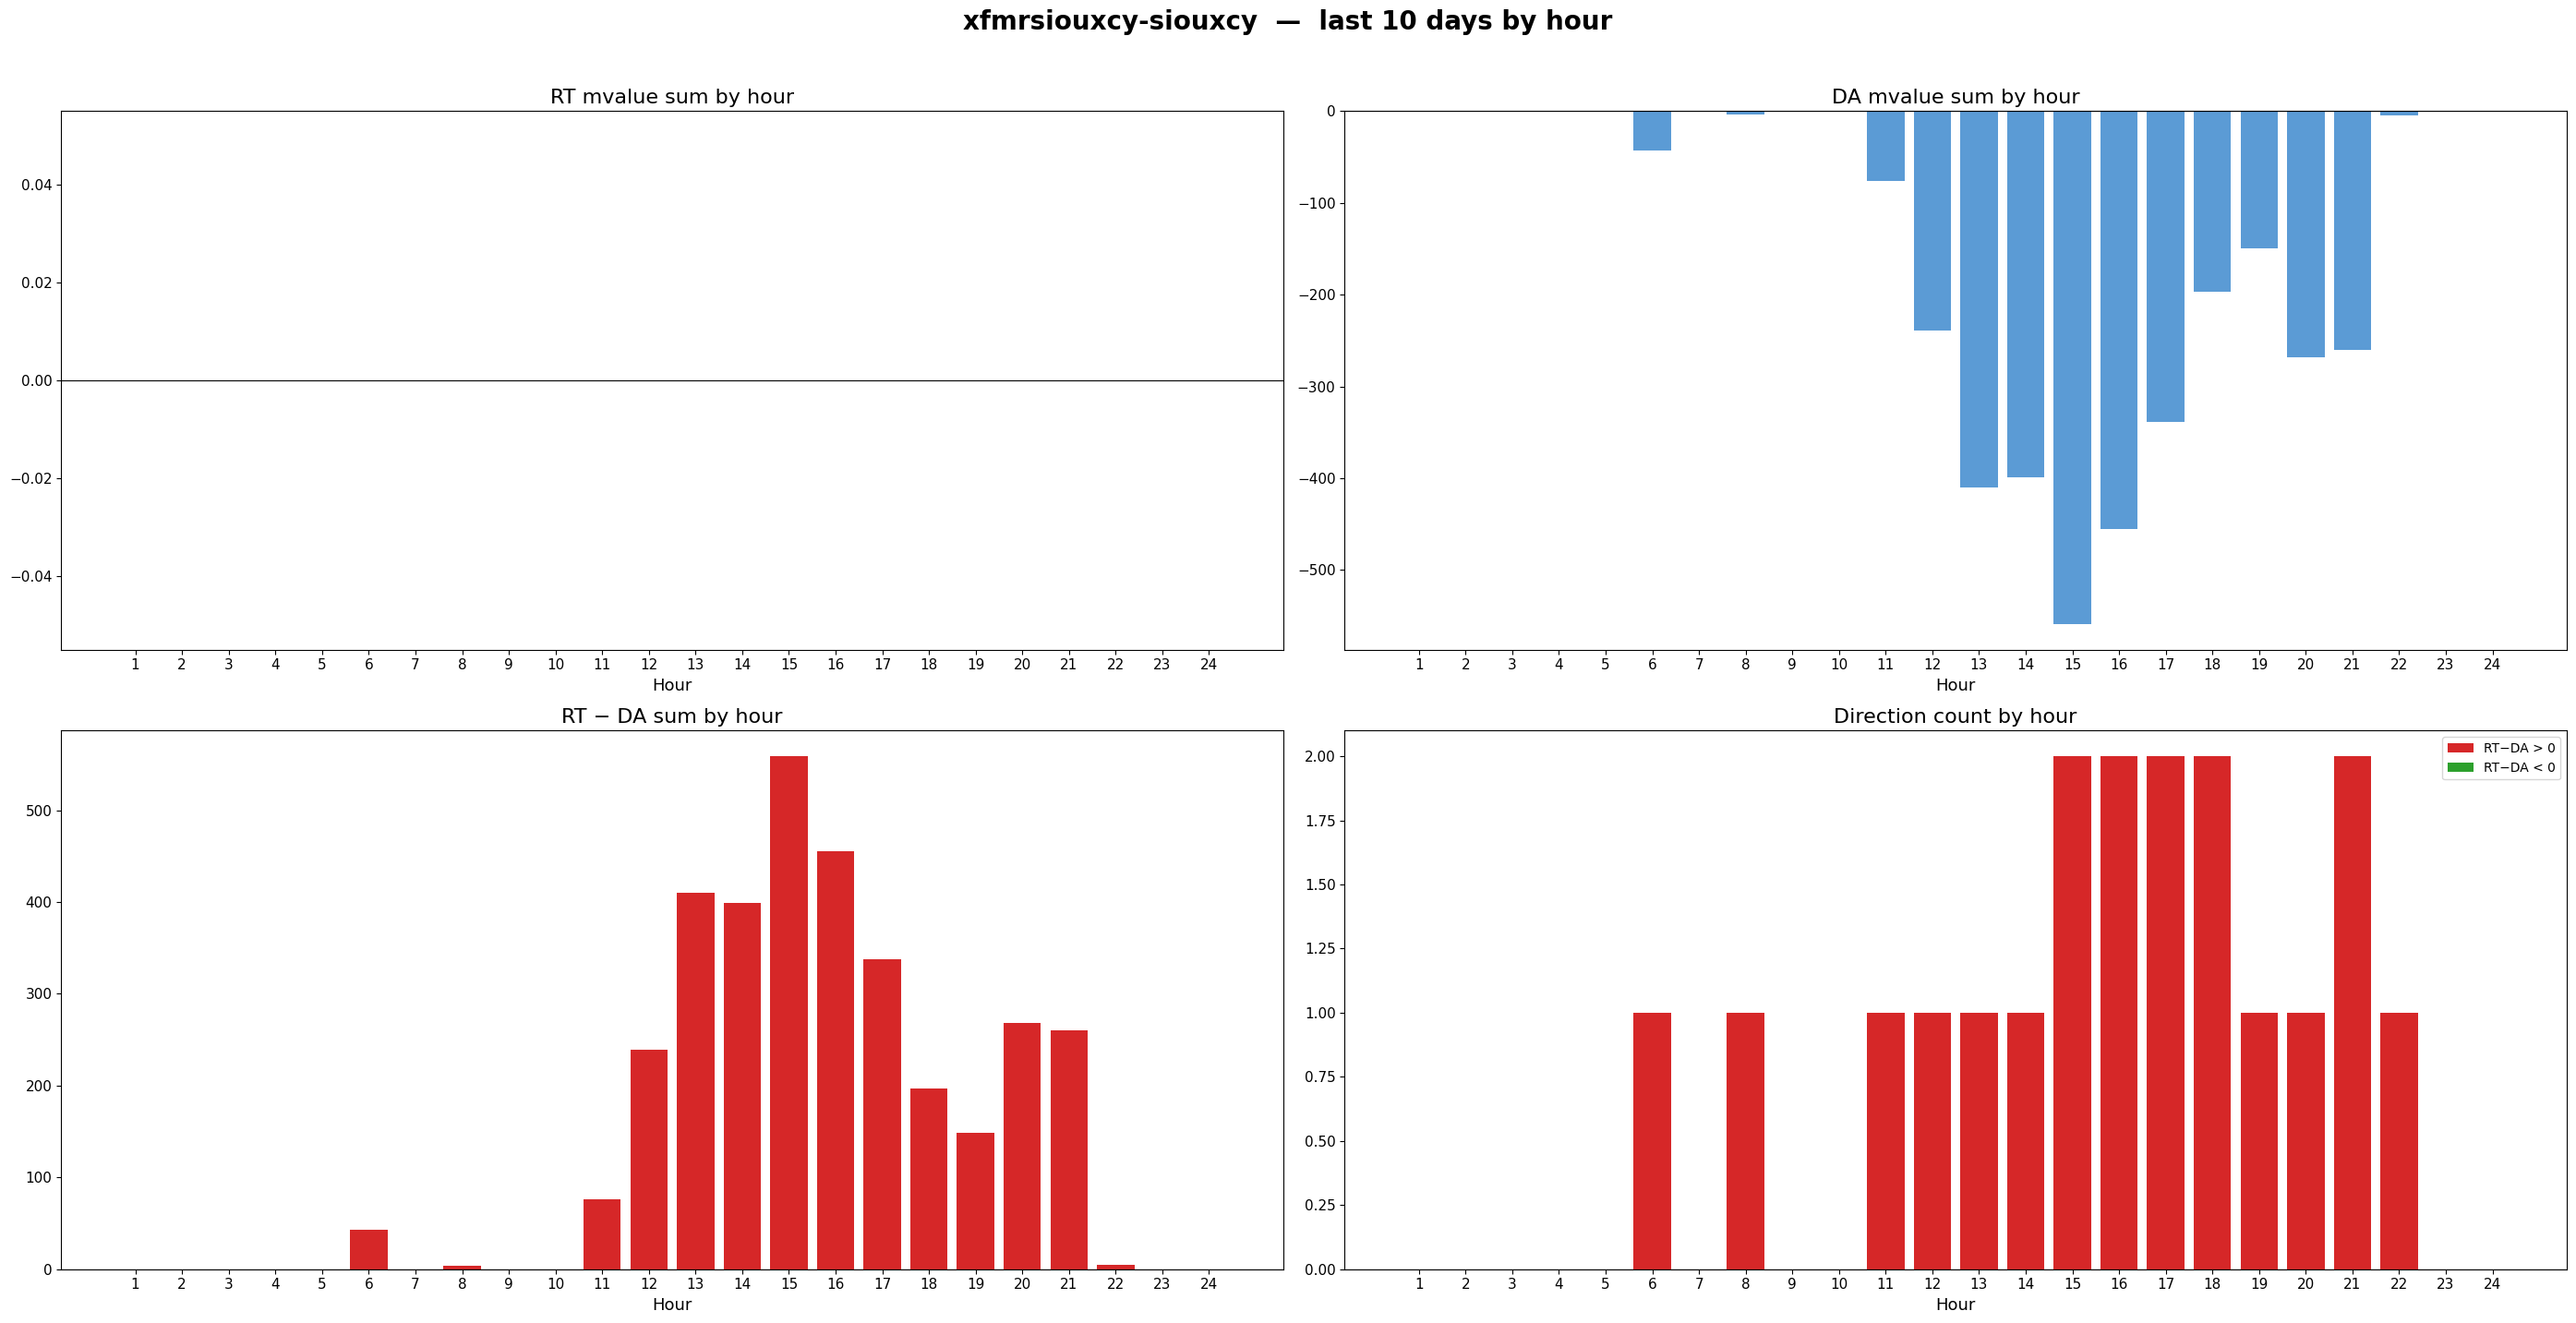


Total rows: 13838

  xfmrsiouxcy-siouxcy


,node_num,dfax,corr,sign_acc,mean_pred,mean_actual,n
0,1176,0.1347,0.368542,0.758105,-31.054303,-16.785625,401.0
1,857,0.1012,0.347506,0.740648,-23.331073,-12.621964,401.0
2,934,0.1112,0.347355,0.745636,-25.636515,-13.740970,401.0
3,935,0.0920,0.337206,0.730673,-21.210066,-10.928531,401.0
4,900,0.0886,0.335211,0.728180,-20.426216,-10.578269,401.0
5,873,0.0842,0.334324,0.728180,-19.411821,-10.502665,401.0
6,938,0.1152,0.332957,0.743142,-26.558692,-13.011683,401.0
7,904,0.1137,0.331706,0.743142,-26.212875,-12.743707,401.0
8,1233,0.1137,0.331706,0.743142,-26.212875,-12.743707,401.0
9,930,0.0871,0.331640,0.728180,-20.080400,-10.812972,401.0


Constraint  : 'lnfirstcrk-roanrdge'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0258  |  Total hours: 17472


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
1,lnfirstcrk-roanrdge,4,rz4_spp_res_zonal_load_forecast_f,0.0258,0.0847,2.28
0,lnfirstcrk-roanrdge,4,rz4_spp_res_zonal_wind_forecast_f,0.0258,0.0801,2.10


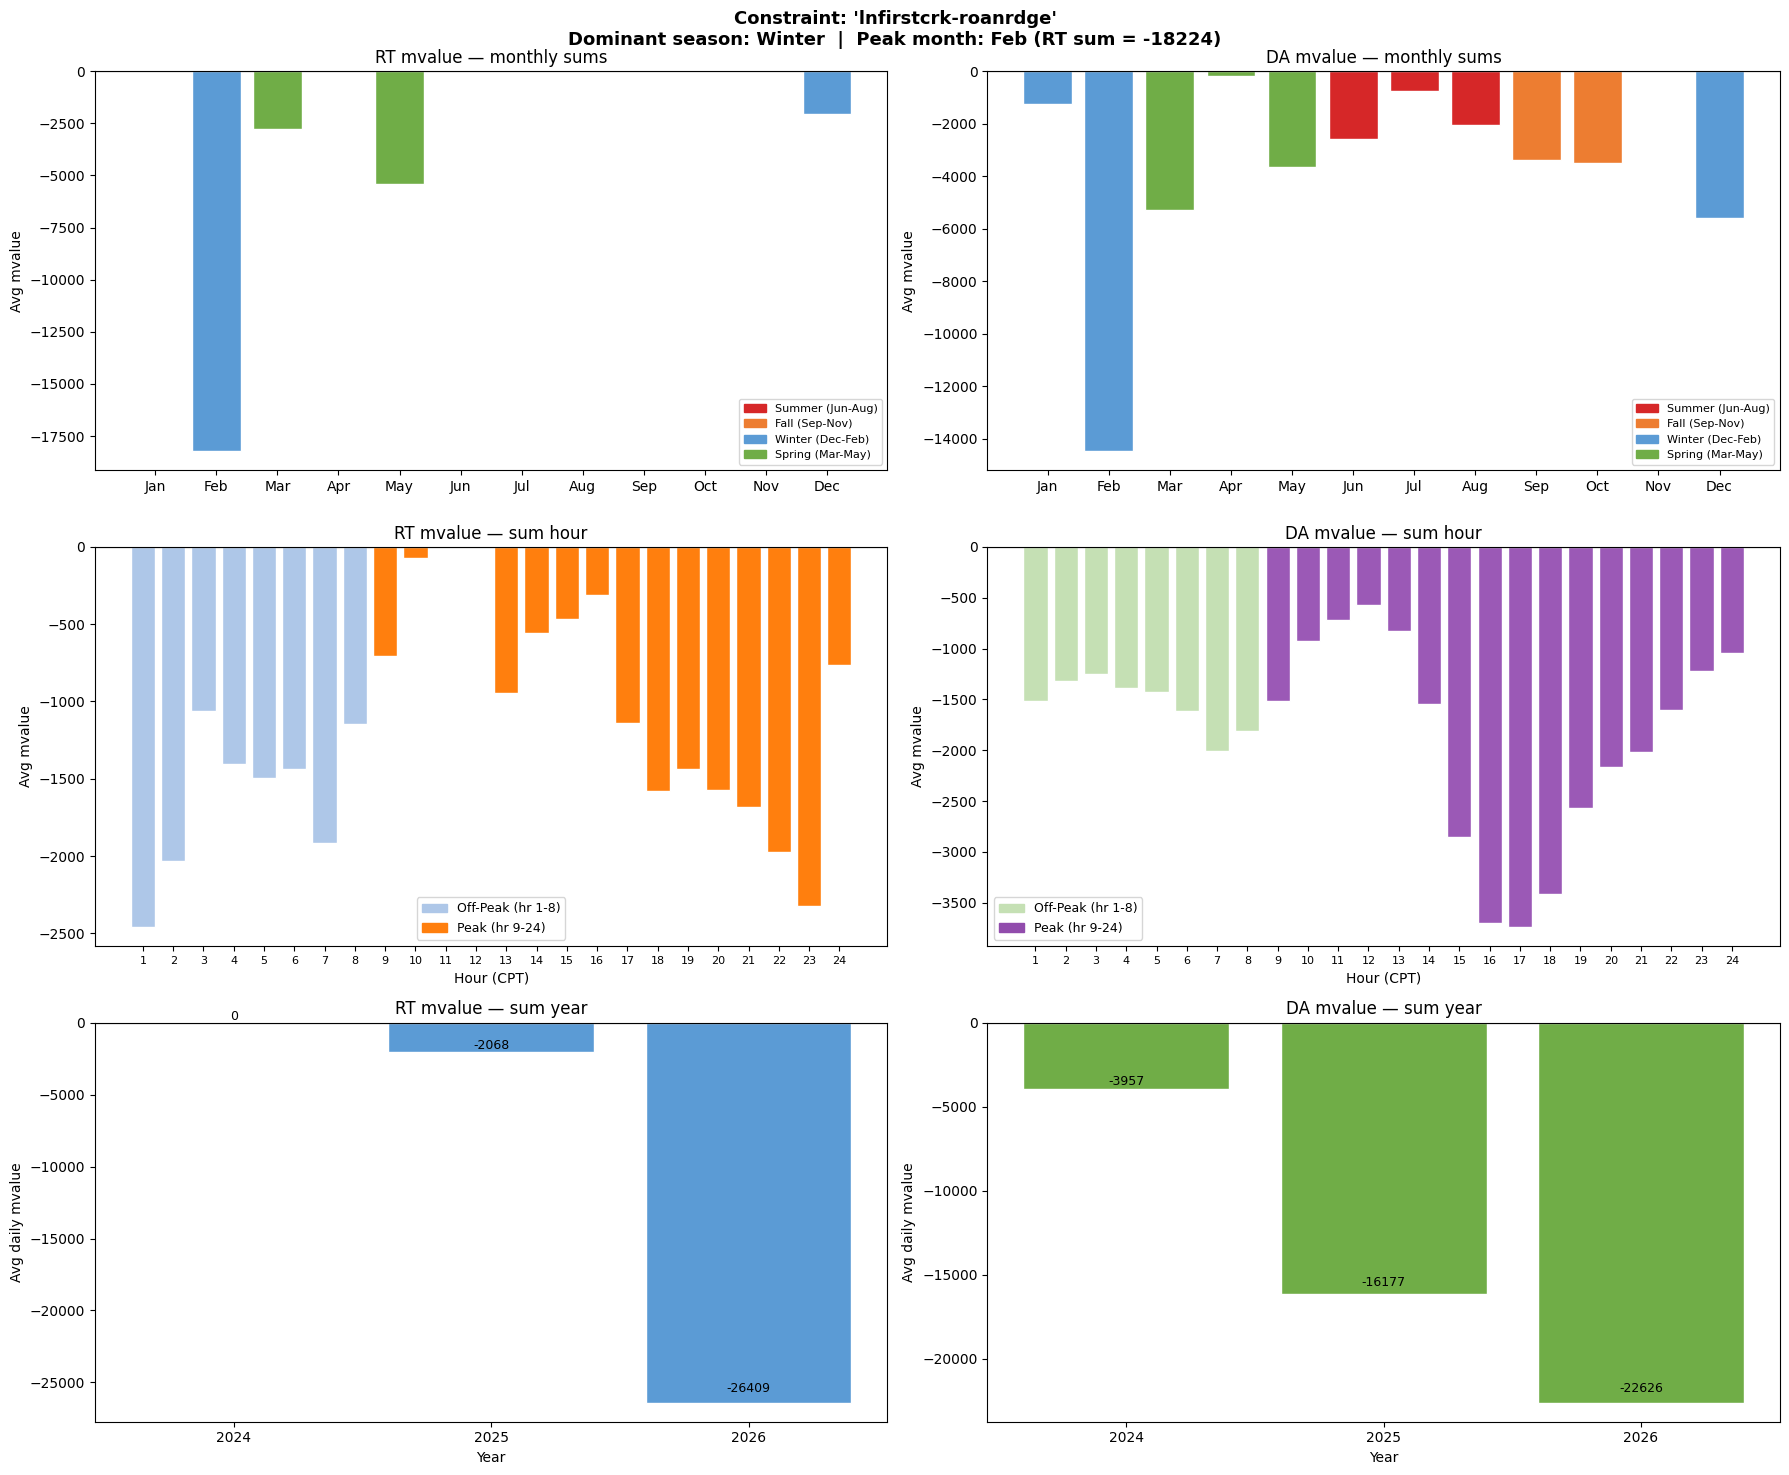

Dominant season : Winter

RT  peak sum   (hr  9-24):  -15526.35  |  off-peak (hr 1-8):  -12950.96
DA  peak sum   (hr  9-24):  -30428.87  |  off-peak (hr 1-8):  -12330.67
'lnfirstcrk-roanrdge'  |  2026-05-19 → 2026-05-29  |  6 days


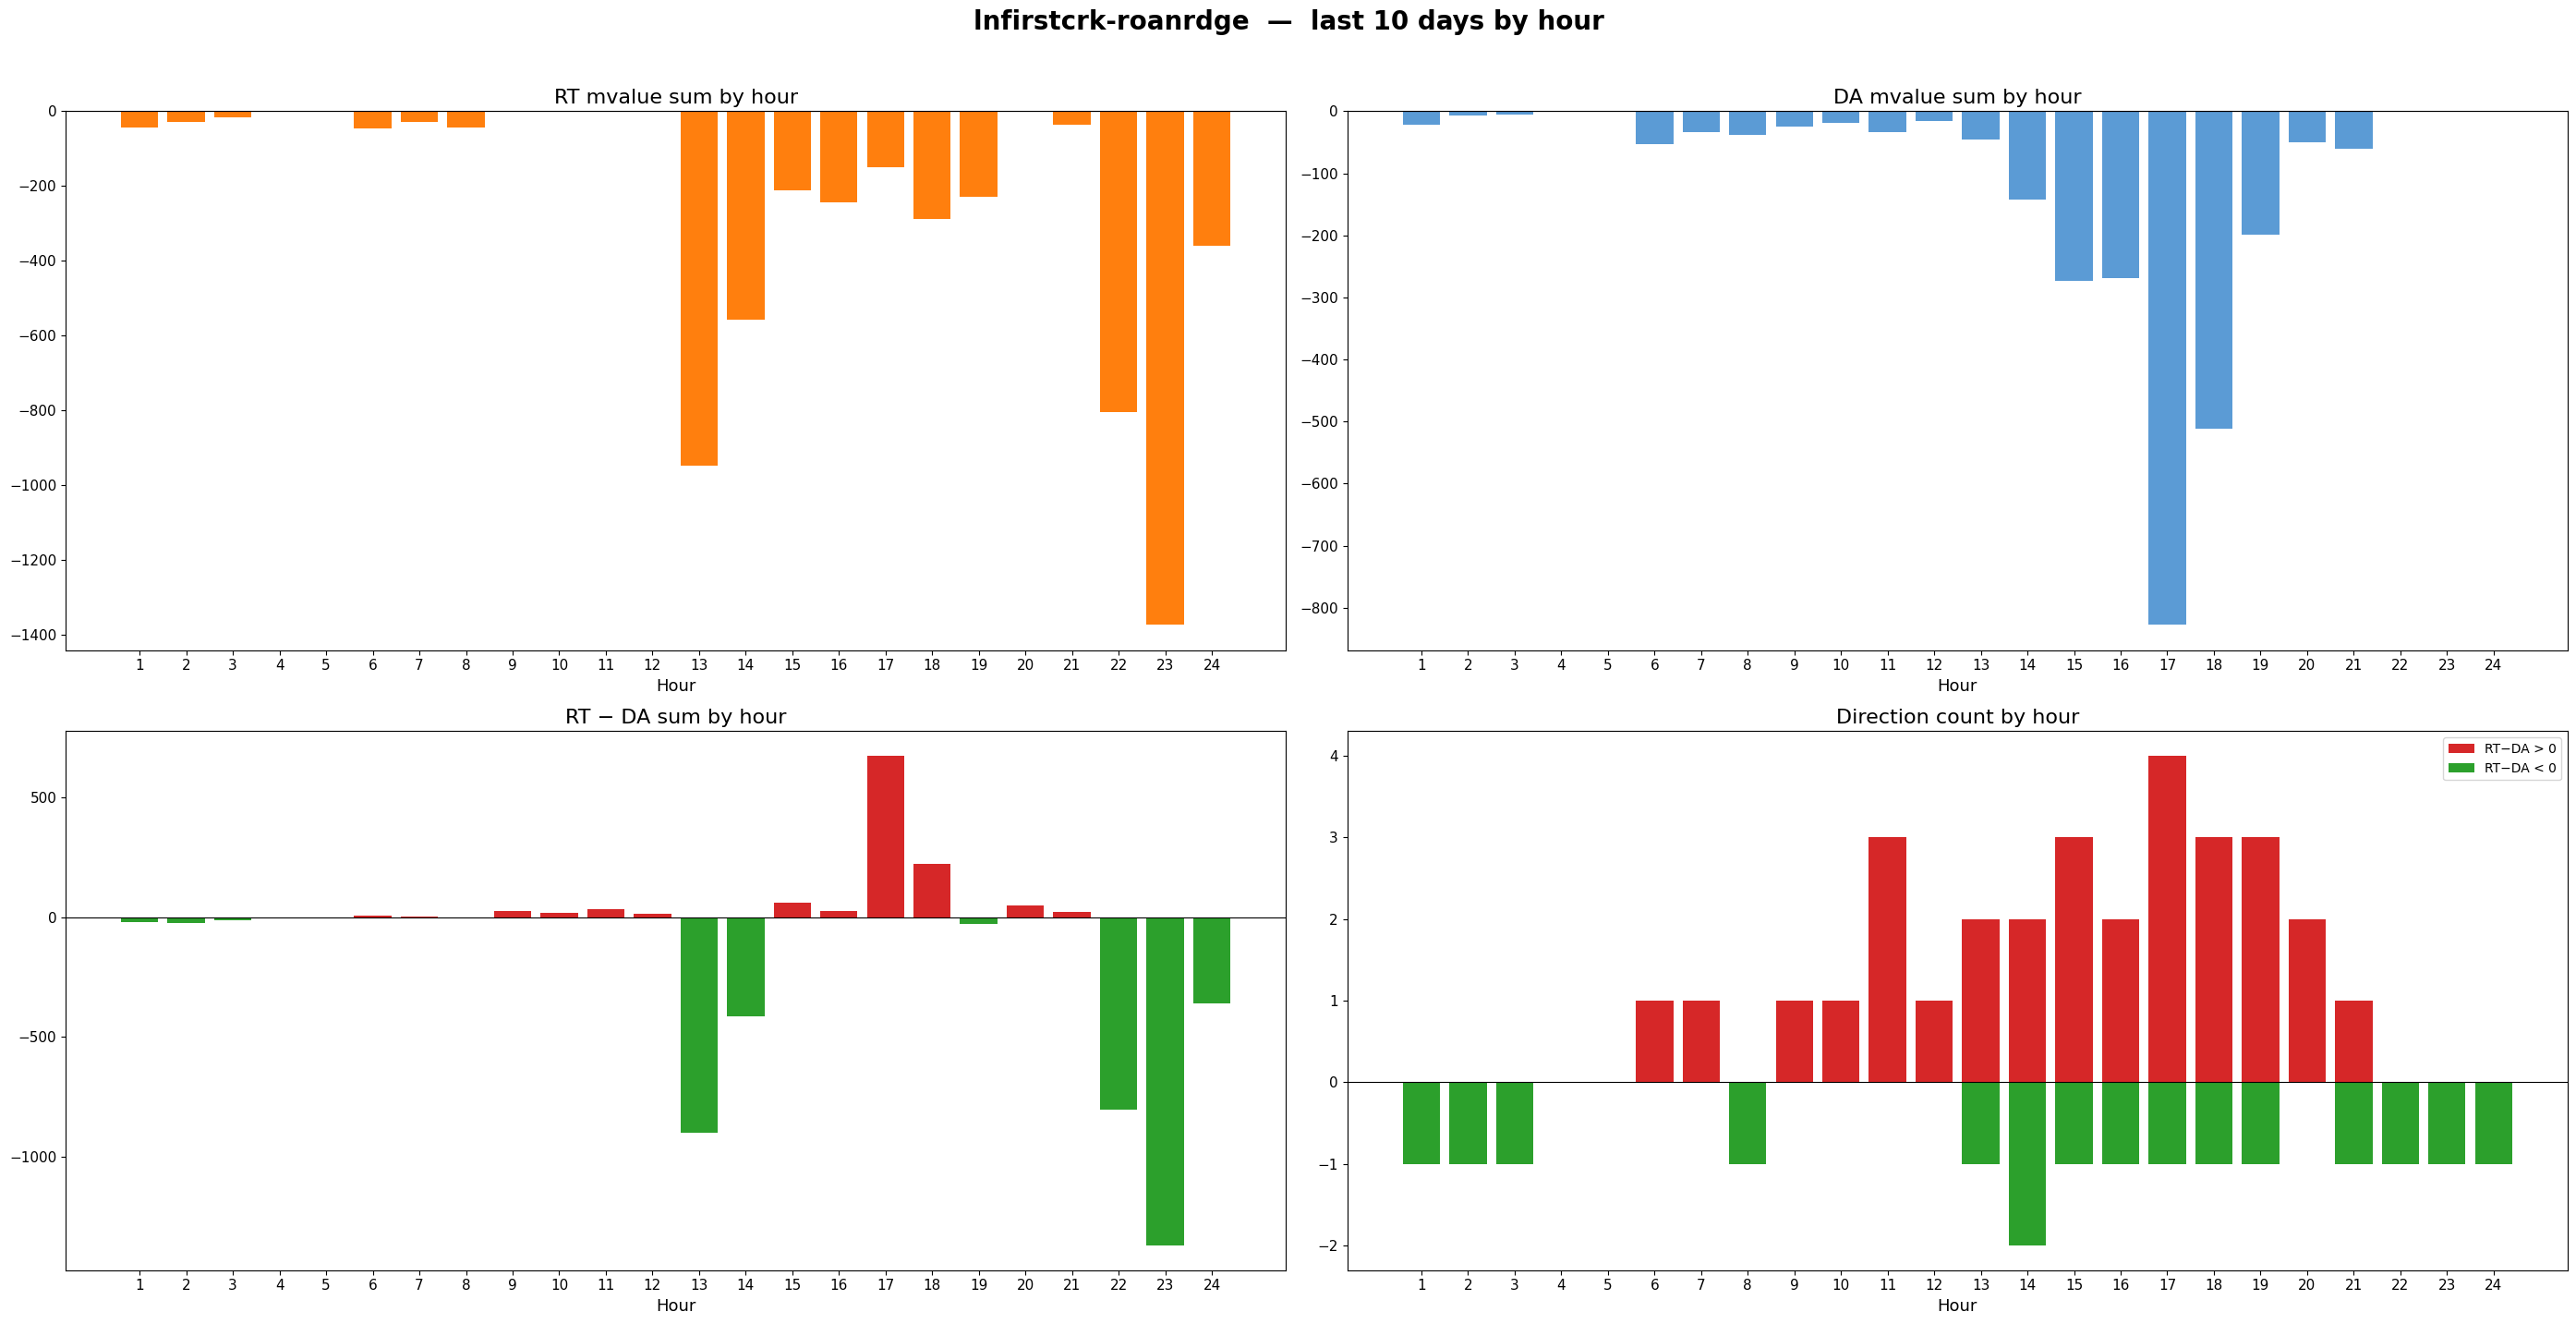

lnfirstcrk-roanrdge could not find the dfax value


Constraint  : 'lndawsonc-lewiswp'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0422  |  Total hours: 17472


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
0,lndawsonc-lewiswp,4,rz4_spp_res_zonal_wind_forecast_f,0.0422,0.0732,0.74
1,lndawsonc-lewiswp,4,rz4_spp_res_zonal_load_forecast_f,0.0422,0.0057,-0.86


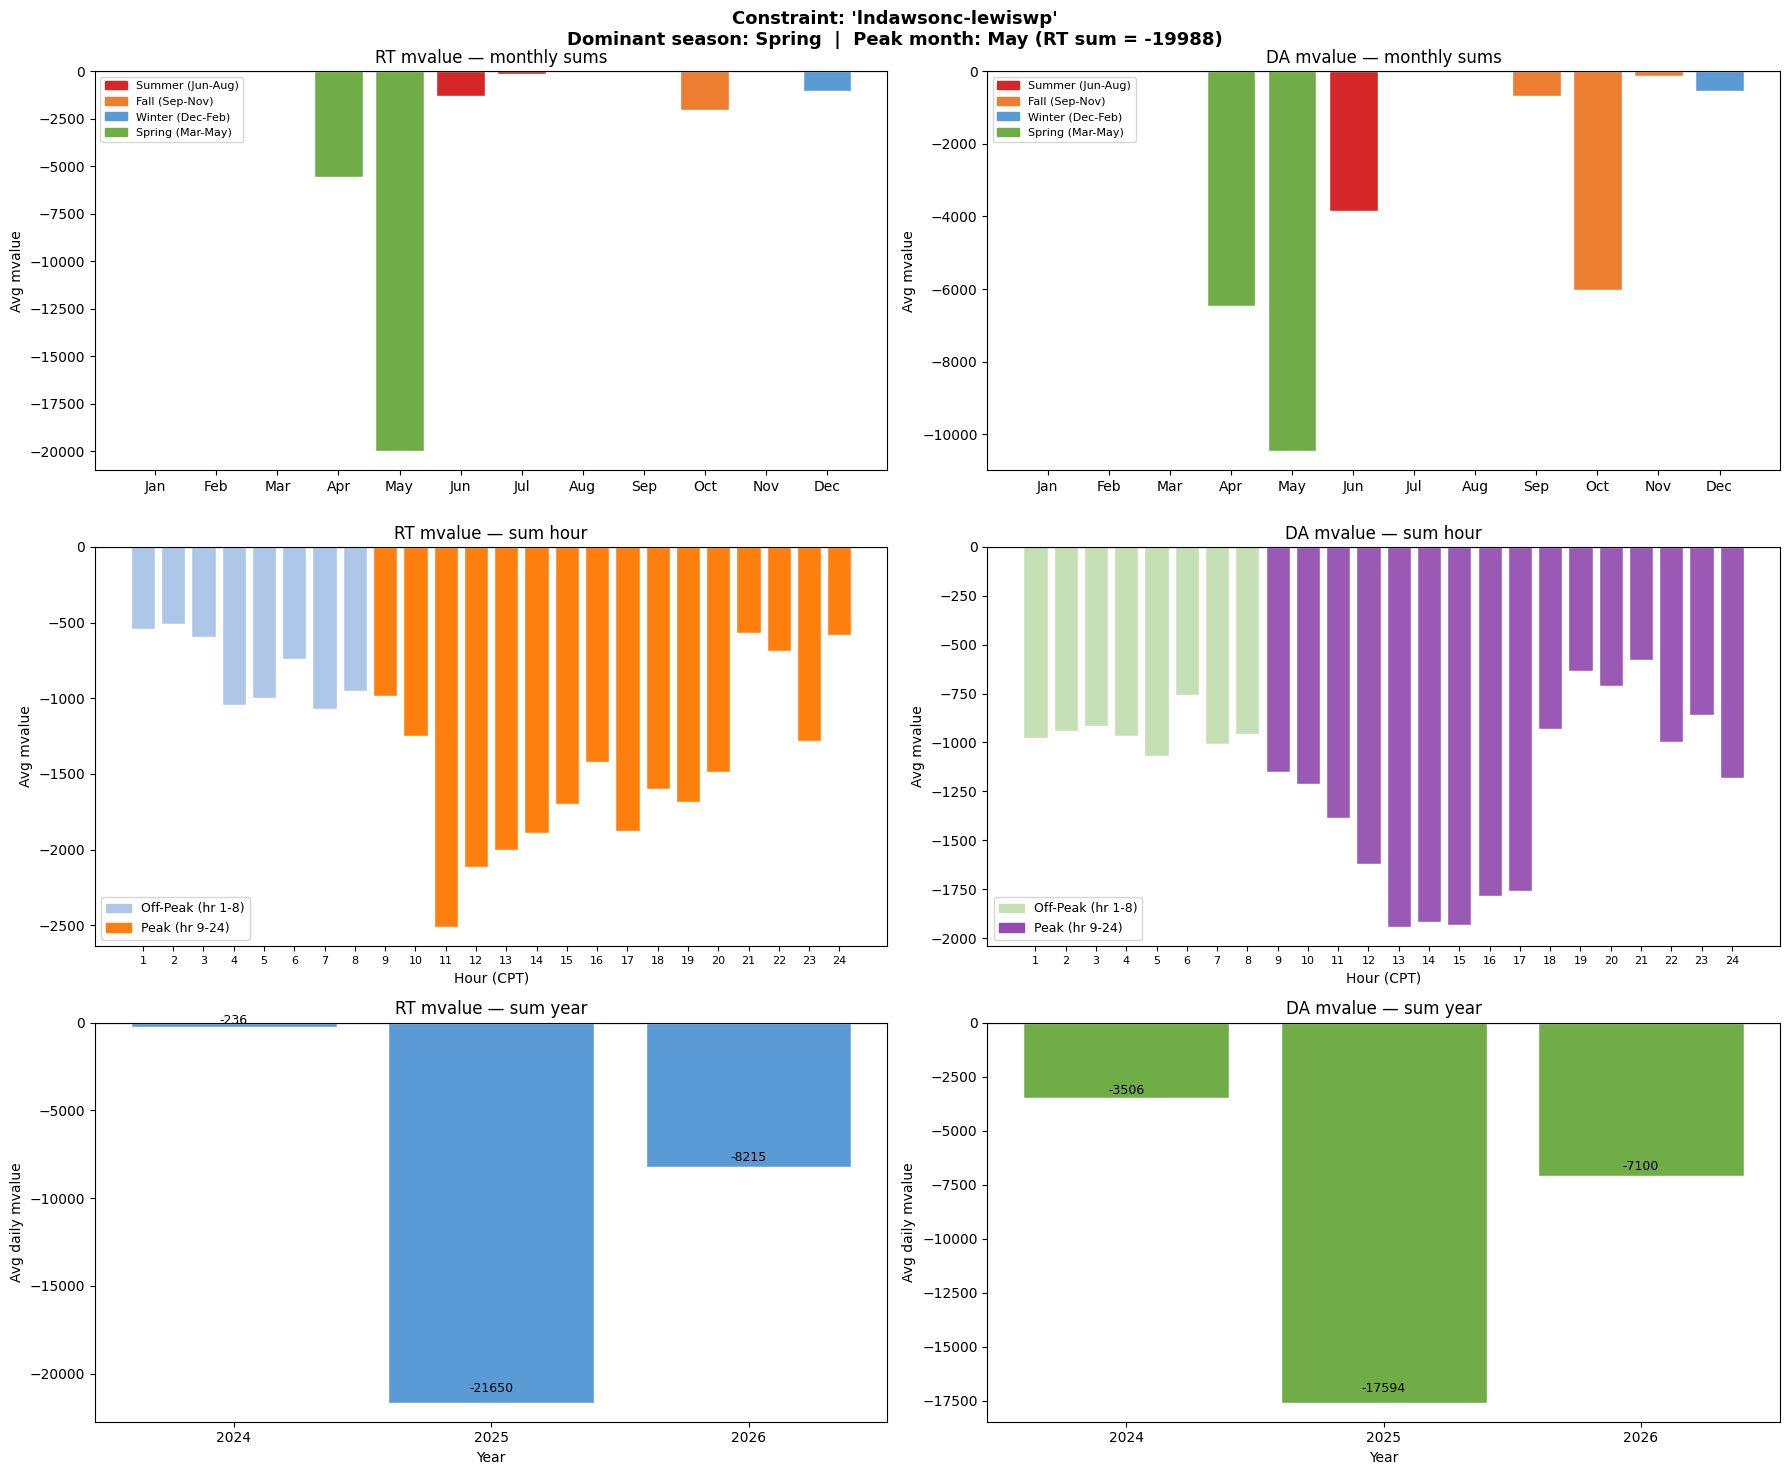

Dominant season : Spring

RT  peak sum   (hr  9-24):  -23641.37  |  off-peak (hr 1-8):   -6459.36
DA  peak sum   (hr  9-24):  -20605.18  |  off-peak (hr 1-8):   -7594.86
'lndawsonc-lewiswp'  |  2026-05-19 → 2026-05-29  |  10 days


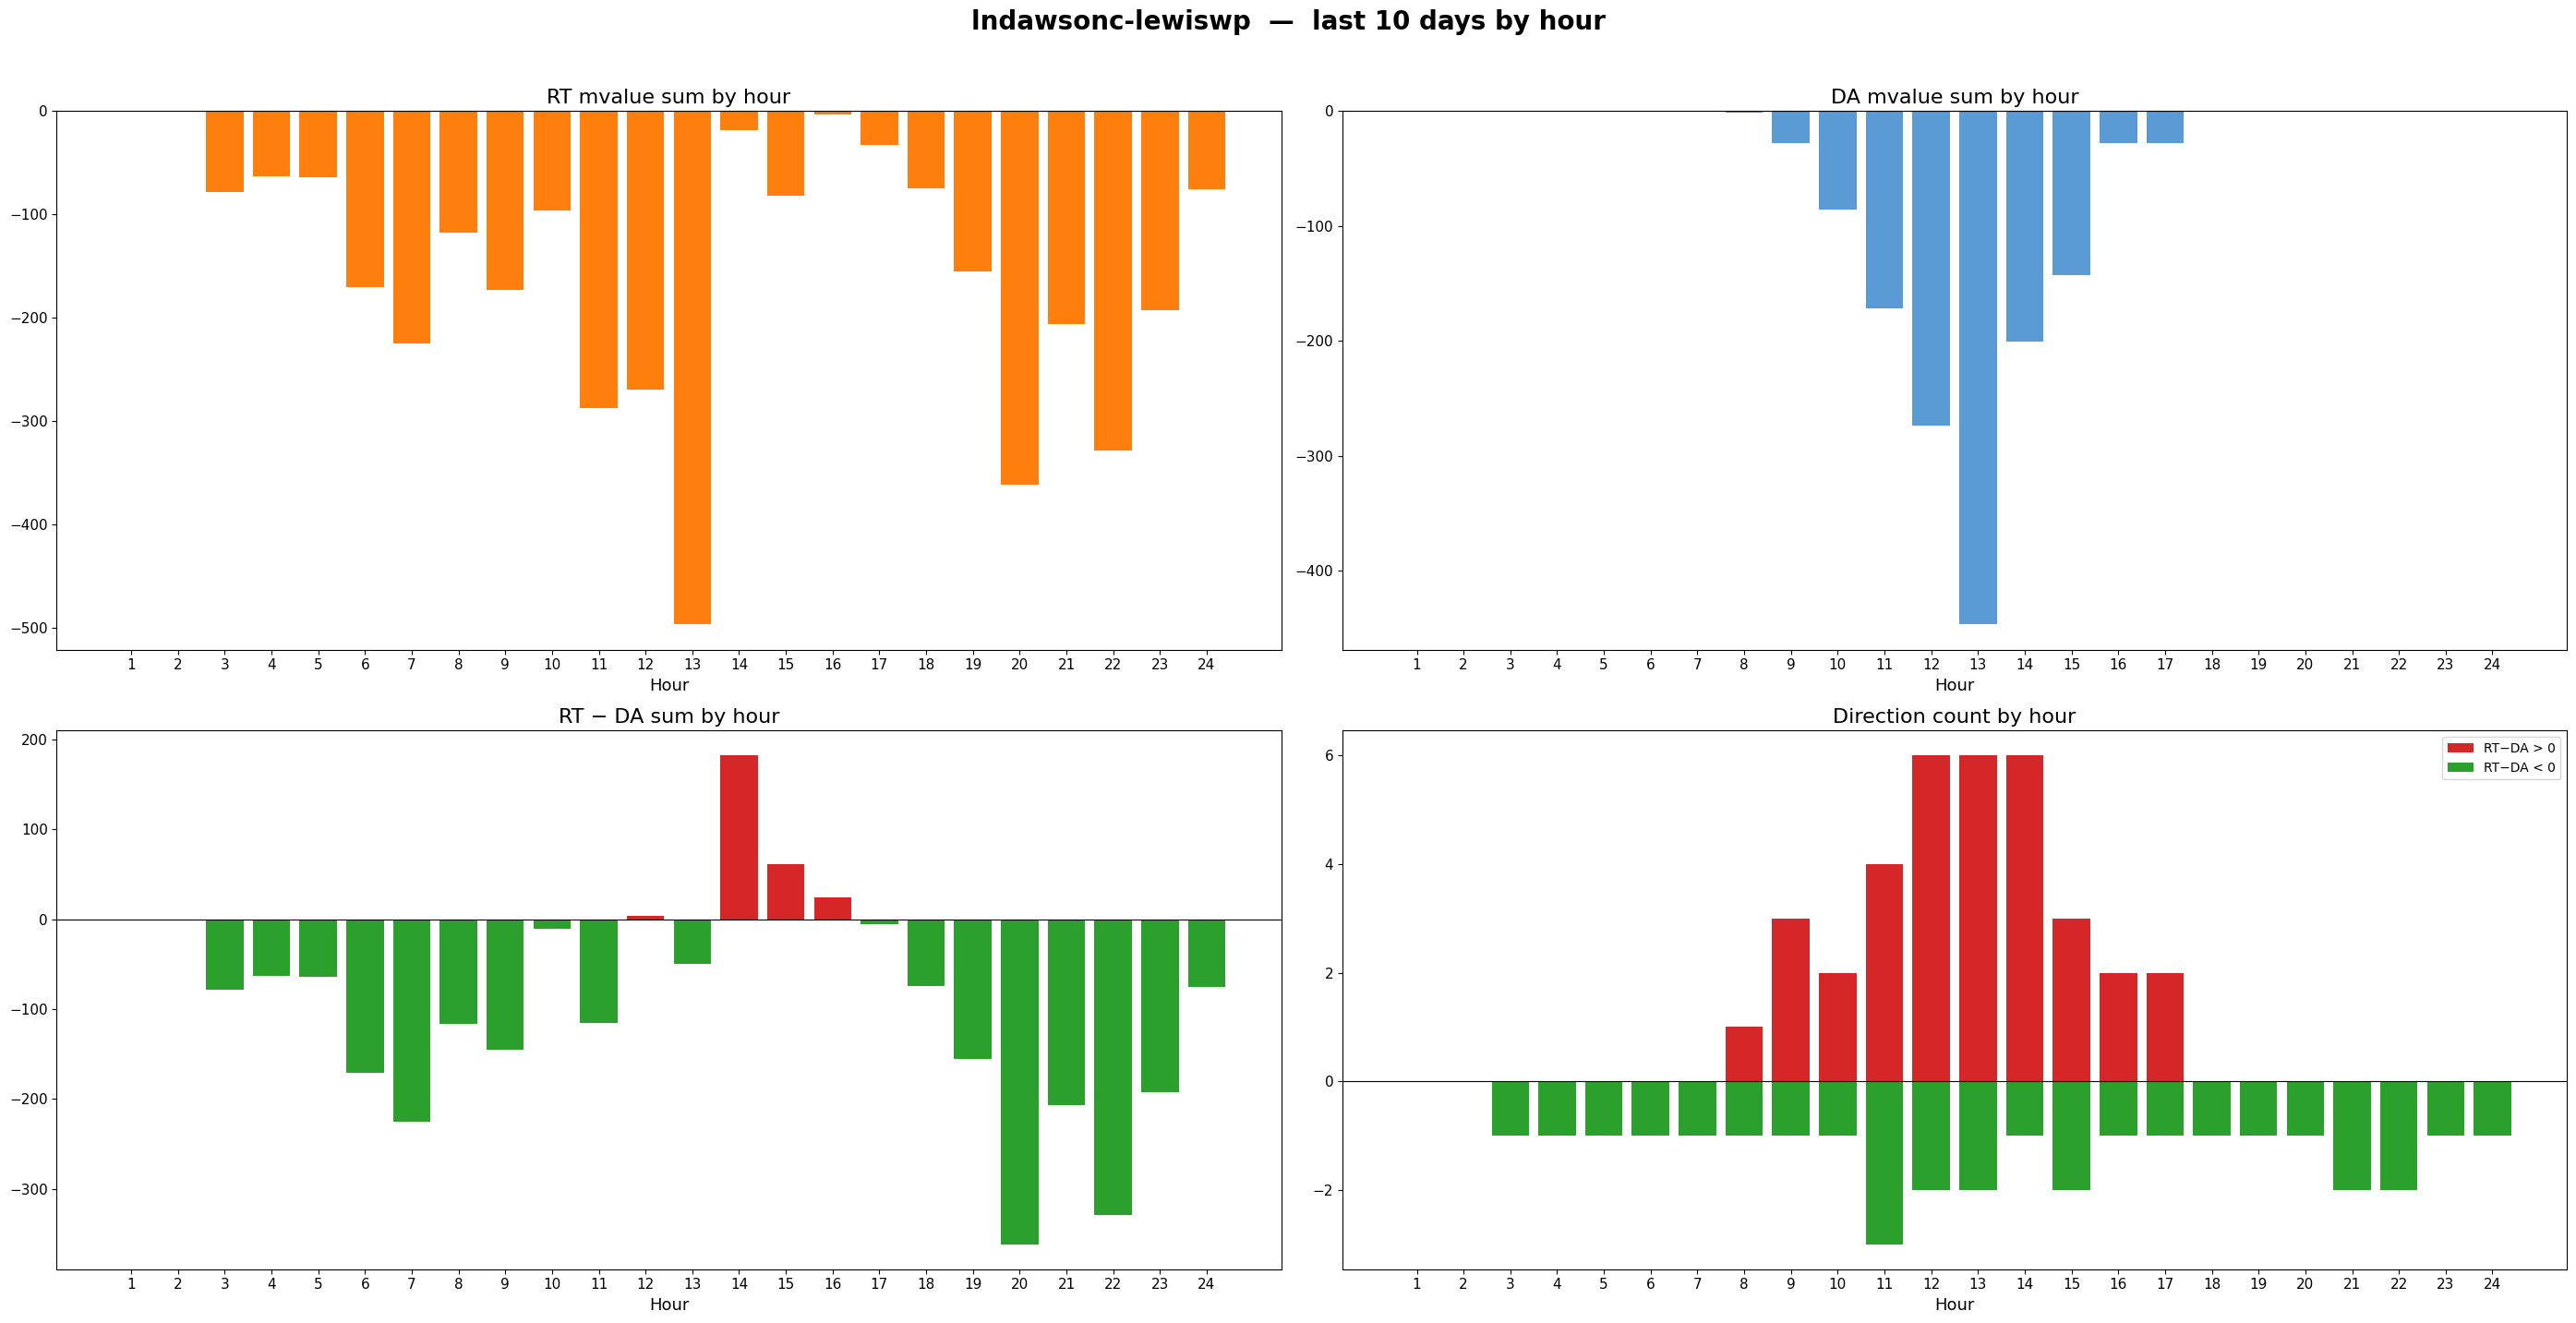


Total rows: 32097

  lndawsonc-lewiswp


,node_num,dfax,corr,sign_acc,mean_pred,mean_actual,n
0,988,0.3121,0.777990,0.845319,0.804891,-1.886706,737.0
1,989,0.3121,0.762948,0.845319,0.804891,-2.284289,737.0
2,1757,0.1677,0.749981,0.804167,0.779118,-1.828338,240.0
3,986,-0.2417,0.618595,0.716418,-0.623332,-2.585600,737.0
4,987,-0.2417,0.618595,0.716418,-0.623332,-2.585600,737.0
5,990,-0.2050,0.549207,0.682497,-0.528685,-2.857619,737.0
6,852,-0.1970,0.530991,0.674355,-0.508053,-2.946914,737.0
7,983,-0.1868,0.506063,0.667571,-0.481748,-2.779745,737.0
8,985,-0.1868,0.506063,0.667571,-0.481748,-2.779745,737.0
9,2075,-0.1970,0.496329,0.566667,-0.915243,-4.503026,240.0


Constraint  : 'lnwardwa-bismark2'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0465  |  Total hours: 17472


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
0,lnwardwa-bismark2,4,rz4_spp_res_zonal_wind_forecast_f,0.0465,0.0904,0.94
1,lnwardwa-bismark2,4,rz4_spp_res_zonal_load_forecast_f,0.0465,0.0000,-1.00


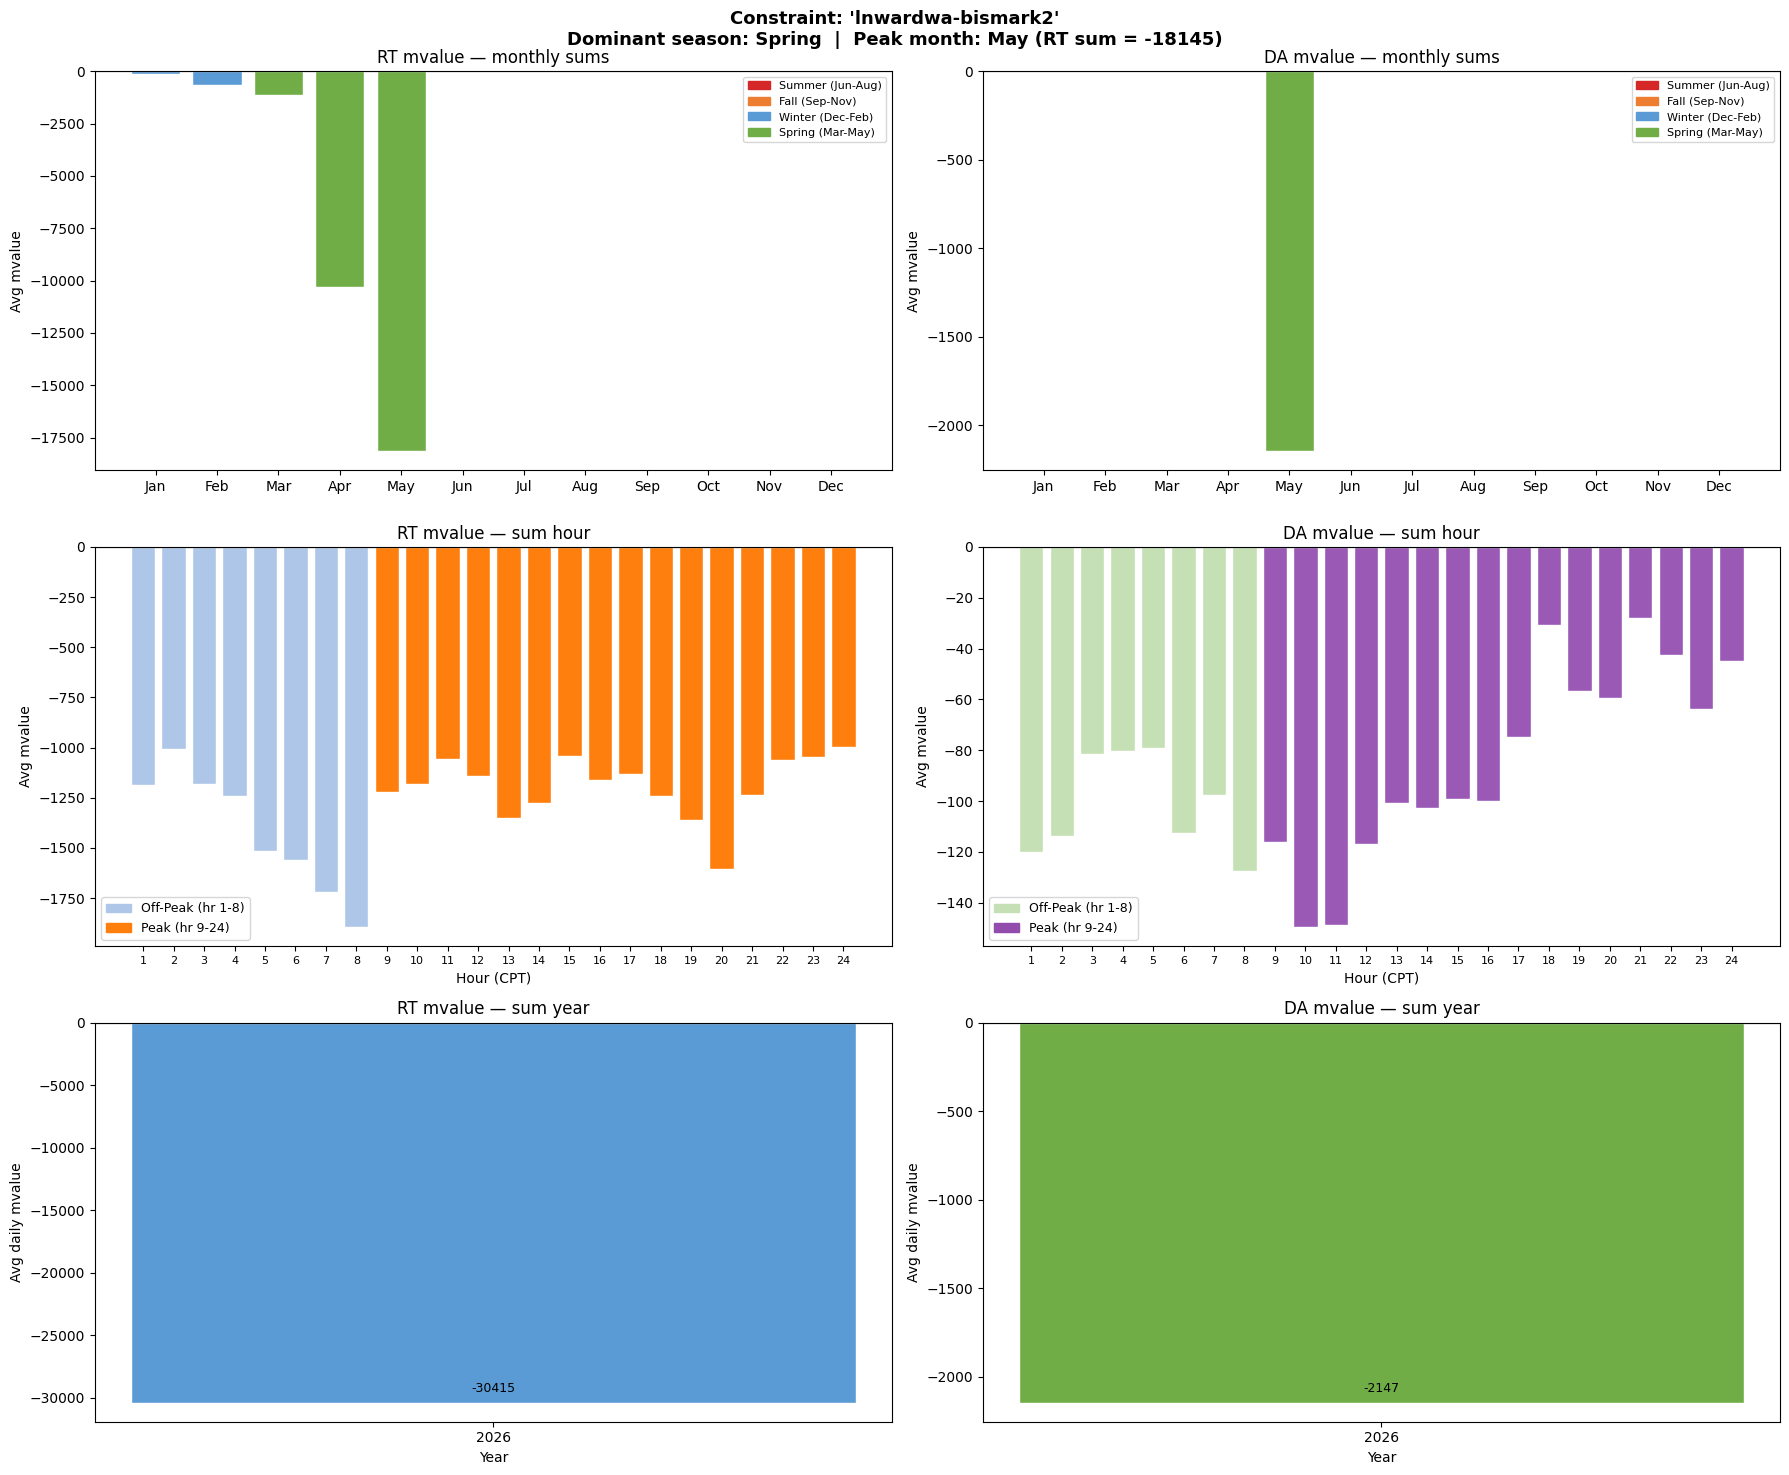

Dominant season : Spring

RT  peak sum   (hr  9-24):  -19106.78  |  off-peak (hr 1-8):  -11308.71
DA  peak sum   (hr  9-24):   -1335.06  |  off-peak (hr 1-8):    -812.29
'lnwardwa-bismark2'  |  2026-05-19 → 2026-05-29  |  8 days


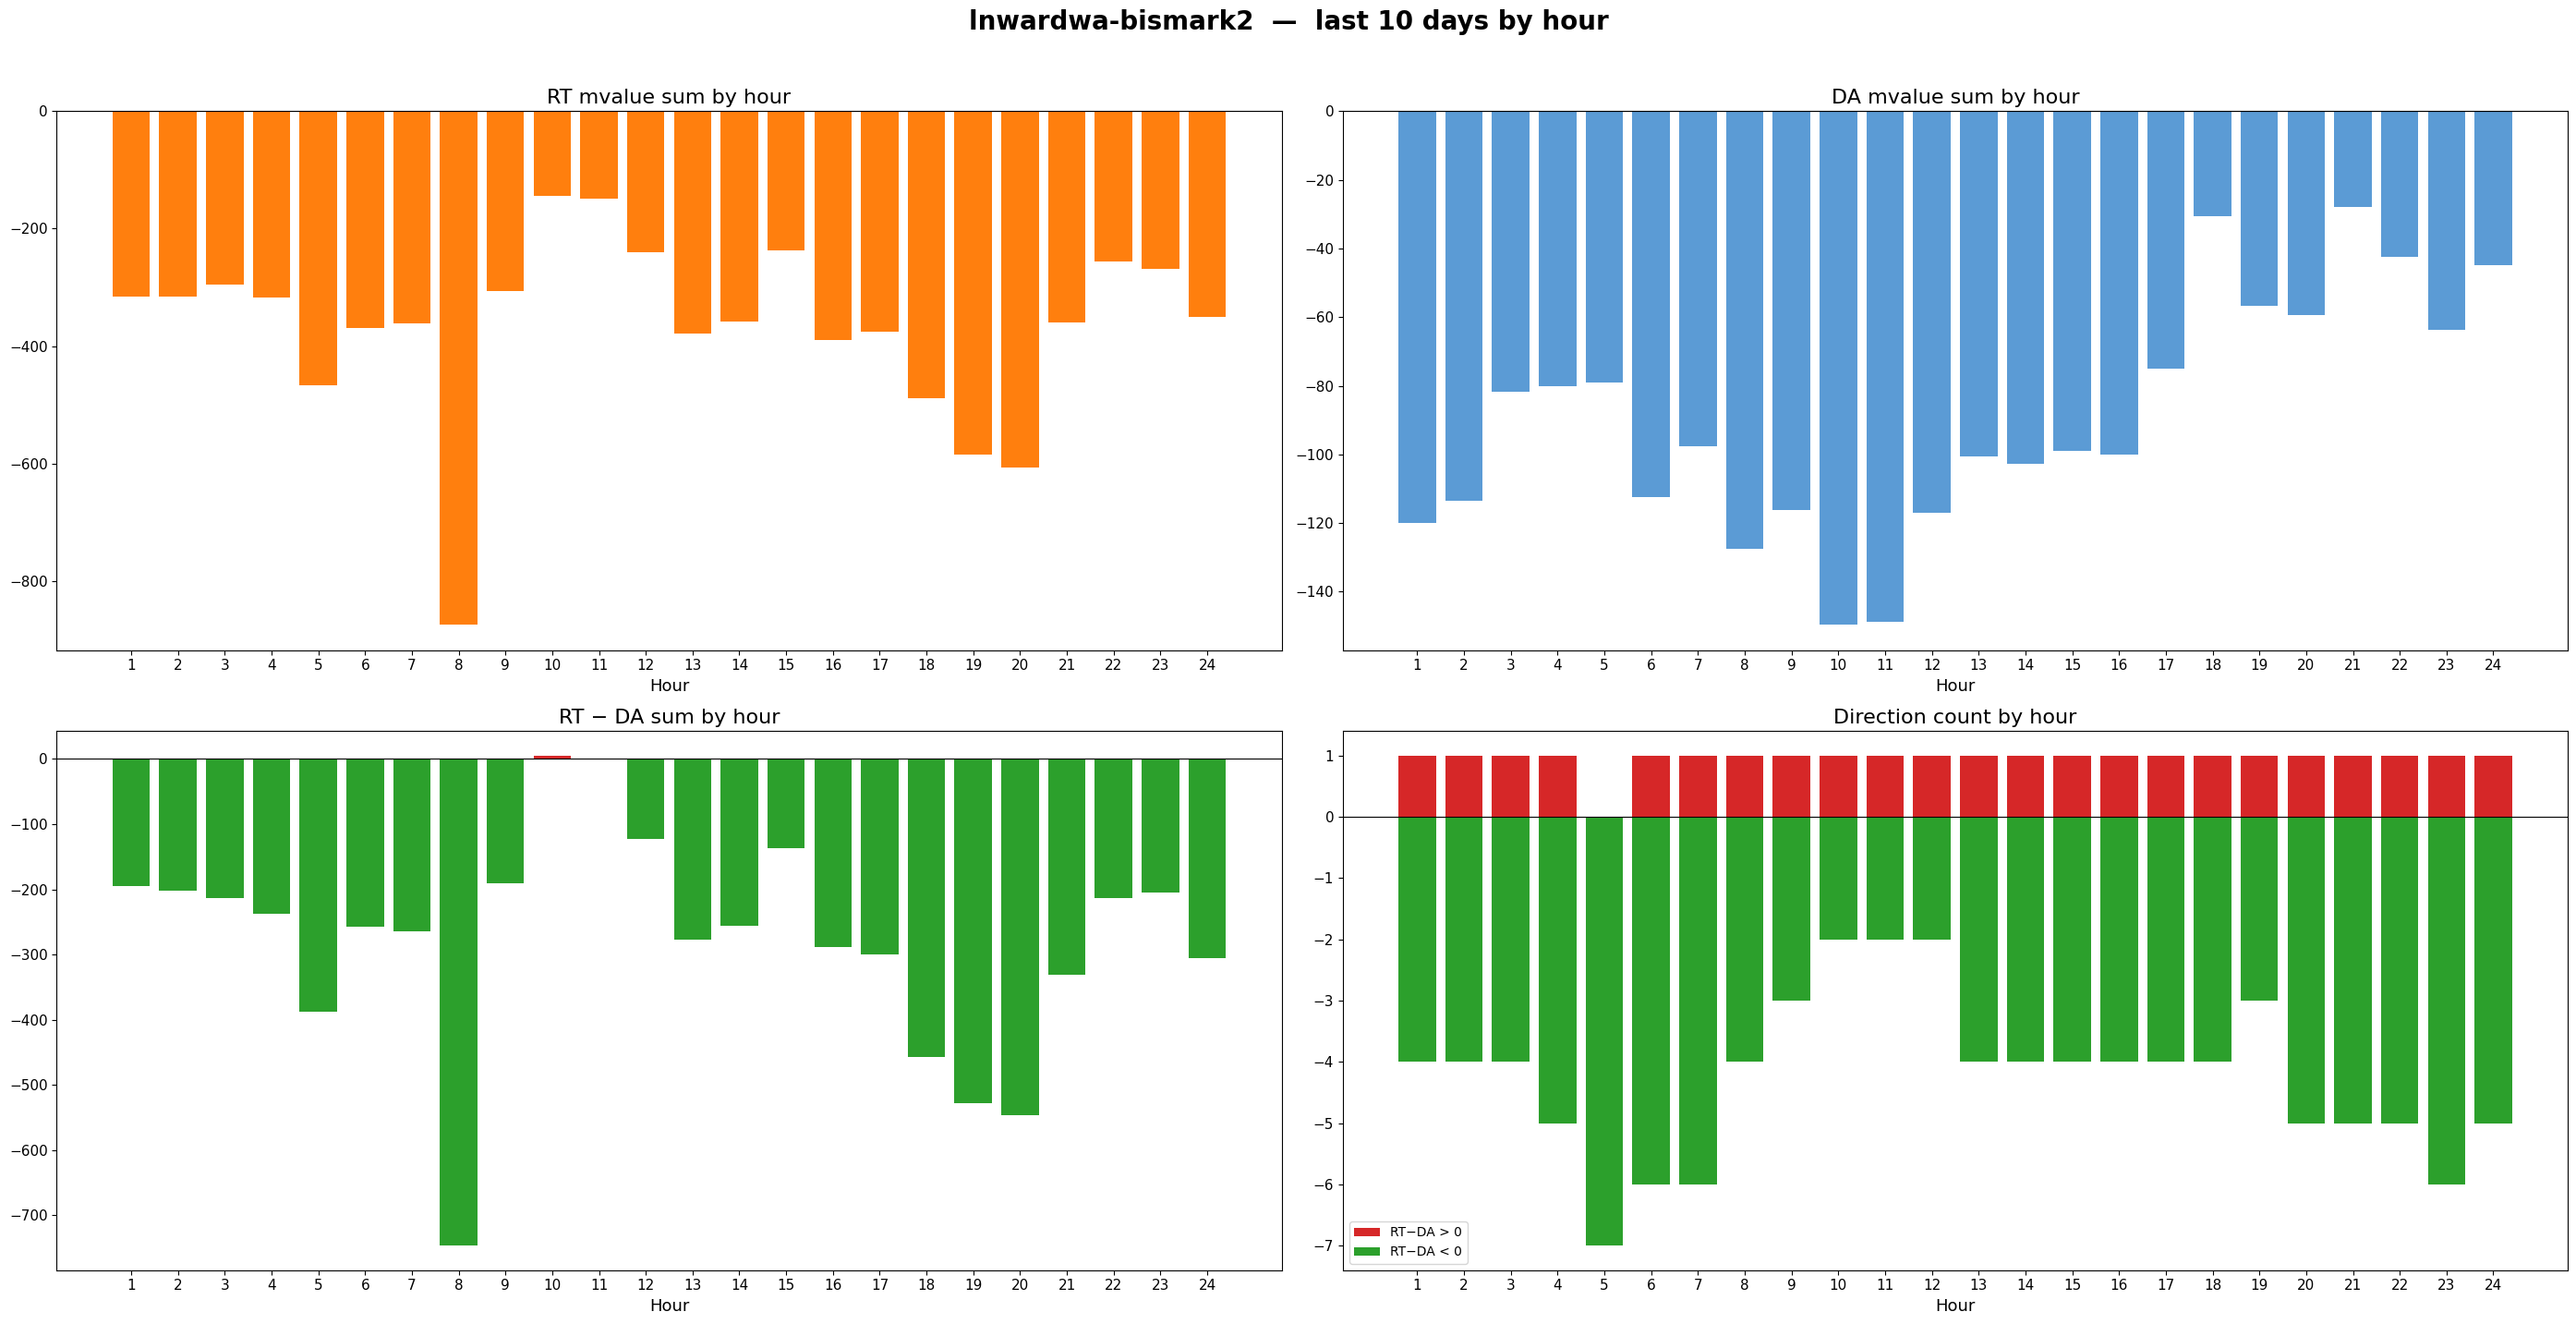


Total rows: 57323

  lnwardwa-bismark2


,node_num,dfax,corr,sign_acc,mean_pred,mean_actual,n
0,915,0.0518,0.648270,0.652174,2.174703,13.137890,69.0
1,1568,0.0508,0.646227,0.623188,2.132721,9.887753,69.0
2,1569,0.0508,0.646227,0.623188,2.132721,9.887753,69.0
3,1669,0.0508,0.646227,0.623188,2.132721,9.887753,69.0
4,948,-0.2316,0.407508,0.753623,-9.723191,0.973013,69.0
...,...,...,...,...,...,...,...
71,979,-0.0793,-0.328329,0.492754,-3.329227,10.522336,69.0
72,1006,-0.0736,-0.344115,0.507246,-3.089926,9.935897,69.0
73,896,-0.0623,-0.372808,0.550725,-2.615522,9.384955,69.0
74,1020,-0.0506,-0.376937,0.623188,-2.124324,8.211045,69.0


Constraint  : 'ln70_bluf-sub1214'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0713  |  Total hours: 17472


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
1,ln70_bluf-sub1214,4,rz4_spp_res_zonal_load_forecast_f,0.0713,0.0858,0.20
0,ln70_bluf-sub1214,4,rz4_spp_res_zonal_wind_forecast_f,0.0713,0.0503,-0.29


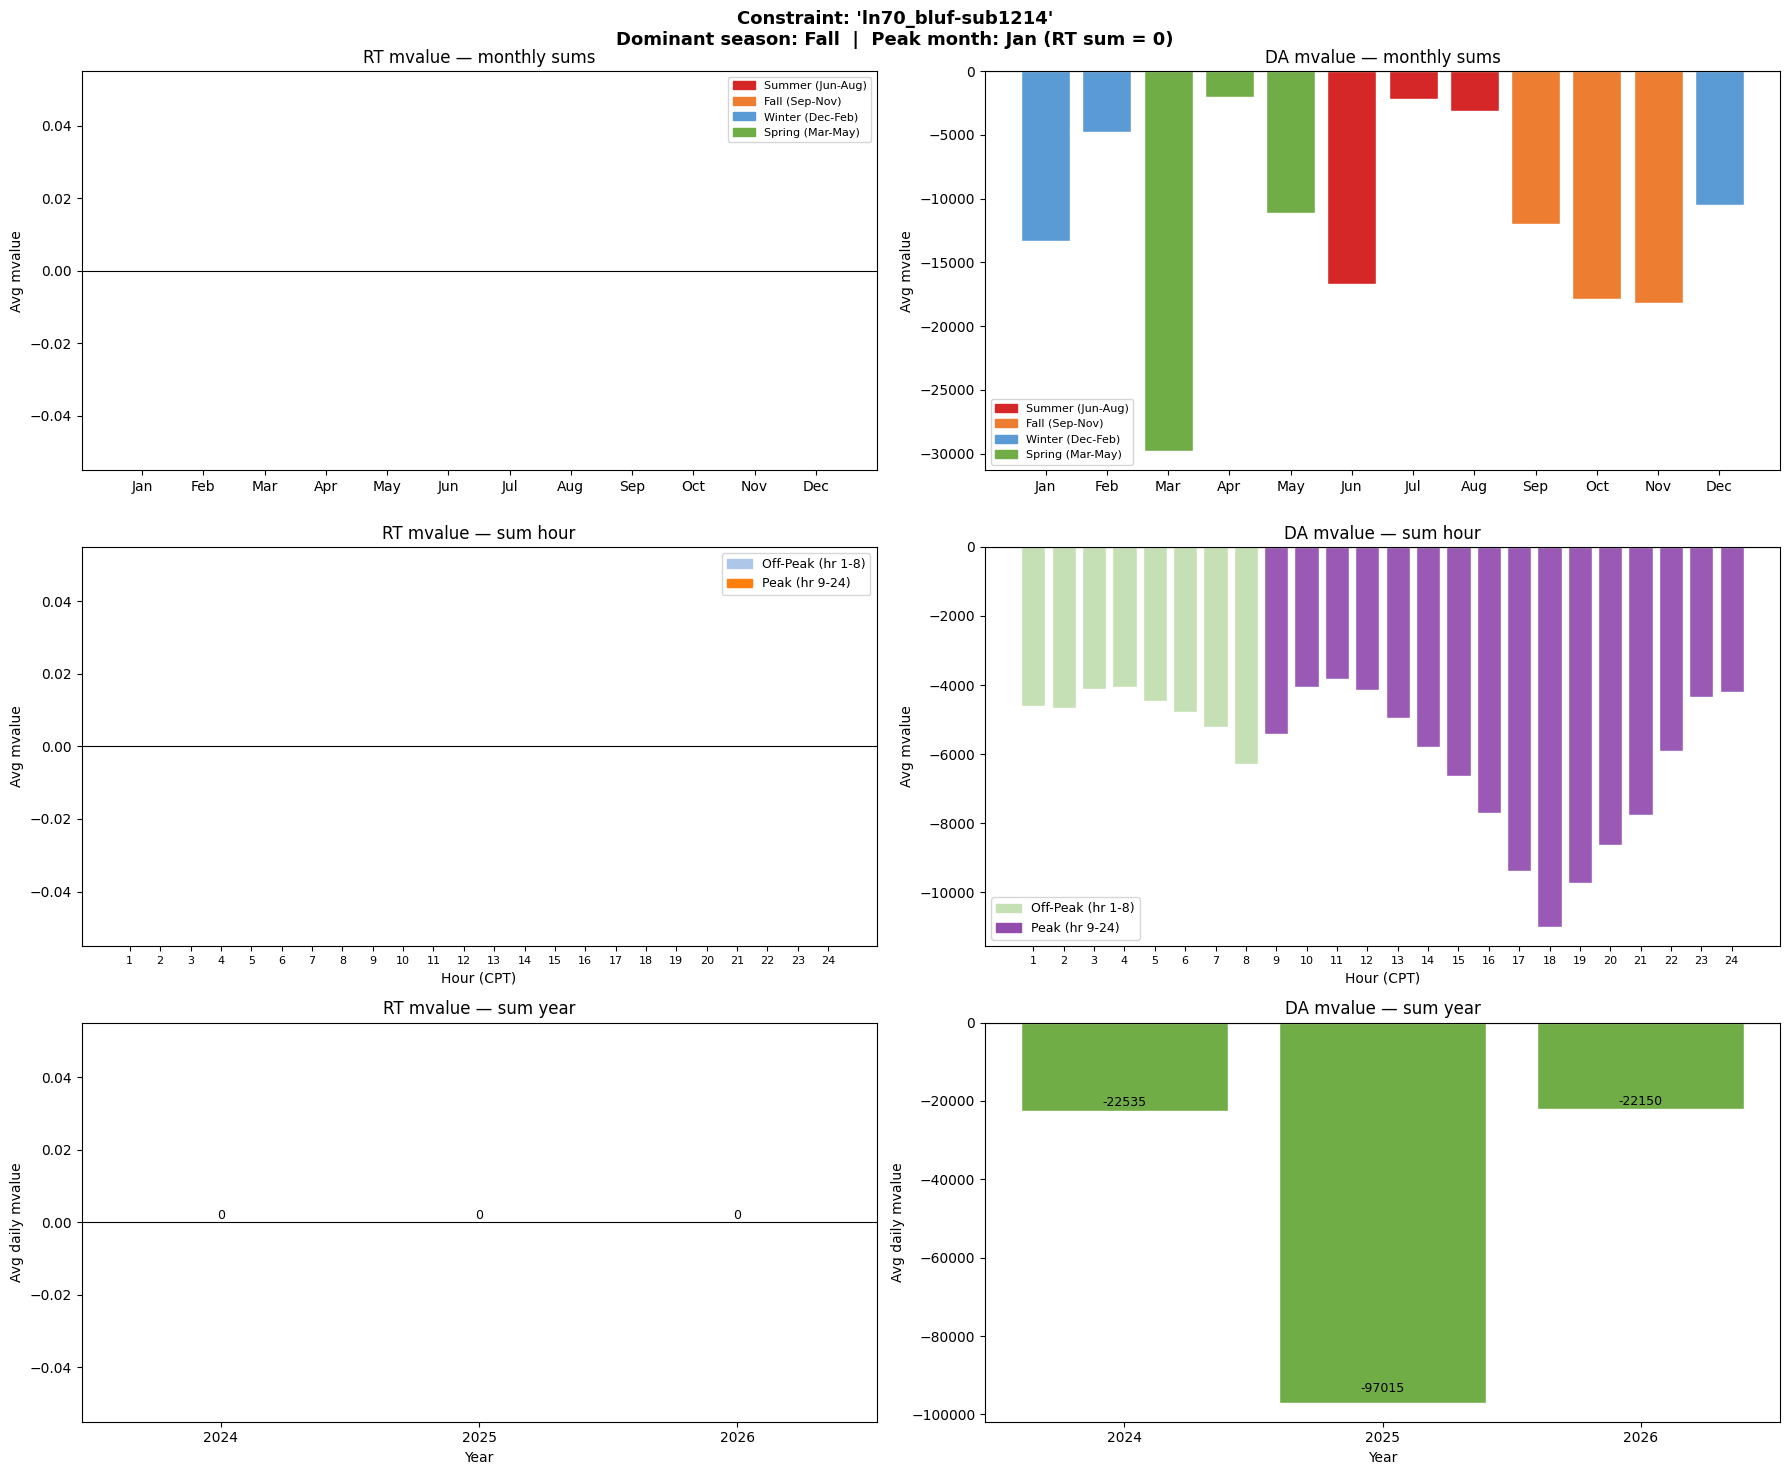

Dominant season : Fall

RT  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):       0.00
DA  peak sum   (hr  9-24): -103506.83  |  off-peak (hr 1-8):  -38193.58
'ln70_bluf-sub1214'  |  2026-05-19 → 2026-05-29  |  7 days


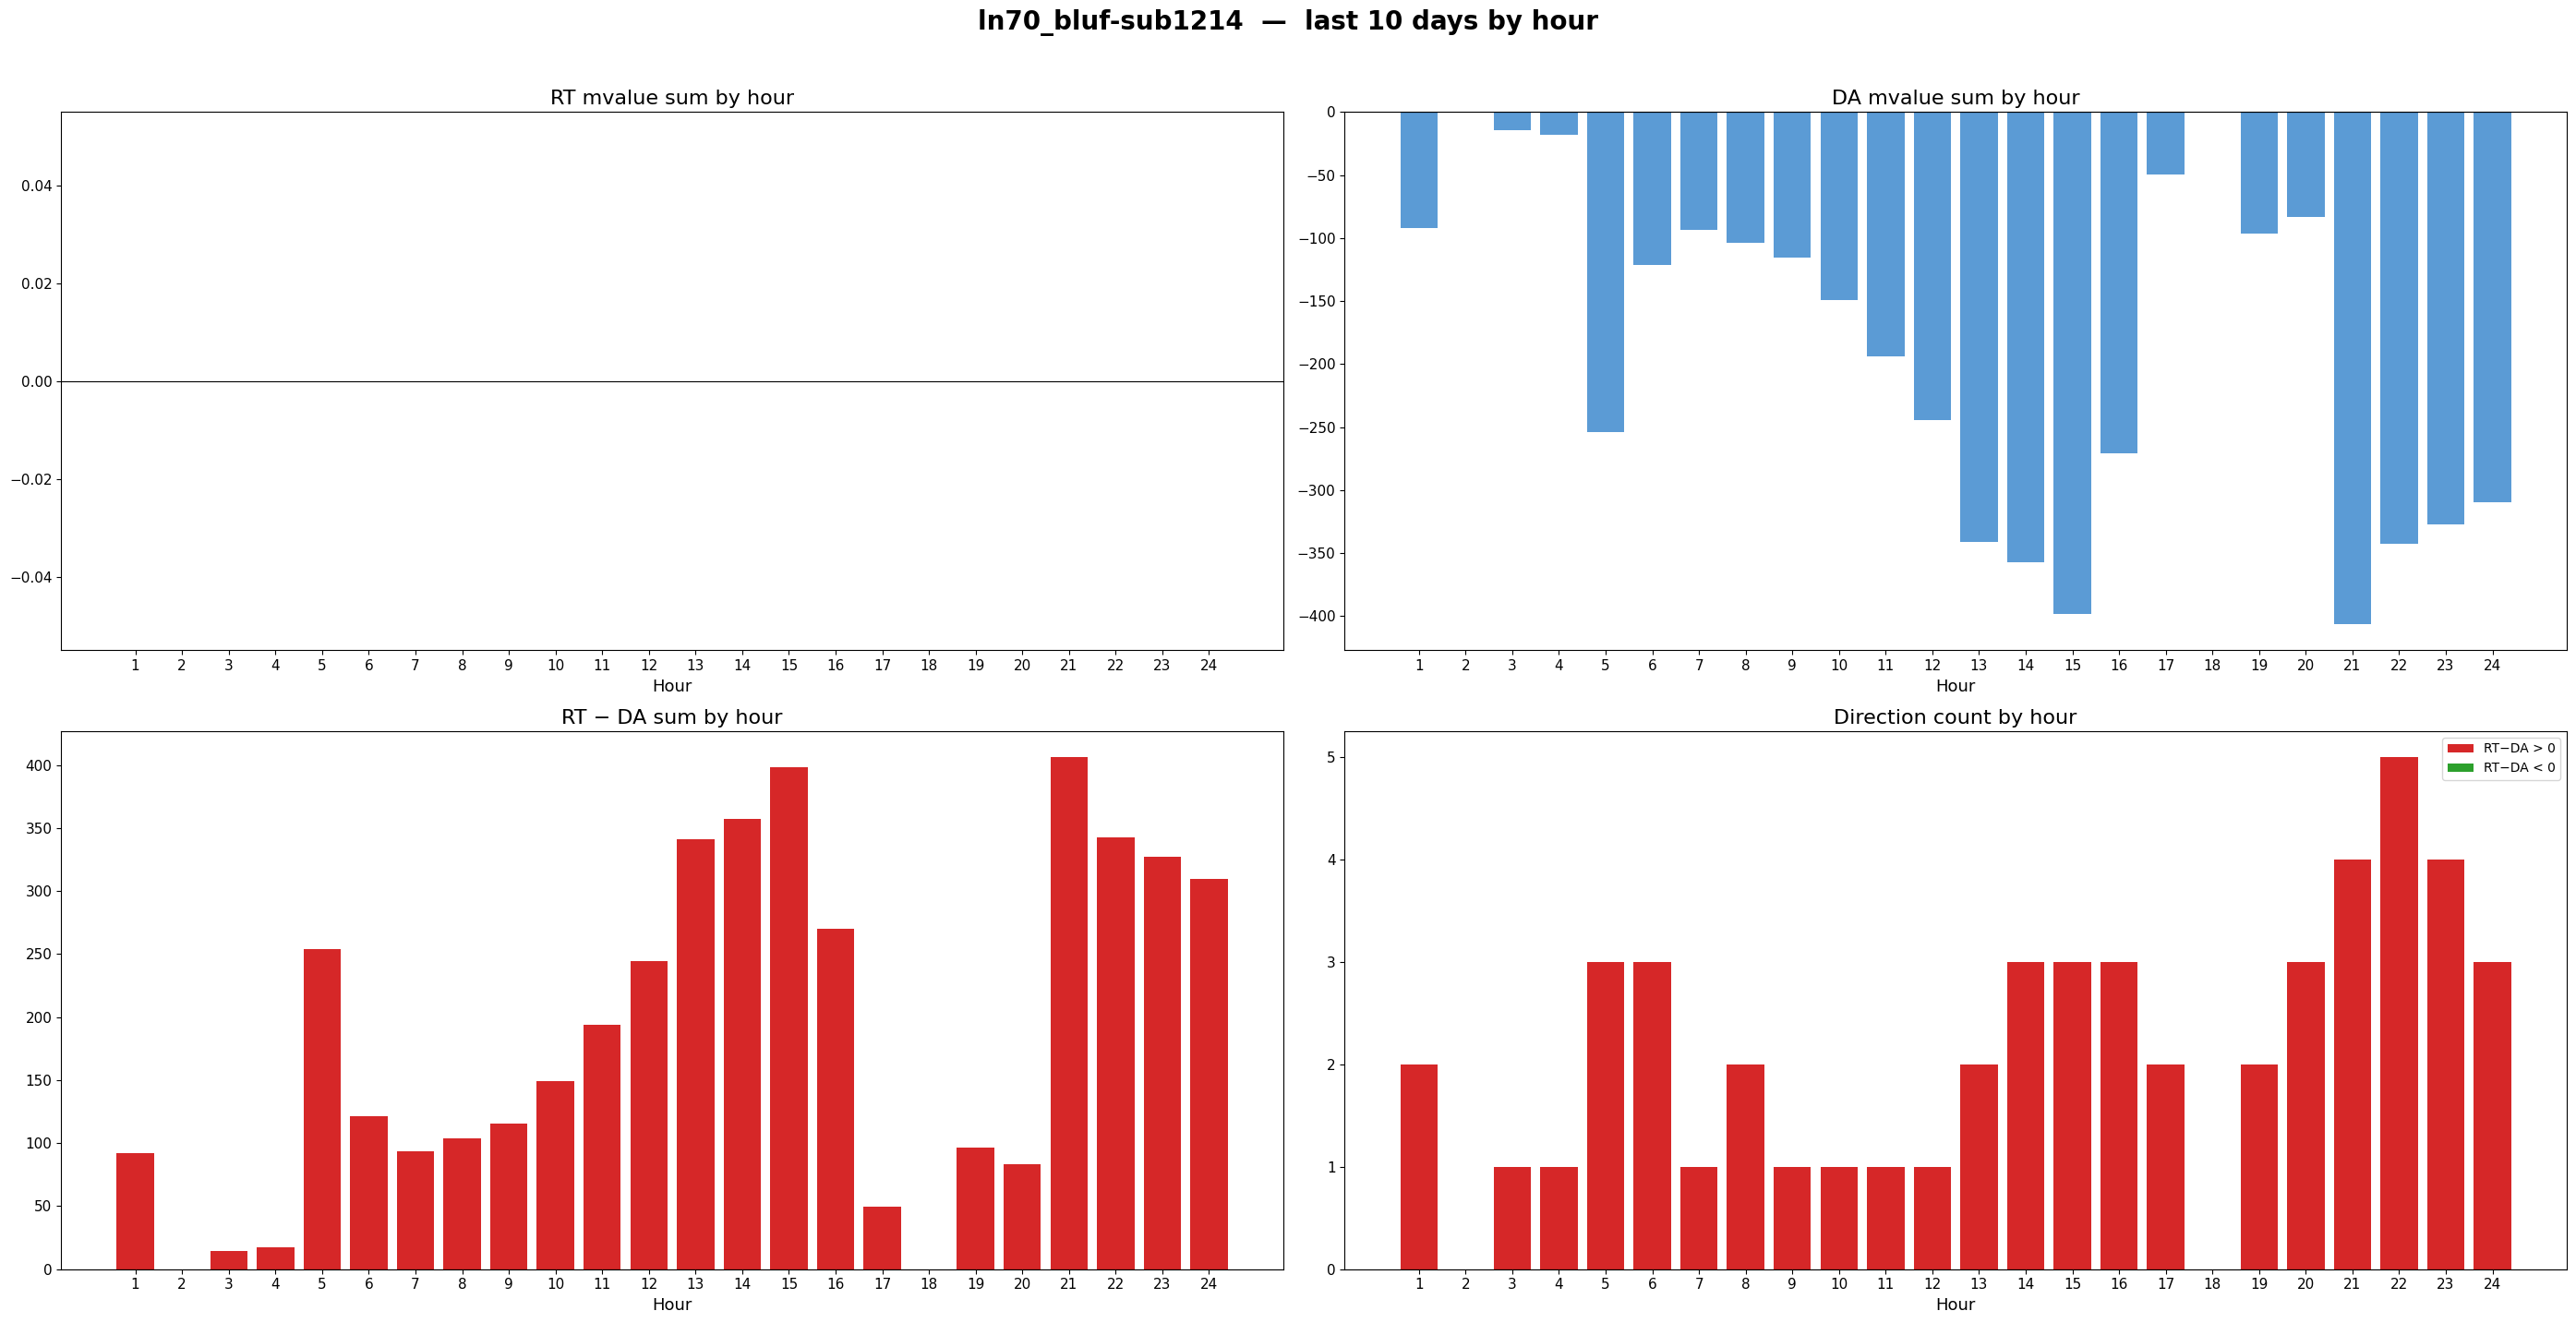


Total rows: 29880

  ln70_bluf-sub1214


,node_num,dfax,corr,sign_acc,mean_pred,mean_actual,n
0,1491,0.1455,0.182439,0.818402,-16.573478,-13.830206,1239.0
1,1548,0.0746,0.156074,0.773204,-8.497467,-7.616755,1239.0
2,1549,0.0746,0.156074,0.773204,-8.497467,-7.616755,1239.0
3,338,-0.1934,0.155597,0.639225,22.029627,7.843138,1239.0
4,333,-0.1934,0.155518,0.640839,22.029627,7.850694,1239.0
5,339,-0.1934,0.155517,0.640839,22.029627,7.850737,1239.0
6,1443,0.0697,0.149848,0.765940,-7.939323,-7.201077,1239.0
7,1116,0.0667,0.145814,0.763519,-7.597601,-6.941576,1239.0
8,1466,0.0667,0.126459,0.758676,-7.597601,-6.228342,1239.0
9,1556,-0.1646,0.120689,0.649225,19.590349,7.197307,516.0


In [19]:
from IPython.display import display, HTML

row_counts = hourly_mvalue.groupby('monitored').size().sort_values()
print(row_counts.to_string())

for name in row_counts.index:
    display(HTML(f'''
    <hr style="border: 3px solid black; margin: 30px 0;">
    <h1 style="background:#2c3e50; color:white; padding:12px 20px; border-radius:6px; font-family:monospace;">
        {name} &nbsp;<span style="font-size:0.6em; color:#aaa;">({row_counts[name]:,} rows)</span>
    </h1>
    <hr style="border: 1px solid #aaa; margin-bottom: 20px;">
    '''))

    analyze_constraint_by_zone(fundamentals, hourly_mvalue, name, 4, 95)
    plot_constraint_seasonality(hourly_mvalue, name)
    plot_recent_hourly_distribution(hourly_mvalue, name, bid_dt, days=10)
    table = get_constraints_node_price(hourly_mvalue, dfax, [name])
    get_metrics_for_nodes(table)

Constraint  : 'lnraun-tekamho'
Reserve zone: 1  |  Columns: ['rz1_spp_res_zonal_wind_forecast_f', 'rz1_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0728  |  Total hours: 17496


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top90pct,lift_pct
0,lnraun-tekamho,1,rz1_spp_res_zonal_wind_forecast_f,0.0728,0.1648,1.26
1,lnraun-tekamho,1,rz1_spp_res_zonal_load_forecast_f,0.0728,0.0635,-0.13


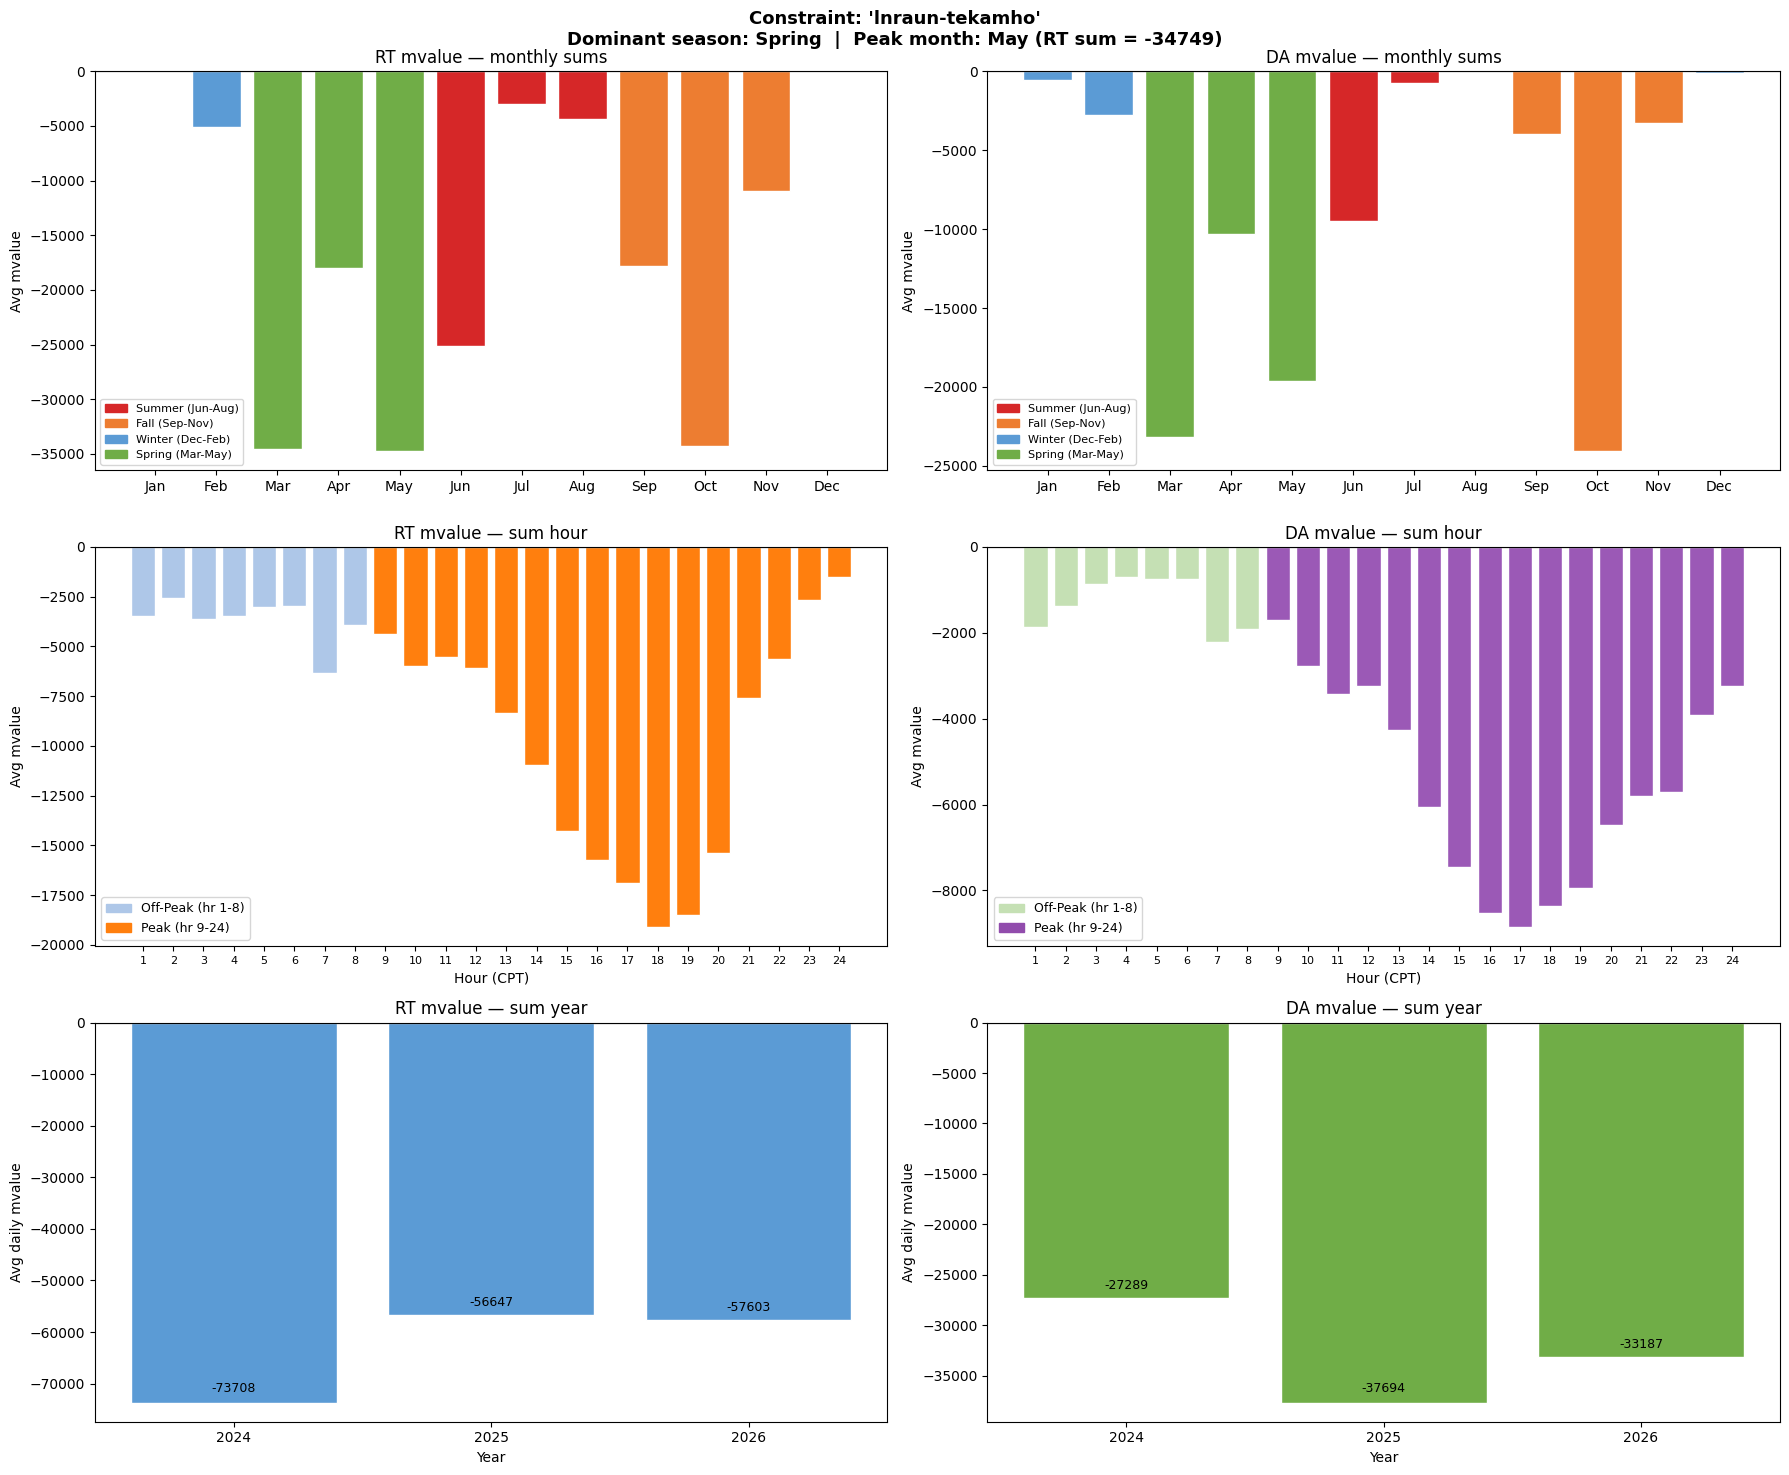

Dominant season : Spring

RT  peak sum   (hr  9-24): -158577.39  |  off-peak (hr 1-8):  -29381.07
DA  peak sum   (hr  9-24):  -87748.21  |  off-peak (hr 1-8):  -10422.52

Total rows: 34293

  lnraun-tekamho


,node_num,dfax,corr,sign_acc,mean_pred,mean_actual,n
0,1638,0.1949,0.605835,0.731646,10.670115,3.732316,790.0
1,1639,0.1949,0.575471,0.720253,10.670115,3.962130,790.0
2,1635,0.1371,0.512885,0.711392,7.505761,1.759484,790.0
3,184,0.0882,0.467804,0.670071,6.220956,2.946220,1273.0
4,182,0.0882,0.466822,0.669285,6.220956,2.946878,1273.0
5,183,0.0882,0.466818,0.669285,6.220956,2.945924,1273.0
6,185,0.0882,0.466761,0.670071,6.220956,2.984834,1273.0
7,181,0.0877,0.466405,0.670071,6.185690,2.935752,1273.0
8,890,-0.0823,0.451346,0.737628,-5.804815,-6.139073,1273.0
9,936,-0.0823,0.451346,0.737628,-5.804815,-6.139073,1273.0


In [34]:
name = 'lnraun-tekamho'
zone= 1
analyze_constraint_by_zone(fundamentals, hourly_mvalue, name, zone, 90)
plot_constraint_seasonality(hourly_mvalue, name)
table = get_constraints_node_price(hourly_mvalue, dfax, [name])
get_metrics_for_nodes(table)

In [ ]:
tomorrow_pct = predict_tomorrow_percentile(fundamentals, bid_dt)


--- Zone 1 ---


,hr,wind_value,wind_pct,load_value,load_pct
0,1,768.1,32.7,4050.9,42.8
1,2,782.9,33.4,3948.0,36.6
2,3,810.7,34.5,3875.8,31.7
3,4,847.9,36.0,3880.2,32.0
4,5,921.6,39.0,4006.2,40.2
5,6,1030.8,43.4,4073.6,44.2
6,7,1099.9,46.0,4220.7,53.6
7,8,1139.0,47.5,4427.8,64.5
8,9,1224.5,50.6,4508.4,67.7
9,10,1272.0,52.3,4603.6,71.4



--- Zone 2 ---


,hr,wind_value,wind_pct,load_value,load_pct
0,1,1307.9,19.9,666.3,29.8
1,2,1294.6,19.6,656.7,25.6
2,3,1191.2,17.9,652.3,23.4
3,4,1062.7,15.3,639.8,17.1
4,5,974.2,13.5,639.1,16.9
5,6,870.4,11.5,664.3,28.9
6,7,759.6,9.3,704.1,50.3
7,8,746.0,9.0,733.0,66.9
8,9,782.9,9.7,749.9,73.6
9,10,895.0,12.0,757.1,75.4



--- Zone 3 ---


...

,hr,wind_value,wind_pct,load_value,load_pct
0,1,4085.9,27.8,17912.0,27.5
1,2,3874.7,26.2,17258.0,19.9
2,3,3648.3,24.2,16794.8,15.5
3,4,3409.2,22.0,16639.3,14.1
4,5,3169.0,20.0,16740.2,14.9
5,6,2929.2,17.8,17353.3,20.8
6,7,2712.9,16.1,18098.4,30.1
7,8,2394.5,13.3,18914.8,42.4
8,9,2028.6,10.3,19682.0,52.6
9,10,1925.2,9.4,20480.2,60.6



--- Zone 5 ---


,hr,wind_value,wind_pct,load_value,load_pct
0,1,2574.9,78.3,3672.3,17.6
1,2,2471.7,75.2,3605.7,13.6
2,3,2434.1,74.0,3560.3,10.9
3,4,2371.0,72.1,3498.3,7.6
4,5,2279.8,69.0,3554.6,10.5
5,6,2274.0,68.9,3593.1,12.9
6,7,2320.2,70.3,3706.6,20.0
7,8,2359.5,71.7,3880.1,35.3
8,9,2400.9,73.1,3930.3,41.2
9,10,2533.2,77.1,4024.2,51.6



--- Zone 21 ---


,hr,wind_value,wind_pct,load_value,load_pct
0,1,673.6,73.9,2743.5,45.5
1,2,618.4,68.4,2599.8,25.4
2,3,563.4,61.4,2507.6,12.1
3,4,502.6,51.8,2457.0,5.8
4,5,450.6,44.6,2423.5,3.2
5,6,426.2,41.5,2438.9,3.9
6,7,420.3,40.5,2500.9,11.1
7,8,414.6,39.7,2593.5,24.3
8,9,409.9,39.0,2676.5,35.2
9,10,338.0,29.0,2763.3,49.4


In [ ]:
def predict_tomorrow_binding(fundamentals, mv_merged, monitored_name, zone, bid_dt):
    tmr = fundamentals[fundamentals['dt'] == bid_dt].copy()
    if tmr.empty:
        print(f"No forecast data for {bid_dt} in fundamentals — check bid_dt")
        return pd.DataFrame()

    grp = mv_merged[mv_merged['monitored'] == monitored_name]
    if grp.empty:
        print(f"No data for monitored='{monitored_name}'")
        return pd.DataFrame()

    binding_hours = grp[grp['rt_da'] != 0][['dt', 'hr']].drop_duplicates().copy()
    binding_hours['binding'] = 1

    all_dates = pd.date_range(start=mv_merged['dt'].min(), end=mv_merged['dt'].max(), freq='D')
    full_grid = pd.DataFrame([
        {'dt': d.strftime('%Y-%m-%d'), 'hr': h}
        for d in all_dates for h in range(1, 25)
    ])
    tmp = (full_grid
           .merge(fundamentals, on=['dt', 'hr'], how='left')
           .merge(binding_hours, on=['dt', 'hr'], how='left'))
    tmp['binding'] = tmp['binding'].fillna(0)
    baseline = tmp['binding'].mean()

    rz_cols = [c for c in tmp.columns if c.startswith(f'rz{zone}_') and 'forecast' in c]

    rows = []
    for col in rz_cols:
        hist = tmp[col].dropna()
        if len(hist) < 20:
            continue
        for _, row in tmr.iterrows():
            tmr_val = row.get(col)
            if pd.isna(tmr_val):
                continue
            pct = (hist < tmr_val).mean() * 100
            threshold = hist.quantile(pct / 100)
            above = tmp[tmp[col] > threshold]
            cond_prob = above['binding'].mean() if len(above) >= 5 else None
            rows.append({
                'hr': int(row['hr']),
                'fundamental': col.replace(f'rz{zone}_spp_res_zonal_', '').replace('_forecast_f', ''),
                'tmr_value': round(tmr_val, 1),
                'tmr_pct': round(pct, 1),
                'baseline_prob': round(baseline, 4),
                'cond_prob': round(cond_prob, 4) if cond_prob is not None else None,
                'lift': round(cond_prob / baseline - 1, 2) if cond_prob and baseline > 0 else None
            })

    result = pd.DataFrame(rows).sort_values(['hr', 'fundamental']).reset_index(drop=True)
    display(result)
    return result

# Example:
predict_tomorrow_binding(fundamentals, hourly_mvalue, 'lnwardwa-bismark2', 5, bid_dt)
